C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4756\2479190282.py:19: RuntimeWarning: invalid value encountered in sqrt
  EC50 = (1 / (m2 * m1 - 2 * n)) * np.sqrt((2 * n * m2 - kb * ((m2 * m1 - 2 * n) * (m1 * m1 - 2 * n))) / kc)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4756\2479190282.py:108: RuntimeWarning: invalid value encountered in log10
  cs = ax.contour(M1, M2, np.log10(sensitivity), levels=np.logspace(-1, 3, 10), cmap='cool')


TypeError: can only concatenate str (not "set") to str

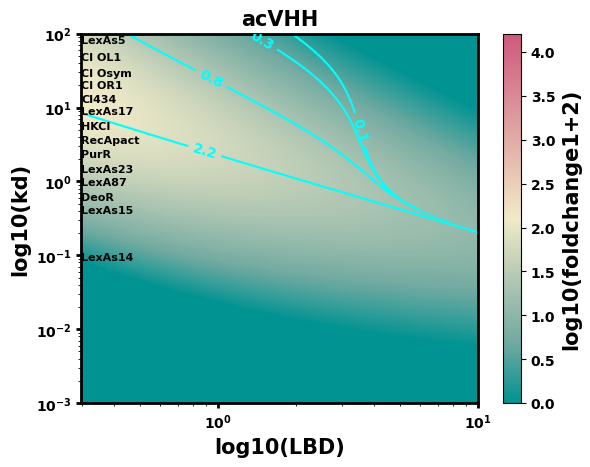

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text
import palettable

def foldchange1(m1, m2, kb, kc, Imax, I0, I):
    x1 = np.sqrt(1 + 8 * m1 * (kb + I * kc))
    x2 = np.sqrt(1 + 8 * m1 * kb)
    F1 = np.log(m1 / 2) + np.log((x1 - 1) / (x1 + 1)) + np.log(m2)
    F2 = np.log(m1 / 2) + np.log((x2 - 1) / (x2 + 1)) + np.log(m2)
    P1 = (Imax / (1 + np.exp(-F1))) + I0
    P2 = (Imax / (1 + np.exp(-F2))) + I0
    f1 = P1 / P2
    f2 = P1 - P2
    return np.log10(f1)+np.log10(f2)

def EC50(m1, m2, kb, kc, Imax, I0):
    n = (Imax + I0) / (Imax - I0)
    EC50 = (1 / (m2 * m1 - 2 * n)) * np.sqrt((2 * n * m2 - kb * ((m2 * m1 - 2 * n) * (m1 * m1 - 2 * n))) / kc)
    sensitivity = 1 / EC50
    return EC50

m1 = np.linspace(0.3, 10, 2000)
m2 = np.logspace(-3, 2, 2000)
M1, M2 = np.meshgrid(m1, m2)

kd_values = [8.86157218,	57.53244494,	7.558673946,	1.11789931,	1.39466996,	7.196235604,	4.263511229,	0.613878816,	1.668428973,40.91843104	,14.13834087,	14.34237987,0.469123259,	0.080209785]
kd_labels = ['CI434', 'LexAs5', 'LexAs17', 'LexA87', 'LexAs23', 'HKCI', 'RecApact', 'DeoR', 'PurR', 'CI OL1',	'CI OR1',	 'CI Osym', 'LexAs15', 'LexAs14']

# Define different LBD parameters and names
LBD_parameters = [
    {'LBD_name': 'acVHH', 'kb': 0.054222922, 'kc':0.00318833, 'Imax': 35.84931505, 'I0': 0.035485714, 'I': 1000},
    {'LBD_name': 'LasR', 'kb': 9.9547E-05, 'kc': 0.000455663, 'Imax': 35.84931505, 'I0': 0.035485714, 'I': 10000},
    {'LBD_name': 'RpaR', 'kb': 0.000104828, 'kc': 0.000784922, 'Imax': 35.84931505, 'I0': 0.035485714, 'I': 100},
    {'LBD_name': 'CinRori', 'kb': 0.006631834, 'kc': 0.002297228, 'Imax': 35.84931505, 'I0': 0.035485714, 'I': 1000},
    {'LBD_name': 'BjaR', 'kb': 5.8735E-05, 'kc': 2.40005E-05, 'Imax': 35.84931505, 'I0': 0.035485714, 'I': 100},
    {'LBD_name': 'SmaR', 'kb': 0.070720359, 'kc': 0.116443624, 'Imax': 35.84931505, 'I0': 0.035485714, 'I': 100},
    {'LBD_name': 'TraR', 'kb': 4.72901E-05, 'kc': 0.001187536,'Imax': 35.84931505, 'I0': 0.035485714, 'I': 100},
    {'LBD_name': 'CarR', 'kb': 0.03051907, 'kc': 0.00139588, 'Imax': 35.84931505, 'I0': 0.065227742, 'I': 10000},

]

# Calculate the foldchange range for all LBDs
foldchange_ranges = []
for params in LBD_parameters:
    kb = params['kb']
    kc = params['kc']
    Imax = params['Imax']
    I0 = params['I0']
    I = params['I']
    foldchange = foldchange1(M1, M2, kb, kc, Imax, I0, I)
    foldchange_ranges.append((foldchange.min(), foldchange.max()))

# Determine the global foldchange range
global_min = min([r[0] for r in foldchange_ranges])
global_max = max([r[1] for r in foldchange_ranges])

max_foldchange = []
max_m1 = []

for params in LBD_parameters:
    kb = params['kb']
    kc = params['kc']
    Imax = params['Imax']
    I0 = params['I0']
    I = params['I']

    foldchange =foldchange1(M1, M2, kb, kc, Imax, I0, I)
    max_index = np.unravel_index(np.argmax(foldchange), foldchange.shape)
    max_foldchange.append(foldchange[max_index])
    max_m1.append(M1[max_index])

for params in LBD_parameters:
    kb = params['kb']
    kc = params['kc']
    Imax = params['Imax']
    I0 = params['I0']
    I = params['I']
    LBD_name = params['LBD_name']

    fig, ax = plt.subplots()
    cmap = palettable.cartocolors.diverging.TealRose_7.mpl_colormap

    # Generate the heatmap with the global foldchange range
    cp = ax.pcolormesh(M1, M2, foldchange1(M1, M2, kb, kc, Imax, I0, I), cmap=cmap, vmin=0, vmax=global_max)

    # Add colorbar
    cbar = fig.colorbar(cp)
    cbar.ax.set_ylabel('log10(foldchange1+2)',fontsize=15,weight='bold')

    # Set axis labels and scales
    ax.set_title(LBD_name,fontsize=15,weight='bold')
    ax.set_xlabel('log10(LBD)',fontsize=15,weight='bold')
    ax.set_ylabel('log10(kd)',fontsize=15,weight='bold')
    ax.set_xscale('log')
    ax.set_yscale('log')

    # Set other plot elements and adjust text
    texts = []
    for i, (x, y) in enumerate(zip(kd_values, kd_labels)):
        text = ax.text(0.001, x, y, fontsize=8)
        texts.append(text)
    adjust_text(texts, autoalign='y', only_move={'points':'y', 'text':'y'})

    # Calculate sensitivity and add contour lines
    
    sensitivity = EC50(M1, M2, kb, kc, Imax, I0)
    cs = ax.contour(M1, M2, np.log10(sensitivity), levels=np.logspace(-1, 3, 10), cmap='cool')
    plt.clabel(cs, inline=True, fontsize=10)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    ax.spines['top'].set_linewidth(2)
    ax.spines['right'].set_linewidth(2)
    plt.tick_params(axis='both', width=2,labelsize=10)
    plt.rcParams['font.weight'] = 'bold'
    plt.rcParams['axes.labelweight'] = 'bold'

    # Set the title and save the plot
    #plt.savefig('E:\Desktop'+{LBD_name}+'.svg',dpi=400)

    # Show the plot (optional)
    plt.show()

C:\Users\Chestnut\AppData\Local\Temp\ipykernel_3156\1768986287.py:41: RuntimeWarning: divide by zero encountered in log
  F1 = np.log(L / 2) + np.log((x1 - 1) / (x1 + 1)) + np.log(kd)
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_3156\1768986287.py:42: RuntimeWarning: divide by zero encountered in log
  F2 = np.log(L / 2) + np.log((x2 - 1) / (x2 + 1)) + np.log(kd)
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_3156\1768986287.py:47: RuntimeWarning: invalid value encountered in true_divide
  foldchange1=((x2-1)*(x1+1))/((x2+1)*(x1-1))


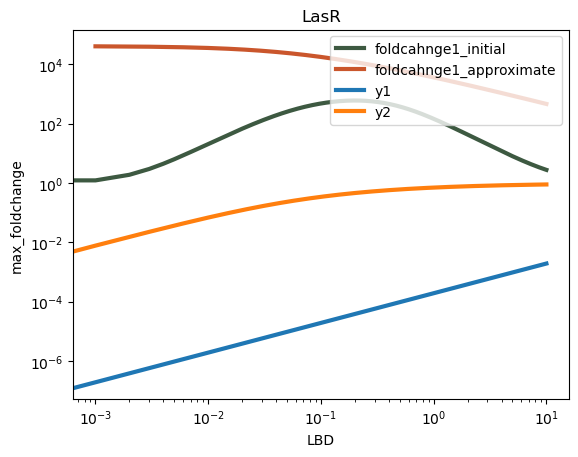

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.interpolate import interp1d
import palettable

# 设置x和y的坐标范围
L = np.arange(0, 10, 0.001)

kb =9.78857E-05

kc = 0.000396662

kd = 57.53244494

I=10000




x1 = np.sqrt(1 + 8 * L * (kb)) 

x2 = np.sqrt(1 + 8 * L * (I*kc)) 

y1=(x1-1)/(x1+1)
y2=(x2-1)/(x2+1)


Imax = 35.84931505

I0 = 0.035485714

F1 = np.log(L / 2) + np.log((x1 - 1) / (x1 + 1)) + np.log(kd)
F2 = np.log(L / 2) + np.log((x2 - 1) / (x2 + 1)) + np.log(kd)


P1 = (Imax / (1 + np.exp(-F1))) + I0
P2 = (Imax / (1 + np.exp(-F2))) + I0
foldchange1=((x2-1)*(x1+1))/((x2+1)*(x1-1))

# 选择颜色方案
colors = palettable.cartocolors.diverging.Fall_3.mpl_colors
plt.plot(L, P2/P1, color=colors[0], linewidth=3.0,label='foldcahnge1_initial')
#plt.plot(L, foldchange1, linewidth=3.0,label='foldcahnge1_approximate')
plt.plot(L, foldchange1, color=colors[2], linewidth=3.0,label='foldcahnge1_approximate')
plt.plot(L, y1, linewidth=3.0,label='y1')
plt.plot(L, y2, linewidth=3.0,label='y2')
plt.legend(loc='upper right')


plt.title('LasR')
plt.xlabel("LBD")
plt.ylabel("max_foldchange")
plt.xscale("log")
plt.yscale("log")

#plt.savefig('/T18/lizengli/MyProject/LBD_DBD/fig2/araR.png',dpi=400)
plt.show()


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

kb =9.78857E-05
kc = 0.000396662
I=10000
Imax = 35.84931505

I0 = 0.035485714


x1 = np.sqrt(1 + 8 * L * (kb)) 

x2 = np.sqrt(1 + 8 * L * (I*kc)) 


# 定义函数
def calculate_F(L, x, kd):
    return np.log(L / 2) + np.log((x - 1) / (x + 1)) + np.log(kd)

def calculate_P(F):
    return (Imax / (1 + np.exp(-F))) + I0

# 创建L和kd的值
L_values = np.linspace(0, 10, 1000)
kd_values = np.linspace(0, 100, 10000)

# 创建一个空的结果矩阵
results = np.zeros((len(L_values), len(kd_values)))

# 遍历每个L和kd的值
for i, L in enumerate(L_values):
    for j, kd in enumerate(kd_values):
        F1 = calculate_F(L, x1, kd)
        F2 = calculate_F(L, x2, kd)
        P1 = calculate_P(F1)
        P2 = calculate_P(F2)
        results[i, j] = P2 / P1

# 创建一个新的图形
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 绘制三维图
X, Y = np.meshgrid(L_values, kd_values)
ax.plot_surface(X, Y, results.T)

# 设置标签
ax.set_xlabel('L')
ax.set_ylabel('C')
ax.set_zlabel('P2/P1')

# 显示图形
plt.show()


C:\Users\Chestnut\AppData\Local\Temp\ipykernel_3156\686901257.py:20: RuntimeWarning: divide by zero encountered in log
  return np.log(L / 2) + np.log((x - 1) / (x + 1)) + np.log(kd)


ValueError: setting an array element with a sequence.

C:\Users\Chestnut\AppData\Local\Temp\ipykernel_3156\2672848065.py:32: RuntimeWarning: divide by zero encountered in log
  F1 = np.log(L / 2) + np.log((m1 - 1) / (m1 + 1)) + np.log(kd)
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_3156\2672848065.py:33: RuntimeWarning: divide by zero encountered in log
  F2 = np.log(L / 2) + np.log((m2 - 1) / (m2 + 1)) + np.log(kd)
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_3156\2672848065.py:38: RuntimeWarning: divide by zero encountered in double_scalars
  foldchange1=((x2-1)*(x1+1))/((x2+1)*(x1-1))
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_3156\2672848065.py:38: RuntimeWarning: invalid value encountered in double_scalars
  foldchange1=((x2-1)*(x1+1))/((x2+1)*(x1-1))


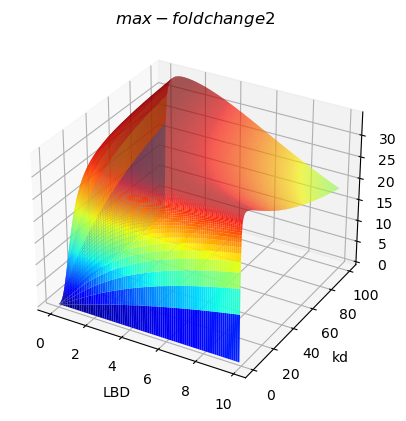

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import math
from mpl_toolkits.mplot3d import Axes3D
import warnings

def promoter(x1,x2):

    L=x1
    I=10000
    kd=x2
    C=L*kd/2
    #I=0.035
    #A=0.1
    kb =9.78857E-05

    kc = 0.000396662
    m1 = np.sqrt(1 + 8 * L * (kb)) 

    m2 = np.sqrt(1 + 8 * L * (I*kc)) 

    y1=(m1-1)/(m1+1)
    y2=(m2-1)/(m2+1)


    Imax = 35.84931505

    I0 = 0.035485714


    F1 = np.log(L / 2) + np.log((m1 - 1) / (m1 + 1)) + np.log(kd)
    F2 = np.log(L / 2) + np.log((m2 - 1) / (m2 + 1)) + np.log(kd)


    P1 = (Imax / (1 + np.exp(-F1))) + I0
    P2 = (Imax / (1 + np.exp(-F2))) + I0
    foldchange1=((x2-1)*(x1+1))/((x2+1)*(x1-1))
    
    
    return P2-P1

X1 = np.arange(0,10,0.1)
X2 = np.arange(0,100,0.1)
X1, X2 = np.meshgrid(X1, X2) # 生成xv、yv，将X1、X2变成n*m的矩阵，方便后面绘图
#C=X1*X2/2
Y = np.array(list(map(lambda t : promoter(t[0],t[1]),zip(X1.flatten(),X2.flatten()))))
Y.shape = X1.shape # 1600的Y图还原成原来的（40,40）
 
%matplotlib inline
#作图
fig = plt.figure(facecolor='w')
ax = fig.add_subplot(projection='3d')
ax.plot_surface(X1,X2,Y,rstride=1,cstride=1,cmap=plt.cm.jet)
ax.set_title(u'$ max-foldchange2$')
ax.set_xlabel('LBD')
ax.set_ylabel('kd')
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 读取CSV文件
df = pd.read_csv('E:\Desktop\quantification&crossvalidation\\326.csv')

# 按照ID排序数据
#sorted_data = data.sort_values('ID')
L = df['LBD'].dropna()
P1 = np.log10(df['RPU']).dropna()
I = df['inducer'].dropna()
kb=0.007291176

kc=0.002462824


Imax=35.84931505

I0=0.035485714


kd=57.53244494


def func(L,I0,Imax, kb, kc,kd):
    if not (0 < kb < 10) or not (0 < kc < 10):
        return np.ones_like(L) * 1e10
    x1 = np.sqrt(1 + 8 * L * (kb + I * kc))
    x2 = np.sqrt(1 + 8 * L * (kb ))
    P1=np.log10(Imax * ((L / 2) * ((x1 - 1) / (x1 + 1)) * kd / (1 + (L / 2) * ((x1 - 1) / (x1 + 1)) * kd)) + I0)
    P2=np.log10(Imax * ((L / 2) * ((x1 - 1) / (x1 + 1)) * kd / (1 + (L / 2) * ((x2 - 1) / (x2 + 1)) * kd)) + I0)
    return P1/P2

# 提取预测值和实际值
prediction = func(L,I0,Imax ,kb, kc,kd)
actual_values = P1
regressor = LinearRegression()
regressor.fit(prediction.values.reshape(-1, 1), actual_values)



# 绘制散点图和相关性直线
plt.scatter(prediction, actual_values)
plt.plot(prediction, regressor.predict(prediction.values.reshape(-1, 1)),c='g')

plt.xlabel('Ikc/kb')
plt.ylabel('fold')
plt.title('all_DBD')

corr = np.corrcoef(prediction, actual_values)[0, 1]

plt.text(plt.xlim()[0] + 0.1, plt.ylim()[1] -0.2, f'Correlation (nn1): {corr:.4f}')

plt.show()

In [31]:
import numpy as np
import csv

def foldchange1(L, kd, kb, kc, Imax, I0, I):
    x1 = np.sqrt(1 + 8 * L * ( I * kc))
    x2 = np.sqrt(1 + 8 * L * kb)
    F1 = np.log(L / 2) + np.log((x1 - 1) / (x1 + 1)) + np.log(kd)
    F2 = np.log(L / 2) + np.log((x2 - 1) / (x2 + 1)) + np.log(kd)
    P1 = (Imax / (1 + np.exp(-F1))) + I0
    P2 = (Imax / (1 + np.exp(-F2))) + I0
    f1 = P1 / P2
    f2 = P1 - P2
    return f2

def foldchange2(L, kd, kb, kc, Imax, I0, I):
    x1 = np.sqrt(1 + 8 * L * (kb + I * kc))
    x2 = np.sqrt(1 + 8 * L * kb)
    F1 = np.log(L / 2) + np.log((x1 - 1) / (x1 + 1)) + np.log(kd)
    F2 = np.log(L / 2) + np.log((x2 - 1) / (x2 + 1)) + np.log(kd)
    P1 = (Imax / (1 + np.exp(-F1))) + I0
    P2 = (Imax / (1 + np.exp(-F2))) + I0
    f1 = P1 / P2
    f2 = P1 - P2
    return f2

L = np.linspace(0.3, 10, 2000)

kd_values = [8.86157218,	57.53244494,	7.558673946,	1.11789931,	1.39466996,	7.196235604,	4.263511229,	0.613878816,	1.668428973,40.91843104	,14.13834087,	14.34237987,0.469123259,	0.080209785]
kd_labels = ['CI434', 'LexAs5', 'LexAs17', 'LexA87', 'LexAs23', 'HKCI', 'RecApact', 'DeoR', 'PurR', 'CI OL1',	'CI OR1',	 'CI Osym', 'LexAs15', 'LexAs14']

# Define different LBD parameters and names
LBD_parameters = [
    {'LBD_name': 'acVHH', 'kb': 0.00873468, 'kc':0.002462824, 'Imax': 35.84931505, 'I0': 0.035485714, 'I': 1000},
    {'LBD_name': 'LasR', 'kb': 9.61E-05, 'kc': 0.000396662, 'Imax': 35.84931505, 'I0': 0.035485714, 'I': 10000},
    {'LBD_name': 'RpaR', 'kb':0.000226169, 'kc': 0.000757068, 'Imax': 35.84931505, 'I0': 0.035485714, 'I': 1000},
    {'LBD_name': 'CinRori', 'kb':0.003616558, 'kc': 0.000917781, 'Imax': 35.84931505, 'I0': 0.035485714, 'I': 1000},
    {'LBD_name': 'BjaR', 'kb': 8.2578E-05, 'kc': 1.2121E-05, 'Imax': 35.84931505, 'I0': 0.035485714, 'I': 1000},
    {'LBD_name': 'TraR', 'kb': 4.72938E-05, 'kc': 0.00118681, 'Imax': 35.84931505, 'I0': 0.035485714, 'I': 100},

]
max_foldchange_values = np.zeros((len(LBD_parameters), len(kd_values)))
max_L_values = np.zeros((len(LBD_parameters), len(kd_values)))

for i, params in enumerate(LBD_parameters):
    for j, kd in enumerate(kd_values):
        foldchange = (foldchange1(L, kd, params['kb'], params['kc'], params['Imax'], params['I0'], params['I']))
        RPU=(foldchange2(L, kd, params['kb'], params['kc'], params['Imax'], params['I0'], params['I']))
        max_foldchange_index = np.argmax(foldchange)
        max_foldchange = foldchange[max_foldchange_index]
        max_L = L[max_foldchange_index]
        max_RPU= RPU[max_foldchange_index]
        max_foldchange_values[i][j] = max_foldchange
        max_L_values[i][j] = max_L
        #max_RPU[i][j] = max_RPU

# 将结果输出到CSV文件
filename_foldchange = 'E:\Desktop\\foldchange_max_values.csv'
filename_max_L = 'E:\Desktop\\max_L_values.csv'
#output='output.csv'

with open(filename_foldchange, 'w', newline='') as file:
    writer = csv.writer(file)
    header = ['LBD_name'] + kd_labels
    writer.writerow(header)
    for i, params in enumerate(LBD_parameters):
        row = [params['LBD_name']] + (max_foldchange_values[i]).tolist()
        writer.writerow(row)

with open(filename_max_L, 'w', newline='') as file:
    writer = csv.writer(file)
    header = ['LBD_name'] + kd_labels
    writer.writerow(header)
    for i, params in enumerate(LBD_parameters):
        row = [params['LBD_name']] + max_L_values[i].tolist()
        writer.writerow(row)
'''
with open(output, 'w', newline='') as file:
    writer = csv.writer(file)
    header = ['LBD_name'] + kd_labels
    writer.writerow(header)
    for i, params in enumerate(LBD_parameters):
        row = [params['LBD_name']] + max_RPU[i].tolist()
        writer.writerow(row)
'''


"\nwith open(output, 'w', newline='') as file:\n    writer = csv.writer(file)\n    header = ['LBD_name'] + kd_labels\n    writer.writerow(header)\n    for i, params in enumerate(LBD_parameters):\n        row = [params['LBD_name']] + max_RPU[i].tolist()\n        writer.writerow(row)\n"

C:\Users\Chestnut\AppData\Local\Temp\ipykernel_1424\1890991056.py:60: RuntimeWarning: divide by zero encountered in log
  F1=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd1) #CI434
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_1424\1890991056.py:62: RuntimeWarning: divide by zero encountered in log
  F2=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd2) #LexAs5
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_1424\1890991056.py:64: RuntimeWarning: divide by zero encountered in log
  F3=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd3) #LexAs17
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_1424\1890991056.py:66: RuntimeWarning: divide by zero encountered in log
  F4=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd4) #LexA87
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_1424\1890991056.py:68: RuntimeWarning: divide by zero encountered in log
  F5=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1)

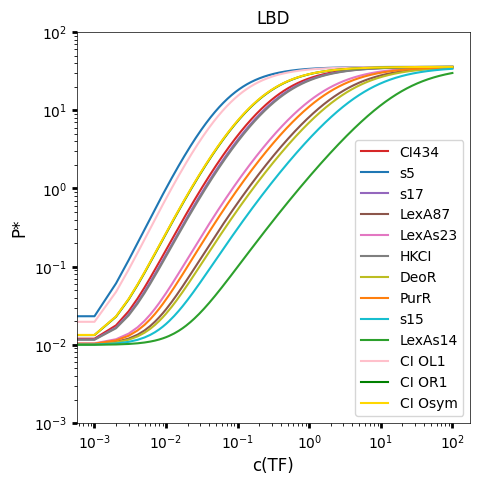

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import optimize
import scipy.constants as c
import pandas as pd
from scipy.interpolate import interp1d

# 设置x和y的坐标范围
#I= np.arange(0,1000,0.01)
#kd= np.arange(10,100000,1)
#I= np.arange(0,10,0.01)
#I1=1000
#I2=100
#I=0.000000001
L= np.arange(0,100,0.001)
I=1
kd1=6.216347694

kd2=40.97704697

kd3=5.374494076

kd4=0.745553315

kd5=1.445352554

kd6=5.066512585

kd7=2.956590891

kd8=0.607055765

kd9=1.13083303

kd10=0.343528478

kd11=0.102414004

kd12=30.08697891

kd13=10.36936283

kd14=10.53282547


k1=0.000171923

k2=0.256016091

k3=225.0817618

Imax = 35.84931505


x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
x2 = np.sqrt(1 + 8 * L * k1)
x3 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I ))

F1=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd1) #CI434

F2=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd2) #LexAs5
 
F3=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd3) #LexAs17

F4=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd4) #LexA87

F5=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd5) #LexAs23

F6=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd6) #HKCI

F7=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd7) #RecApact

F8=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd8) #DeoR

F9=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd9) #PurR

F10=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd10) #LexAs15

F11=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd11) #LexAs14

F12=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd12) #CI OL1

F13=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd13) #CI OR1

F14=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd14) # CI Osym



P1 = (Imax / (1 + np.exp(-F1))) +0.01

P2 = (Imax / (1 + np.exp(-F2))) +0.01


P3 = (Imax / (1 + np.exp(-F3))) +0.01

P4 = (Imax / (1 + np.exp(-F4))) +0.01


P5 = (Imax / (1 + np.exp(-F5))) +0.01

P6 = (Imax / (1 + np.exp(-F6)))  +0.01

P7 = (Imax / (1 + np.exp(-F7)))  +0.01

P8 = (Imax / (1 + np.exp(-F8))) +0.01

P9 = (Imax / (1 + np.exp(-F9))) +0.01


P10 = (Imax / (1 + np.exp(-F10)))  +0.01



P11 = (Imax / (1 + np.exp(-F11)))+0.01



P12 = (Imax / (1 + np.exp(-F12)))  +0.01


P13 = (Imax / (1 + np.exp(-F13)))  +0.01

P14 = (Imax / (1 + np.exp(-F14))) +0.01


ddg8= ((L / 2)*((x1 - (k2*I+1)) / (x1 + (k2*I+1)))*kd2+1)*((L / 2)*((x1 - (k2*I+1)) / (x1 + (k2*I+1)))*kd8+1)
ddg8_diff= (Imax *(L / 2)*((x1 - (k2*I+1)) / (x1 + (k2*I+1)))*(kd2-kd8))/ddg8
ddg9_diff= P1-P9
ddg10= np.log(kd2)-np.log(kd10)
ddg10_diff= P1-P10
ddg13=np.log(kd2)-np.log(kd12)
ddg13_diff= P1-P13
ddg11_diff= P1-P11
ddg2_diff= P1-P2
ddg3_diff= P1-P3
ddg4_diff= P1-P4
ddg5_diff= P1-P5
ddg6_diff= P1-P6
ddg7_diff= P1-P7
ddg8_diff= P1-P8
ddg12_diff= P1-P12
ddg14_diff= P1-P14
ddg1_diff= P1-P1
#y1=np.sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)*(-50*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 10*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)) - (-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))**2/8 + 1 - 1/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))) + (I - 10)*(80*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - (160*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + 2*k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))*(-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))/4)*sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (I - 10)**2*(4*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2**2/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)) - (8*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))*(-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))/4 - (160*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + 2*k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))**2/8)*np.sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)
fig, ax = plt.subplots(figsize=(5.08,5.08))
#ax.plot(I, P5,linewidth=1,label='master curve',c='black',linestyle='--')
ax.plot(L, P1,linewidth=1.5,label='CI434',c='#d62728')
ax.plot(L, P2,linewidth=1.5,label='s5',c='#1f77b4')
ax.plot(L, P3,linewidth=1.5,label='s17',c='#9467bd')
ax.plot(L, P4,linewidth=1.5,label='LexA87',c='#8c564b')
ax.plot(L, P5,linewidth=1.5,label='LexAs23',c='#e377c2')
ax.plot(L, P6,linewidth=1.5,label='HKCI',c='#7f7f7f')
#ax.plot(L, P7,linewidth=2,label='RecApact')
ax.plot(L, P8,linewidth=1.5,label='DeoR',c='#bcbd22')
ax.plot(L, P9,linewidth=1.5,label='PurR',c='#ff7f0e')
ax.plot(L, P10,linewidth=1.5,label='s15',c='#17becf')
ax.plot(L, P11,linewidth=1.5,label='LexAs14',c='#2ca02c')
ax.plot(L, P12,linewidth=1.5,label='CI OL1',c='pink')
ax.plot(L, P13,linewidth=1.5,label='CI OR1',c='green')
ax.plot(L, P14,linewidth=1.5,label='CI Osym',c='gold')

#ax.plot(I, np.log10(x3),linewidth=3,label='I2=100')
#ax.plot(I, y2,linewidth=3,label='I0=0')
#ax.plot(I, y1,linewidth=3,label='I0=10')
#ax.plot(L, y1,linewidth=3,label='y4')
#ax.plot(I, P2,label='本底',linewidth=3)
#ax.plot(I, P2,label='kb=inititial*10',linewidth=3)

#ax.plot(I, P3,label='kb=inititial*100',linewidth=3)
#plt.legend(loc='upper left')
#plt.annotate('P1= {:.4f}'.format(P1), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')

#plt.annotate('P2= {:.4f}'.format(P2), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')
#ax.plot(L, P2, label="P2")
#ax.scatter(x, y)
def func(I,L, k1, k2, k3):  
            if not 0 < k1 or not 0 < k2 or not 0 < k3:
                return np.ones_like(L) * 1e10  # 返回一个大的值
            x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
            return (Imax * ((L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd / (1 + (L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd)) + I0)
df1 = pd.read_csv("E:\Desktop\\all_data\data7\\327\\327_inducer1-100.csv")
df2 = pd.read_csv("E:\Desktop\data\\343_inducer.csv")
df3 = pd.read_csv("E:\Desktop\data\\346_inducer0-100.csv")
df4 = pd.read_csv("E:\Desktop\data\\335_inducer100-500.csv")
df5 = pd.read_csv("E:\Desktop\data\\337_inducer10-1000.csv")
df6 = pd.read_csv("E:\Desktop\data\\338_inducer.csv")
df7 = pd.read_csv("E:\Desktop\data\\339_inducer100.csv")
df8 = pd.read_csv("E:\Desktop\data\\340_inducer0-500.csv")
df9 = pd.read_csv("E:\Desktop\data\\342_inducer0-500.csv")
df10 = pd.read_csv("E:\Desktop\data\\345_inducer.csv")
df11 = pd.read_csv("E:\Desktop\data\\387_inducer.csv")
df12 = pd.read_csv("E:\Desktop\data\\388_inducer.csv")
df13 = pd.read_csv("E:\Desktop\data\\389_inducer.csv")

x1=df1['LBD'].dropna()
y1=df1['100'].dropna()
y2=df1['100'].dropna()
x2=df2['LBD'].dropna()
y3=df2['100'].dropna()
y4=df2['100'].dropna()
x3=df3['LBD'].dropna()
y5=df3['100'].dropna()
y6=df3['100'].dropna()

x4=df4['LBD'].dropna()
y7=df4['100'].dropna()
x5=df5['LBD'].dropna()
y8=df5['100'].dropna()
x6=df6['LBD'].dropna()
y9=df6['100'].dropna()
x7=df7['LBD'].dropna()
y10=df7['100'].dropna()
x8=df8['LBD'].dropna()
y11=df8['100'].dropna()
x9=df9['LBD'].dropna()
y12=df9['100'].dropna()
x10=df10['LBD'].dropna()
y13=df10['100'].dropna()
x11=df11['LBD'].dropna()
y14=df11['100'].dropna()
x12=df12['LBD'].dropna()
y15=df12['100'].dropna()
x13=df13['LBD'].dropna()
y16=df13['100'].dropna()

f1 = interp1d(L, ddg2_diff, fill_value="extrapolate")
f2 = interp1d(L, ddg9_diff, fill_value="extrapolate")                                                                   
f3 = interp1d(L, ddg11_diff, fill_value="extrapolate")

f4 = interp1d(L, ddg1_diff, fill_value="extrapolate")
f5 = interp1d(L, ddg3_diff, fill_value="extrapolate")
f6 = interp1d(L, ddg4_diff, fill_value="extrapolate")


f7 = interp1d(L, ddg5_diff, fill_value="extrapolate")
f8 = interp1d(L, ddg6_diff, fill_value="extrapolate")
f9 = interp1d(L, ddg8_diff, fill_value="extrapolate")
f10 = interp1d(L, ddg10_diff, fill_value="extrapolate")
f11 = interp1d(L, ddg12_diff, fill_value="extrapolate")
f12 = interp1d(L, ddg13_diff, fill_value="extrapolate")
f13 = interp1d(L, ddg14_diff, fill_value="extrapolate")

P2_ddG = interp1d(L, P2, fill_value="extrapolate")
P1_ddG = interp1d(L, P1, fill_value="extrapolate")
# 使用插值函数在 x1 的位置计算 ddg8 的值
ddg2_interp = f1(x1)
ddg9_interp = f2(x2)
ddg11_interp = f3(x3)

ddg1_interp = f4(x4)
ddg3_interp = f5(x5)
ddg4_interp = f6(x6)
ddg5_interp = f7(x7)
ddg6_interp = f8(x8)
ddg8_interp = f9(x9)
ddg10_interp = f10(x10)
ddg12_interp = f11(x11)
ddg13_interp = f12(x12)
ddg14_interp = f13(x13)
#ddg13_interp = f3(x3)

P1P2_ddG = P1_ddG(x1)-y2
P1P9_ddG = P1_ddG(x2)-y4
P1P11_ddG = P1_ddG(x3)-y6
'''
P1P1_ddG = P1_ddG(x4)-y2
P1P3_ddG = P1_ddG(x5)-y4
P1P4_ddG = P1_ddG(x6)-y6
P1P5_ddG = P1_ddG(x7)-y2
P1P6_ddG = P1_ddG(x8)-y4
P1P8_ddG = P1_ddG(x9)-y6
P1P10_ddG = P1_ddG(x10)-y2
P1P12_ddG = P1_ddG(x11)-y4
P1P13_ddG = P1_ddG(x12)-y6
P1P14_ddG = P1_ddG(x13)-y2
''' 

# 现在你可以将插值后的 ddg8 加到 y1 上

y1 = y1 -0.035485714

y3 = y3-0.006969286

y5 = y5 


y7 = y7
y8 = y8 

y9 = y9-0.015930056


y10 = y10-0.011797972


y11 = y11-0.008956896


y12 = y12 -0.024571917

y13 = y13 -0.04531675



y14 = y14 


y15 = y15 -0.135905549

y16 = y16 -0.272291827



# 创建一个新的DataFrame来存储结果
df_P1P2 = pd.DataFrame({
    'x': x1,
    'P1P2_ddG': P1P2_ddG
})

df_P1P9 = pd.DataFrame({
    'x': x2,
    'P1P9_ddG': P1P9_ddG
})

df_P1P11 = pd.DataFrame({
    'x': x3,
    'P1P11_ddG': P1P11_ddG
})

# 计算相同x值的P2P8_ddG，P2P10_ddG和P2P12_ddG的均值
df_grouped_P1P2 = df_P1P2.groupby('x').mean()
df_grouped_P1P9 = df_P1P9.groupby('x').mean()
df_grouped_P1P11 = df_P1P11.groupby('x').mean()

std_P1P2 = df_P1P2.groupby('x').std()
std_P1P9 = df_P1P9.groupby('x').std()
std_P1P11 = df_P1P11.groupby('x').std()
'''
#data dot
ax.scatter(x1, y1, label="s5",s=2,c='#1f77b4')
#ax.scatter(x1, y2, label="s5",s=5,c='#1f77b4',marker='v')
ax.scatter(x2, y3, label="PurR",s=2,c='#1f77b4')
#ax.scatter(x2, y4, label="PurR",s=5,c='#1f77b4',marker='v')
ax.scatter(x3, y5, label="s14",s=2,c='#2ca02c')
#ax.scatter(x3, y6, label="s14",s=5,c='#2ca02c',marker='v')
#ax.scatter(x1, y1, label="s5",s=5,c='#1f77b4')
#ax.scatter(x2, y3, label="s5",s=5,c='#ff7f0e')
ax.scatter(x4, y7, label="CI434",s=2,c='#d62728')
ax.scatter(x5, y8, label="s17",s=2,c='#9467bd')
ax.scatter(x6, y9, label="87",s=2,c='#8c564b')
ax.scatter(x7, y10, label="s23",s=2,c='#e377c2')
ax.scatter(x8, y11, label="HKCI",s=2,c='#7f7f7f')
ax.scatter(x9, y12, label="DeoR",s=2,c='#bcbd22')
ax.scatter(x10, y13, label="s15",s=2,c='#17becf')
ax.scatter(x11, y14, label="CI OL1",s=2,c='pink')
ax.scatter(x12, y15, label="CI OR1",s=2,c='green')
ax.scatter(x13, y16, label="CI Osym",s=2,c='gold')
'''

# 为每个数据点添加误差条
'''
for x, y, std in zip(x1, y1, std_P1P2['P1P2_ddG']):
    plt.errorbar(x, y, yerr=std, fmt='v', color='#1f77b4', markersize=5)
for x, y, std in zip(x2, y3, std_P1P9['P1P9_ddG']):
    plt.errorbar(x, y, yerr=std, fmt='v', color='#ff7f0e', markersize=5 )
#for x, y, std in zip(x3, y5, std_P1P11['P1P11_ddG']):
#    plt.errorbar(x, y, yerr=std, fmt='v', color='#2ca02c', markersize=5)
'''
'''
x = df["inducer1"].dropna()
x2=df["inducer2"].dropna()
x3=df["inducer4"].dropna()

y1 = df["RPU4"].dropna()
y2 = df["RPU5"].dropna()
x1 = df["inducer"].dropna()
y3 = df["RPU12"].dropna()
error0=df["error0"].dropna()
error1=df["error1"].dropna()
error2=df["error2"].dropna()
error3=df["error3"].dropna()
error4=df["error4"].dropna()
y4= df["RPU9"].dropna()
y5=df["RPUCI1"].dropna()
y6=df["RPUCI2"].dropna()
y7=df["RPU41"].dropna()
y8=df["RPU42"].dropna()
y9=df["RPU51"].dropna()
y10=df["RPU52"].dropna()

c1=df["c1"].dropna()
c2=df["c2"].dropna()
c3=df["c3"].dropna()
c4=df["c4"].dropna()
#ax.scatter(x, y3, label="DeoR",s=5)
#plt.errorbar(x3, y5, yerr=error0, fmt='.',c='#1f77b4')
#plt.errorbar(x3, y6, yerr=error0, fmt='.',c='#1f77b4')
plt.errorbar(x2, y7, yerr=error2, fmt='.',c='#ff7f0e')
plt.errorbar(x2, y8, yerr=error2, fmt='.',c='#ff7f0e')
plt.errorbar(x2, y9, yerr=error3, fmt='.',c='#2ca02c')
plt.errorbar(x2, y10, yerr=error3, fmt='.',c='#2ca02c')

#plt.errorbar(x2, y5-c1, yerr=error1, fmt='.',c='#1f77b4')
#plt.errorbar(x2, y6-c1, yerr=error1, fmt='.',c='#1f77b4')
'''

#plt.scatter(x2, y6-c4,c='#1f77b4',s=10,marker='x')
#plt.scatter(x2, y7-c2,c='#ff7f0e',s=15,marker='<')
#plt.scatter(x2, y9-c3,c='#2ca02c',s=10,marker='D')
#print(y6-c4)
#plt.errorbar(x,y3, yerr=0.5)
#print(func(df["inducer1"],2.080747981, k1, k2,k3))
#ax.scatter(x, y1, label="DeoR",s=5)
#plt.errorbar(x,y1,yerr=0.5,c='#ff7f0e')
#ax.scatter(x, y4, label="DeoR",s=5)
#ax.scatter(x, y2, label="DeoR",s=5)
#plt.errorbar(x,y2,yerr=0.5,c='#2ca02c')

# 设置横纵坐标轴的取值范围和标签
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_xlim(0, 10)
#ax.set_ylim(0, 100)
ax.set_xlabel("c(TF)",fontsize=12)
ax.set_ylabel("P*",fontsize=12)
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
plt.tick_params(axis='both', width=2,labelsize=10)
plt.rcParams['font.weight'] = 'light'
plt.rcParams['axes.labelweight'] = 'light'
ax.set_ylim((10**(-3)),10**2)
plt.legend()
# 添加图例并显示图形
plt.title('LBD',fontsize=12)

plt.savefig("E:\Desktop\\LasR_allDBD_activator.svg")
plt.show()

repressor

C:\Users\Chestnut\AppData\Local\Temp\ipykernel_1424\1692621470.py:62: RuntimeWarning: divide by zero encountered in log
  F1=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd1) #CI434
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_1424\1692621470.py:64: RuntimeWarning: divide by zero encountered in log
  F2=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd2) #LexAs5
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_1424\1692621470.py:66: RuntimeWarning: divide by zero encountered in log
  F3=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd3) #LexAs17
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_1424\1692621470.py:68: RuntimeWarning: divide by zero encountered in log
  F4=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd4) #LexA87
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_1424\1692621470.py:70: RuntimeWarning: divide by zero encountered in log
  F5=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1)

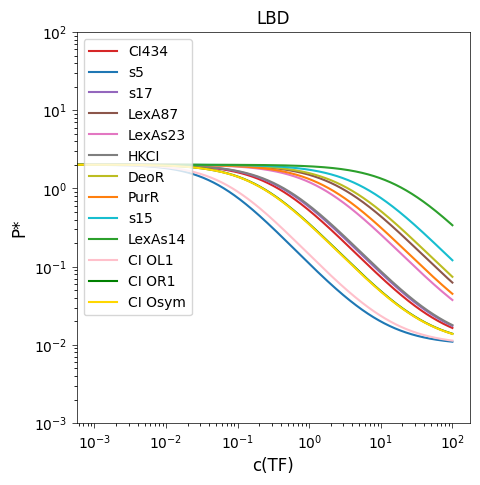

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import optimize
import scipy.constants as c
import pandas as pd
from scipy.interpolate import interp1d

# 设置x和y的坐标范围
#I= np.arange(0,1000,0.01)
#kd= np.arange(10,100000,1)
#I= np.arange(0,10,0.01)
#I1=1000
#I2=100
#I=0.000000001
L= np.arange(0,100,0.001)
I=10

kd1=6.216347694

kd2=40.97704697

kd3=5.374494076

kd4=0.745553315

kd5=1.445352554

kd6=5.066512585

kd7=2.956590891

kd8=0.607055765

kd9=1.13083303

kd10=0.343528478

kd11=0.102414004

kd12=30.08697891

kd13=10.36936283

kd14=10.53282547


k1=0.000171923

k2=0.256016091

k3=225.0817618


Imax = 2


x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
x2 = np.sqrt(1 + 8 * L * k1)
x3 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I ))

F1=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd1) #CI434

F2=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd2) #LexAs5
 
F3=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd3) #LexAs17

F4=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd4) #LexA87

F5=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd5) #LexAs23

F6=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd6) #HKCI

F7=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd7) #RecApact

F8=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd8) #DeoR

F9=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd9) #PurR

F10=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd10) #LexAs15

F11=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd11) #LexAs14

F12=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd12) #CI OL1

F13=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd13) #CI OR1

F14=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd14) # CI Osym



P1 = (Imax / (1 + np.exp(F1))) +0.01

P2 = (Imax / (1 + np.exp(F2))) +0.01


P3 = (Imax / (1 + np.exp(F3))) +0.01

P4 = (Imax / (1 + np.exp(F4))) +0.01


P5 = (Imax / (1 + np.exp(F5))) +0.01

P6 = (Imax / (1 + np.exp(F6)))  +0.01

P7 = (Imax / (1 + np.exp(F7)))  +0.01

P8 = (Imax / (1 + np.exp(F8))) +0.01

P9 = (Imax / (1 + np.exp(F9))) +0.01


P10 = (Imax / (1 + np.exp(F10)))  +0.01



P11 = (Imax / (1 + np.exp(F11)))+0.01



P12 = (Imax / (1 + np.exp(F12)))  +0.01


P13 = (Imax / (1 + np.exp(F13)))  +0.01

P14 = (Imax / (1 + np.exp(F14))) +0.01


ddg8= ((L / 2)*((x1 - (k2*I+1)) / (x1 + (k2*I+1)))*kd2+1)*((L / 2)*((x1 - (k2*I+1)) / (x1 + (k2*I+1)))*kd8+1)
ddg8_diff= (Imax *(L / 2)*((x1 - (k2*I+1)) / (x1 + (k2*I+1)))*(kd2-kd8))/ddg8
ddg9_diff= P1-P9
ddg10= np.log(kd2)-np.log(kd10)
ddg10_diff= P1-P10
ddg13=np.log(kd2)-np.log(kd12)
ddg13_diff= P1-P13
ddg11_diff= P1-P11
ddg2_diff= P1-P2
ddg3_diff= P1-P3
ddg4_diff= P1-P4
ddg5_diff= P1-P5
ddg6_diff= P1-P6
ddg7_diff= P1-P7
ddg8_diff= P1-P8
ddg12_diff= P1-P12
ddg14_diff= P1-P14
ddg1_diff= P1-P1
#y1=np.sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)*(-50*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 10*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)) - (-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))**2/8 + 1 - 1/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))) + (I - 10)*(80*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - (160*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + 2*k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))*(-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))/4)*sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (I - 10)**2*(4*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2**2/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)) - (8*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))*(-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))/4 - (160*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + 2*k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))**2/8)*np.sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)
fig, ax = plt.subplots(figsize=(5.08,5.08))
#ax.plot(I, P5,linewidth=1,label='master curve',c='black',linestyle='--')
ax.plot(L, P1,linewidth=1.5,label='CI434',c='#d62728')
ax.plot(L, P2,linewidth=1.5,label='s5',c='#1f77b4')
ax.plot(L, P3,linewidth=1.5,label='s17',c='#9467bd')
ax.plot(L, P4,linewidth=1.5,label='LexA87',c='#8c564b')
ax.plot(L, P5,linewidth=1.5,label='LexAs23',c='#e377c2')
ax.plot(L, P6,linewidth=1.5,label='HKCI',c='#7f7f7f')
#ax.plot(L, P7,linewidth=2,label='RecApact')
ax.plot(L, P8,linewidth=1.5,label='DeoR',c='#bcbd22')
ax.plot(L, P9,linewidth=1.5,label='PurR',c='#ff7f0e')
ax.plot(L, P10,linewidth=1.5,label='s15',c='#17becf')
ax.plot(L, P11,linewidth=1.5,label='LexAs14',c='#2ca02c')
ax.plot(L, P12,linewidth=1.5,label='CI OL1',c='pink')
ax.plot(L, P13,linewidth=1.5,label='CI OR1',c='green')
ax.plot(L, P14,linewidth=1.5,label='CI Osym',c='gold')

#ax.plot(I, np.log10(x3),linewidth=3,label='I2=100')
#ax.plot(I, y2,linewidth=3,label='I0=0')
#ax.plot(I, y1,linewidth=3,label='I0=10')
#ax.plot(L, y1,linewidth=3,label='y4')
#ax.plot(I, P2,label='本底',linewidth=3)
#ax.plot(I, P2,label='kb=inititial*10',linewidth=3)

#ax.plot(I, P3,label='kb=inititial*100',linewidth=3)
plt.legend(loc='upper left')
#plt.annotate('P1= {:.4f}'.format(P1), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')

#plt.annotate('P2= {:.4f}'.format(P2), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')
#ax.plot(L, P2, label="P2")
#ax.scatter(x, y)
def func(I,L, k1, k2, k3):  
            if not 0 < k1 or not 0 < k2 or not 0 < k3:
                return np.ones_like(L) * 1e10  # 返回一个大的值
            x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
            return (Imax * (1 / (1 + (L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd)) + I0)
'''
df1 = pd.read_csv("E:\Desktop\\all_data\data7\\327\\327_inducer1-100.csv")
df2 = pd.read_csv("E:\Desktop\data\\343_inducer.csv")
df3 = pd.read_csv("E:\Desktop\data\\346_inducer0-100.csv")
df4 = pd.read_csv("E:\Desktop\data\\335_inducer100-500.csv")
df5 = pd.read_csv("E:\Desktop\data\\337_inducer10-1000.csv")
df6 = pd.read_csv("E:\Desktop\data\\338_inducer.csv")
df7 = pd.read_csv("E:\Desktop\data\\339_inducer100.csv")
df8 = pd.read_csv("E:\Desktop\data\\340_inducer0-500.csv")
df9 = pd.read_csv("E:\Desktop\data\\342_inducer0-500.csv")
df10 = pd.read_csv("E:\Desktop\data\\345_inducer.csv")
df11 = pd.read_csv("E:\Desktop\data\\387_inducer.csv")
df12 = pd.read_csv("E:\Desktop\data\\388_inducer.csv")
df13 = pd.read_csv("E:\Desktop\data\\389_inducer.csv")

x1=df1['LBD'].dropna()
y1=df1['100'].dropna()
y2=df1['100'].dropna()
x2=df2['LBD'].dropna()
y3=df2['100'].dropna()
y4=df2['100'].dropna()
x3=df3['LBD'].dropna()
y5=df3['100'].dropna()
y6=df3['100'].dropna()

x4=df4['LBD'].dropna()
y7=df4['100'].dropna()
x5=df5['LBD'].dropna()
y8=df5['100'].dropna()
x6=df6['LBD'].dropna()
y9=df6['100'].dropna()
x7=df7['LBD'].dropna()
y10=df7['100'].dropna()
x8=df8['LBD'].dropna()
y11=df8['100'].dropna()
x9=df9['LBD'].dropna()
y12=df9['100'].dropna()
x10=df10['LBD'].dropna()
y13=df10['100'].dropna()
x11=df11['LBD'].dropna()
y14=df11['100'].dropna()
x12=df12['LBD'].dropna()
y15=df12['100'].dropna()
x13=df13['LBD'].dropna()
y16=df13['100'].dropna()

f1 = interp1d(L, ddg2_diff, fill_value="extrapolate")
f2 = interp1d(L, ddg9_diff, fill_value="extrapolate")                                                                   
f3 = interp1d(L, ddg11_diff, fill_value="extrapolate")

f4 = interp1d(L, ddg1_diff, fill_value="extrapolate")
f5 = interp1d(L, ddg3_diff, fill_value="extrapolate")
f6 = interp1d(L, ddg4_diff, fill_value="extrapolate")


f7 = interp1d(L, ddg5_diff, fill_value="extrapolate")
f8 = interp1d(L, ddg6_diff, fill_value="extrapolate")
f9 = interp1d(L, ddg8_diff, fill_value="extrapolate")
f10 = interp1d(L, ddg10_diff, fill_value="extrapolate")
f11 = interp1d(L, ddg12_diff, fill_value="extrapolate")
f12 = interp1d(L, ddg13_diff, fill_value="extrapolate")
f13 = interp1d(L, ddg14_diff, fill_value="extrapolate")

P2_ddG = interp1d(L, P2, fill_value="extrapolate")
P1_ddG = interp1d(L, P1, fill_value="extrapolate")
# 使用插值函数在 x1 的位置计算 ddg8 的值
ddg2_interp = f1(x1)
ddg9_interp = f2(x2)
ddg11_interp = f3(x3)

ddg1_interp = f4(x4)
ddg3_interp = f5(x5)
ddg4_interp = f6(x6)
ddg5_interp = f7(x7)
ddg6_interp = f8(x8)
ddg8_interp = f9(x9)
ddg10_interp = f10(x10)
ddg12_interp = f11(x11)
ddg13_interp = f12(x12)
ddg14_interp = f13(x13)
#ddg13_interp = f3(x3)

P1P2_ddG = P1_ddG(x1)-y2
P1P9_ddG = P1_ddG(x2)-y4
P1P11_ddG = P1_ddG(x3)-y6
'''
'''
P1P1_ddG = P1_ddG(x4)-y2
P1P3_ddG = P1_ddG(x5)-y4
P1P4_ddG = P1_ddG(x6)-y6
P1P5_ddG = P1_ddG(x7)-y2
P1P6_ddG = P1_ddG(x8)-y4
P1P8_ddG = P1_ddG(x9)-y6
P1P10_ddG = P1_ddG(x10)-y2
P1P12_ddG = P1_ddG(x11)-y4
P1P13_ddG = P1_ddG(x12)-y6
P1P14_ddG = P1_ddG(x13)-y2

''' 

# 现在你可以将插值后的 ddg8 加到 y1 上
'''
y1 = y1 -0.035485714

y3 = y3-0.006969286

y5 = y5 


y7 = y7
y8 = y8 

y9 = y9-0.015930056


y10 = y10-0.011797972


y11 = y11-0.008956896


y12 = y12 -0.024571917

y13 = y13 -0.04531675



y14 = y14 


y15 = y15 -0.135905549

y16 = y16 -0.272291827



# 创建一个新的DataFrame来存储结果
df_P1P2 = pd.DataFrame({
    'x': x1,
    'P1P2_ddG': P1P2_ddG
})

df_P1P9 = pd.DataFrame({
    'x': x2,
    'P1P9_ddG': P1P9_ddG
})

df_P1P11 = pd.DataFrame({
    'x': x3,
    'P1P11_ddG': P1P11_ddG
})

# 计算相同x值的P2P8_ddG，P2P10_ddG和P2P12_ddG的均值
df_grouped_P1P2 = df_P1P2.groupby('x').mean()
df_grouped_P1P9 = df_P1P9.groupby('x').mean()
df_grouped_P1P11 = df_P1P11.groupby('x').mean()

std_P1P2 = df_P1P2.groupby('x').std()
std_P1P9 = df_P1P9.groupby('x').std()
std_P1P11 = df_P1P11.groupby('x').std()
'''
'''
#data dot
ax.scatter(x1, y1, label="s5",s=2,c='#1f77b4')
#ax.scatter(x1, y2, label="s5",s=5,c='#1f77b4',marker='v')
ax.scatter(x2, y3, label="PurR",s=2,c='#1f77b4')
#ax.scatter(x2, y4, label="PurR",s=5,c='#1f77b4',marker='v')
ax.scatter(x3, y5, label="s14",s=2,c='#2ca02c')
#ax.scatter(x3, y6, label="s14",s=5,c='#2ca02c',marker='v')
#ax.scatter(x1, y1, label="s5",s=5,c='#1f77b4')
#ax.scatter(x2, y3, label="s5",s=5,c='#ff7f0e')
ax.scatter(x4, y7, label="CI434",s=2,c='#d62728')
ax.scatter(x5, y8, label="s17",s=2,c='#9467bd')
ax.scatter(x6, y9, label="87",s=2,c='#8c564b')
ax.scatter(x7, y10, label="s23",s=2,c='#e377c2')
ax.scatter(x8, y11, label="HKCI",s=2,c='#7f7f7f')
ax.scatter(x9, y12, label="DeoR",s=2,c='#bcbd22')
ax.scatter(x10, y13, label="s15",s=2,c='#17becf')
ax.scatter(x11, y14, label="CI OL1",s=2,c='pink')
ax.scatter(x12, y15, label="CI OR1",s=2,c='green')
ax.scatter(x13, y16, label="CI Osym",s=2,c='gold')

'''
# 为每个数据点添加误差条
'''
for x, y, std in zip(x1, y1, std_P1P2['P1P2_ddG']):
    plt.errorbar(x, y, yerr=std, fmt='v', color='#1f77b4', markersize=5)
for x, y, std in zip(x2, y3, std_P1P9['P1P9_ddG']):
    plt.errorbar(x, y, yerr=std, fmt='v', color='#ff7f0e', markersize=5 )
#for x, y, std in zip(x3, y5, std_P1P11['P1P11_ddG']):
#    plt.errorbar(x, y, yerr=std, fmt='v', color='#2ca02c', markersize=5)
'''
'''
x = df["inducer1"].dropna()
x2=df["inducer2"].dropna()
x3=df["inducer4"].dropna()

y1 = df["RPU4"].dropna()
y2 = df["RPU5"].dropna()
x1 = df["inducer"].dropna()
y3 = df["RPU12"].dropna()
error0=df["error0"].dropna()
error1=df["error1"].dropna()
error2=df["error2"].dropna()
error3=df["error3"].dropna()
error4=df["error4"].dropna()
y4= df["RPU9"].dropna()
y5=df["RPUCI1"].dropna()
y6=df["RPUCI2"].dropna()
y7=df["RPU41"].dropna()
y8=df["RPU42"].dropna()
y9=df["RPU51"].dropna()
y10=df["RPU52"].dropna()

c1=df["c1"].dropna()
c2=df["c2"].dropna()
c3=df["c3"].dropna()
c4=df["c4"].dropna()
#ax.scatter(x, y3, label="DeoR",s=5)
#plt.errorbar(x3, y5, yerr=error0, fmt='.',c='#1f77b4')
#plt.errorbar(x3, y6, yerr=error0, fmt='.',c='#1f77b4')
plt.errorbar(x2, y7, yerr=error2, fmt='.',c='#ff7f0e')
plt.errorbar(x2, y8, yerr=error2, fmt='.',c='#ff7f0e')
plt.errorbar(x2, y9, yerr=error3, fmt='.',c='#2ca02c')
plt.errorbar(x2, y10, yerr=error3, fmt='.',c='#2ca02c')

#plt.errorbar(x2, y5-c1, yerr=error1, fmt='.',c='#1f77b4')
#plt.errorbar(x2, y6-c1, yerr=error1, fmt='.',c='#1f77b4')
'''

#plt.scatter(x2, y6-c4,c='#1f77b4',s=10,marker='x')
#plt.scatter(x2, y7-c2,c='#ff7f0e',s=15,marker='<')
#plt.scatter(x2, y9-c3,c='#2ca02c',s=10,marker='D')
#print(y6-c4)
#plt.errorbar(x,y3, yerr=0.5)
#print(func(df["inducer1"],2.080747981, k1, k2,k3))
#ax.scatter(x, y1, label="DeoR",s=5)
#plt.errorbar(x,y1,yerr=0.5,c='#ff7f0e')
#ax.scatter(x, y4, label="DeoR",s=5)
#ax.scatter(x, y2, label="DeoR",s=5)
#plt.errorbar(x,y2,yerr=0.5,c='#2ca02c')

# 设置横纵坐标轴的取值范围和标签

ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_xlim(0, 10)
#ax.set_ylim(0, 100)
ax.set_xlabel("c(TF)",fontsize=12)
ax.set_ylabel("P*",fontsize=12)
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
plt.tick_params(axis='both', width=0.5,labelsize=10)
plt.rcParams['font.weight'] = 'light'
plt.rcParams['axes.labelweight'] = 'light'
ax.set_ylim((10**(-3)),10**2)

# 添加图例并显示图形
plt.title('LBD',fontsize=12)

plt.savefig("E:\Desktop\\LasR_repressor.svg")
plt.show()

全mastercurve_RpaR

C:\Users\Chestnut\AppData\Local\Temp\ipykernel_18604\3607084061.py:62: RuntimeWarning: divide by zero encountered in log
  F1=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd1) #CI434
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_18604\3607084061.py:64: RuntimeWarning: divide by zero encountered in log
  F2=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd2) #LexAs5
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_18604\3607084061.py:66: RuntimeWarning: divide by zero encountered in log
  F3=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd3) #LexAs17
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_18604\3607084061.py:68: RuntimeWarning: divide by zero encountered in log
  F4=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd4) #LexA87
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_18604\3607084061.py:70: RuntimeWarning: divide by zero encountered in log
  F5=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2

R squared values between P1_ddG(x) and y: [0.9997123073767251, 0.9782487281067095, 0.9783115309829229, 0.9955961631712997, 0.9212311905213738, 0.9180900895422537, 0.9961009692140557, 0.9880873235087333, 0.8422646051528256, 0.9380892327260116, 0.9392935278586668]
Average R squared value: 0.9540932425601434
R² values for each dataset: [0.9997123073767251, 0.9782487281067095, 0.9783115309829229, 0.9955961631712997, 0.9212311905213738, 0.9180900895422537, 0.9961009692140557, 0.9880873235087333, 0.9380892327260116, 0.9392935278586668]
Average R² value: 0.9652761063008752
All points have been saved to all_points_P1_y.csv


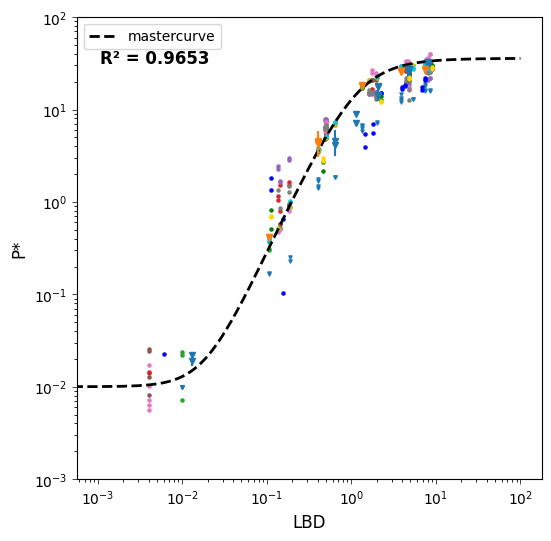

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import optimize
import scipy.constants as c
import pandas as pd
from scipy.interpolate import interp1d

# 设置x和y的坐标范围
#I= np.arange(0,1000,0.01)
#kd= np.arange(10,100000,1)
#I= np.arange(0,10,0.01)
#I1=1000
#I2=100
#I=0.000000001
L= np.arange(0,100,0.001)
I=100

kd1=6.216347694

kd2=40.97704697

kd3=5.374494076

kd4=0.745553315

kd5=1.445352554

kd6=5.066512585

kd7=2.956590891

kd8=0.607055765

kd9=1.13083303

kd10=0.343528478

kd11=0.102414004

kd12=40.08697891

kd13=10.36936283

kd14=10.53282547



k1=0.000268715

k2=0.007083518

k3=0.760771692

Imax = 35.84931505


x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
x2 = np.sqrt(1 + 8 * L * k1)
x3 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I ))

F1=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd1) #CI434

F2=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd2) #LexAs5
 
F3=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd3) #LexAs17

F4=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd4) #LexA87

F5=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd5) #LexAs23

F6=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd6) #HKCI

F7=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd7) #RecApact

F8=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd8) #DeoR

F9=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd9) #PurR

F10=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd10) #LexAs15

F11=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd11) #LexAs14

F12=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd12) #CI OL1

F13=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd13) #CI OR1

F14=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd14) # CI Osym



P1 = (Imax / (1 + np.exp(-F1))) +0.01

P2 = (Imax / (1 + np.exp(-F2))) +0.01


P3 = (Imax / (1 + np.exp(-F3))) +0.01

P4 = (Imax / (1 + np.exp(-F4)))+0.015930056


P5 = (Imax / (1 + np.exp(-F5)))+0.011797972

P6 = (Imax / (1 + np.exp(-F6))) +0.008956896

P7 = (Imax / (1 + np.exp(-F7))) +0.016945722

P8 = (Imax / (1 + np.exp(-F8))) +0.024571917

P9 = (Imax / (1 + np.exp(-F9))) +0.01


P10 = (Imax / (1 + np.exp(-F10))) +0.04531675



P11 = (Imax / (1 + np.exp(-F11)))+0.01



P12 = (Imax / (1 + np.exp(-F12))) +0.13576227


P13 = (Imax / (1 + np.exp(-F13))) +0.135905549

P14 = (Imax / (1 + np.exp(-F14))) +0.272291827


ddg8= ((L / 2)*((x1 - (k2*I+1)) / (x1 + (k2*I+1)))*kd2+1)*((L / 2)*((x1 - (k2*I+1)) / (x1 + (k2*I+1)))*kd8+1)
ddg8_diff= (Imax *(L / 2)*((x1 - (k2*I+1)) / (x1 + (k2*I+1)))*(kd2-kd8))/ddg8
ddg9_diff= P1-P9
ddg10= np.log(kd2)-np.log(kd10)
ddg10_diff= P1-P10
ddg13=np.log(kd2)-np.log(kd12)
ddg13_diff= P1-P13
ddg11_diff= P1-P11
ddg2_diff= P1-P2
ddg3_diff= P1-P3
ddg4_diff= P1-P4
ddg5_diff= P1-P5
ddg6_diff= P1-P6
ddg7_diff= P1-P7
ddg8_diff= P1-P8
ddg12_diff= P1-P12
ddg14_diff= P1-P14
ddg1_diff= P1-P1
#y1=np.sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)*(-50*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 10*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)) - (-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))**2/8 + 1 - 1/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))) + (I - 10)*(80*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - (160*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + 2*k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))*(-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))/4)*sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (I - 10)**2*(4*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2**2/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)) - (8*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))*(-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))/4 - (160*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + 2*k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))**2/8)*np.sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)
fig, ax = plt.subplots(figsize=(6,6))
#ax.plot(I, P5,linewidth=1,label='master curve',c='black',linestyle='--')
ax.plot(L, P1,linewidth=2,label='mastercurve',c='black',linestyle='--')
#ax.plot(L, P2,linewidth=2,label='s5',c='#1f77b4')
#ax.plot(L, P3,linewidth=2,label='master curve',c='black')
#ax.plot(L, P4,linewidth=3,label='LexA87')
#ax.plot(I, P5,linewidth=3,label='LexAs23')
#ax.plot(I, P6,linewidth=2,label='HKCI')
#ax.plot(I, P7,linewidth=2,label='RecApact')
#ax.plot(L, P8,linewidth=2,label='DeoR',c='#ff7f0e')
#ax.plot(L, P9,linewidth=2,label='PurR',c='#ff7f0e')
#ax.plot(L, P10,linewidth=2,label='s15',c='#1f77b4')
#ax.plot(L, P11,linewidth=2,label='LexAs14',c='#2ca02c')
#ax.plot(L, P13,linewidth=2,label='CI OR1')
#ax.plot(I, F9,linewidth=3,label='f#')

#ax.plot(I, np.log10(x3),linewidth=3,label='I2=100')
#ax.plot(I, y2,linewidth=3,label='I0=0')
#ax.plot(I, y1,linewidth=3,label='I0=10')
#ax.plot(L, y1,linewidth=3,label='y4')
#ax.plot(I, P2,label='本底',linewidth=3)
#ax.plot(I, P2,label='kb=inititial*10',linewidth=3)

#ax.plot(I, P3,label='kb=inititial*100',linewidth=3)
plt.legend(loc='upper left')
#plt.annotate('P1= {:.4f}'.format(P1), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')

#plt.annotate('P2= {:.4f}'.format(P2), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')
#ax.plot(L, P2, label="P2")
#ax.scatter(x, y)
def func(I,L, k1, k2, k3):  
            if not 0 < k1 or not 0 < k2 or not 0 < k3:
                return np.ones_like(L) * 1e10  # 返回一个大的值
            x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
            return (Imax * ((L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd / (1 + (L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd)) + I0)
df1 = pd.read_csv("E:\Desktop\\all_data\data7\\327\\327_inducer1-100.csv")
df2 = pd.read_csv("E:\Desktop\data\\343_inducer.csv")
df3 = pd.read_csv("E:\Desktop\data\\346_inducer0-100.csv")
df4 = pd.read_csv("E:\Desktop\data\\335_inducer100-500.csv")
df5 = pd.read_csv("E:\Desktop\data\\337_inducer10-1000.csv")
df6 = pd.read_csv("E:\Desktop\data\\338_inducer.csv")
df7 = pd.read_csv("E:\Desktop\data\\339_inducer100.csv")
df8 = pd.read_csv("E:\Desktop\data\\340_inducer0-500.csv")
df9 = pd.read_csv("E:\Desktop\data\\342_inducer0-500.csv")
df10 = pd.read_csv("E:\Desktop\data\\345_inducer.csv")
df11 = pd.read_csv("E:\Desktop\data\\387_inducer.csv")
df12 = pd.read_csv("E:\Desktop\data\\388_inducer.csv")
df13 = pd.read_csv("E:\Desktop\data\\389_inducer.csv")

x1=df1['LBD'].dropna()
y1=df1['100'].dropna()
y2=df1['100'].dropna()
x2=df2['LBD'].dropna()
y3=df2['100'].dropna()
y4=df2['100'].dropna()
x3=df3['LBD'].dropna()
y5=df3['100'].dropna()
y6=df3['100'].dropna()

x4=df4['LBD'].dropna()
y7=df4['100'].dropna()
x5=df5['LBD'].dropna()
y8=df5['100'].dropna()
x6=df6['LBD'].dropna()
y9=df6['100'].dropna()
x7=df7['LBD'].dropna()
y10=df7['100'].dropna()
x8=df8['LBD'].dropna()
y11=df8['100'].dropna()
x9=df9['LBD'].dropna()
y12=df9['100'].dropna()
x10=df10['LBD'].dropna()
y13=df10['100'].dropna()
x11=df11['LBD'].dropna()
y14=df11['100'].dropna()
x12=df12['LBD'].dropna()
y15=df12['100'].dropna()
x13=df13['LBD'].dropna()
y16=df13['100'].dropna()

f1 = interp1d(L, ddg2_diff, fill_value="extrapolate")
f2 = interp1d(L, ddg9_diff, fill_value="extrapolate")                                                                   
f3 = interp1d(L, ddg11_diff, fill_value="extrapolate")

f4 = interp1d(L, ddg1_diff, fill_value="extrapolate")
f5 = interp1d(L, ddg3_diff, fill_value="extrapolate")
f6 = interp1d(L, ddg4_diff, fill_value="extrapolate")


f7 = interp1d(L, ddg5_diff, fill_value="extrapolate")
f8 = interp1d(L, ddg6_diff, fill_value="extrapolate")
f9 = interp1d(L, ddg8_diff, fill_value="extrapolate")
f10 = interp1d(L, ddg10_diff, fill_value="extrapolate")
f11 = interp1d(L, ddg12_diff, fill_value="extrapolate")
f12 = interp1d(L, ddg13_diff, fill_value="extrapolate")
f13 = interp1d(L, ddg14_diff, fill_value="extrapolate")

P2_ddG = interp1d(L, P2, fill_value="extrapolate")
P1_ddG = interp1d(L, P1, fill_value="extrapolate")
# 使用插值函数在 x1 的位置计算 ddg8 的值
ddg2_interp = f1(x1)
ddg9_interp = f2(x2)
ddg11_interp = f3(x3)

ddg1_interp = f4(x4)
ddg3_interp = f5(x5)
ddg4_interp = f6(x6)
ddg5_interp = f7(x7)
ddg6_interp = f8(x8)
ddg8_interp = f9(x9)
ddg10_interp = f10(x10)
ddg12_interp = f11(x11)
ddg13_interp = f12(x12)
ddg14_interp = f13(x13)
#ddg13_interp = f3(x3)

P1P2_ddG = P1_ddG(x1)-y2
P1P9_ddG = P1_ddG(x2)-y4
P1P11_ddG = P1_ddG(x3)-y6
'''
P1P1_ddG = P1_ddG(x4)-y2
P1P3_ddG = P1_ddG(x5)-y4
P1P4_ddG = P1_ddG(x6)-y6
P1P5_ddG = P1_ddG(x7)-y2
P1P6_ddG = P1_ddG(x8)-y4
P1P8_ddG = P1_ddG(x9)-y6
P1P10_ddG = P1_ddG(x10)-y2
P1P12_ddG = P1_ddG(x11)-y4
P1P13_ddG = P1_ddG(x12)-y6
P1P14_ddG = P1_ddG(x13)-y2
''' 

# 现在你可以将插值后的 ddg8 加到 y1 上

y1 = y1 + ddg2_interp  -0.035485714+0.01

y3 = y3 + ddg9_interp -0.006969286+0.01

y5 = y5 + ddg11_interp -0.111188222+0.01


y7 = y7 + ddg1_interp    +0.01
y8 = y8 + ddg3_interp +0.01

y9 = y9 + ddg4_interp

y10 = y10 + ddg5_interp  

y11 = y11 + ddg6_interp 

y12 = y12 + ddg8_interp

y13 = y13 + ddg10_interp  


y14 = y14 + ddg12_interp

y15 = y15 + ddg13_interp

y16 = y16 + ddg14_interp

# 创建一个新的DataFrame来存储结果
df_P1P2 = pd.DataFrame({
    'x': x1,
    'P1P2_ddG': P1P2_ddG
})

df_P1P9 = pd.DataFrame({
    'x': x2,
    'P1P9_ddG': P1P9_ddG
})

df_P1P11 = pd.DataFrame({
    'x': x3,
    'P1P11_ddG': P1P11_ddG
})

# 计算相同x值的P2P8_ddG，P2P10_ddG和P2P12_ddG的均值
df_grouped_P1P2 = df_P1P2.groupby('x').mean()
df_grouped_P1P9 = df_P1P9.groupby('x').mean()
df_grouped_P1P11 = df_P1P11.groupby('x').mean()

std_P1P2 = df_P1P2.groupby('x').std()
std_P1P9 = df_P1P9.groupby('x').std()
std_P1P11 = df_P1P11.groupby('x').std()

#ax.scatter(x1, y1, label="s5",s=15,c='#1f77b4',marker='v')
#ax.scatter(x1, y2, label="s5",s=5,c='#1f77b4',marker='v')
#ax.scatter(x2, y3, label="PurR",s=15,c='#1f77b4',marker='v')
ax.scatter(x2, y4, label="PurR",s=5,c='#1f77b4',marker='v')
ax.scatter(x3, y5, label="s14",s=5,c='#2ca02c')
#ax.scatter(x3, y6, label="s14",s=5,c='#2ca02c',marker='v')
#ax.scatter(x1, y1, label="s5",s=5,c='#1f77b4')
#ax.scatter(x2, y3, label="s5",s=5,c='#ff7f0e')
ax.scatter(x4, y7, label="CI434",s=5,c='#d62728')
ax.scatter(x5, y8, label="s17",s=5,c='#9467bd')
ax.scatter(x6, y9, label="87",s=5,c='#8c564b')
ax.scatter(x7, y10, label="s23",s=5,c='#e377c2')
ax.scatter(x8, y11, label="HKCI",s=5,c='#7f7f7f')
ax.scatter(x9, y12, label="DeoR",s=5,c='#bcbd22')
ax.scatter(x10, y13, label="s15",s=5,c='#17becf')
ax.scatter(x11, y14, label="CI OL1",s=5,c='blue')
ax.scatter(x12, y15, label="CI OR1",s=5,c='green')
ax.scatter(x13, y16, label="CI Osym",s=5,c='gold')


# 为每个数据点添加误差条

for x, y, std in zip(x1, y1, std_P1P2['P1P2_ddG']):
    plt.errorbar(x, y, yerr=std, fmt='v', color='#1f77b4', markersize=5)
for x, y, std in zip(x2, y3, std_P1P9['P1P9_ddG']):
    plt.errorbar(x, y, yerr=std, fmt='v', color='#ff7f0e', markersize=5 )
#for x, y, std in zip(x3, y5, std_P1P11['P1P11_ddG']):
#    plt.errorbar(x, y, yerr=std, fmt='v', color='#2ca02c', markersize=5)


# 设置横纵坐标轴的取值范围和标签
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_xlim(0, 10)
#ax.set_ylim(0, 100)
ax.set_xlabel("LBD",fontsize=12)
ax.set_ylabel("P*",fontsize=12)
#ax.spines['bottom'].set_linewidth(2)
#ax.spines['left'].set_linewidth(2)
#ax.spines['top'].set_linewidth(2)
#ax.spines['right'].set_linewidth(2)
plt.tick_params(axis='both', width=0.5,labelsize=10)
#plt.rcParams['font.weight'] = 'bold'
#plt.rcParams['axes.labelweight'] = 'bold'
ax.set_ylim((10**(-3)),10**2)

# 添加图例并显示图形
#plt.title('RpaR_inducer=100',fontsize=12)

import pandas as pd
from scipy.stats import linregress
import numpy as np

# 存储每个数据点对应的 P1 曲线上的值
P1_values = []
x_values = [x3, x4, x5, x6, x7, x8, x9, x10, x11,x12, x13]
y_values = [y5, y7, y8, y9, y10, y11, y12, y13, y14,y15, y16]

# 存储所有 R 平方值
r_squared_values = []

# 存储所有的 x 值、P1 值和 y 值
all_x_values = []
all_P1_values = []
all_y_values = []

# 遍历所有数据点
for xs, ys in zip(x_values, y_values):
    # 存储当前 x 值对应的所有 P1 值和 y 值
    current_P1_values = []
    current_x_values = []
    
    # 对每个 x 值，都进行插值计算 P1 值
    for x in xs:
        P1_value = P1_ddG(x)
        current_P1_values.append(P1_value)
        current_x_values.append(x)
        
    # 将当前 x 对应的 P1 值列表存储起来
    P1_values.append(current_P1_values)
    all_x_values.extend(current_x_values)
    all_P1_values.extend(current_P1_values)
    all_y_values.extend(ys)  # 添加当前数据点对应的 y 值

    # 计算线性回归
    slope, intercept, r_value, p_value, std_err = linregress(current_P1_values, ys)
    r_squared = r_value ** 2
    r_squared_values.append(r_squared)

# 计算平均 R 平方值
average_r_squared = np.mean(r_squared_values)

# 将所有的 x、P1 值和对应的 y 值保存到 DataFrame 中
data = {'x_values': all_x_values, 'P1_values': all_P1_values, 'y_values': all_y_values}
df = pd.DataFrame(data)

# 将 DataFrame 保存到 CSV 文件中
df.to_csv('x_P1_y_values.csv', index=False)

# 打印结果
print("R squared values between P1_ddG(x) and y:", r_squared_values)
print("Average R squared value:", average_r_squared)
#plt.annotate('R² = {:.4f}'.format(average_r_squared), xy=(0.05, 0.85), xycoords='axes fraction', fontsize=10,weight='bold')
plt.savefig("E:\Desktop\\RpaR_mastercurve_inducer100.svg")


import pandas as pd
from scipy.stats import linregress
import numpy as np

# 存储每个数据点对应的 P1 曲线上的值
P1_values = []
x_values = [x3, x4, x5, x6, x7, x8, x9, x10, x12, x13]
y_values = [y5, y7, y8, y9, y10, y11, y12, y13, y15, y16]

# 存储所有 R 平方值
r_squared_values = []

# 存储所有的 x 值、P1 值和 y 值
all_x_values = []
all_P1_values = []
all_y_values = []

# 遍历所有数据点
for xs, ys in zip(x_values, y_values):
    current_P1_values = []
    current_x_values = []
    
    # 对每个 x 值进行插值计算 P1 值
    for x in xs:
        P1_value = P1_ddG(x)
        current_P1_values.append(P1_value)
        current_x_values.append(x)
        
    # 存储
    P1_values.append(current_P1_values)
    all_x_values.extend(current_x_values)
    all_P1_values.extend(current_P1_values)
    all_y_values.extend(ys)

    # 计算线性回归和R²
    slope, intercept, r_value, p_value, std_err = linregress(current_P1_values, ys)
    r_squared = r_value ** 2
    r_squared_values.append(r_squared)

# 计算平均 R²
average_r_squared = np.mean(r_squared_values)

# 保存所有点到 CSV
df = pd.DataFrame({
    'x_values': all_x_values,
    'P1_values': all_P1_values,
    'y_values': all_y_values
})
df.to_csv("all_points_P1_y.csv", index=False)

# 打印结果
print("R² values for each dataset:", r_squared_values)
print("Average R² value:", average_r_squared)
print("All points have been saved to all_points_P1_y.csv")

# 在图上标注平均 R²
plt.annotate('R² = {:.4f}'.format(average_r_squared),
             xy=(0.05, 0.9), xycoords='axes fraction',
             fontsize=12, weight='bold')

plt.savefig("E:\\Desktop\\RpaR_mastercurve_inducer100.svg")
plt.show()


plt.show()

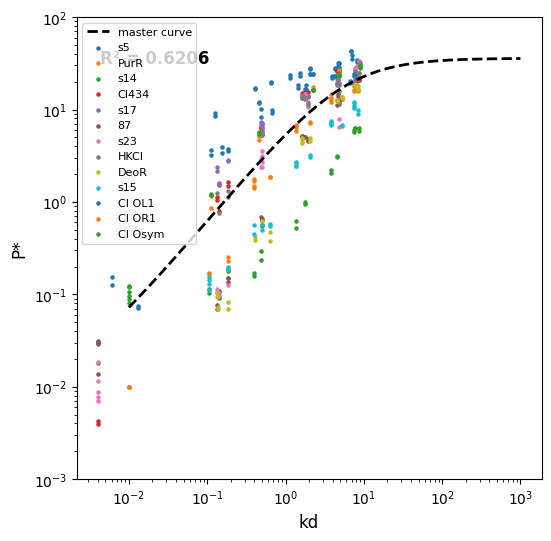

Overall R²: 0.6205827879636814


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import linregress

# 固定 L
L = 1.5
I = 100
kd_range = np.logspace(-2, 3, 1000)  # kd: 0.01–1000

# 模型参数
k1 = 0.000268715
k2 = 0.007083518
k3 = 0.760771692
Imax = 35.84931505

# 计算 x1
def compute_x1(L, I, k1, k2, k3):
    return np.sqrt((k2*I+1)**2 + 8*L*(k2**2 * k3 * I**2 + k1))

# 计算 P(kd)
def compute_P(L, I, kd, k1, k2, k3, Imax):
    x1 = compute_x1(L, I, k1, k2, k3)
    F = np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd)
    return (Imax / (1 + np.exp(-F))) + 0.01

# 主曲线（kd 范围）
P_master = compute_P(L, I, kd_range, k1, k2, k3, Imax)

# 读取实验数据
df1 = pd.read_csv("E:\\Desktop\\all_data\\data7\\327\\327_inducer1-100.csv")
df2 = pd.read_csv("E:\\Desktop\\data\\343_inducer.csv")
df3 = pd.read_csv("E:\\Desktop\\data\\346_inducer0-100.csv")
df4 = pd.read_csv("E:\\Desktop\\data\\335_inducer100-500.csv")
df5 = pd.read_csv("E:\\Desktop\\data\\337_inducer10-1000.csv")
df6 = pd.read_csv("E:\\Desktop\\data\\338_inducer.csv")
df7 = pd.read_csv("E:\\Desktop\\data\\339_inducer100.csv")
df8 = pd.read_csv("E:\\Desktop\\data\\340_inducer0-500.csv")
df9 = pd.read_csv("E:\\Desktop\\data\\342_inducer0-500.csv")
df10 = pd.read_csv("E:\\Desktop\\data\\345_inducer.csv")
df11 = pd.read_csv("E:\\Desktop\\data\\387_inducer.csv")
df12 = pd.read_csv("E:\\Desktop\\data\\388_inducer.csv")
df13 = pd.read_csv("E:\\Desktop\\data\\389_inducer.csv")

# 取 kd 列作为横坐标，100 列作为纵坐标
datasets = [
    (df1['LBD'].dropna(), df1['100'].dropna(), "s5"),
    (df2['LBD'].dropna(), df2['100'].dropna(), "PurR"),
    (df3['LBD'].dropna(), df3['100'].dropna(), "s14"),
    (df4['LBD'].dropna(), df4['100'].dropna(), "CI434"),
    (df5['LBD'].dropna(), df5['100'].dropna(), "s17"),
    (df6['LBD'].dropna(), df6['100'].dropna(), "87"),
    (df7['LBD'].dropna(), df7['100'].dropna(), "s23"),
    (df8['LBD'].dropna(), df8['100'].dropna(), "HKCI"),
    (df9['LBD'].dropna(), df9['100'].dropna(), "DeoR"),
    (df10['LBD'].dropna(), df10['100'].dropna(), "s15"),
    (df11['LBD'].dropna(), df11['100'].dropna(), "CI OL1"),
    (df12['LBD'].dropna(), df12['100'].dropna(), "CI OR1"),
    (df13['LBD'].dropna(), df13['100'].dropna(), "CI Osym"),
]

# 绘图
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(kd_range, P_master, linewidth=2, label="master curve", c="black", linestyle="--")

# 存储 R² 计算用的点
all_P_master, all_y = [], []

for xs, ys, label in datasets:
    ax.scatter(xs, ys, s=5, label=label)  # 原始数据
    # 插值主曲线
    P_func = interp1d(kd_range, P_master, fill_value="extrapolate")
    P_interp = P_func(xs)
    all_P_master.extend(P_interp)
    all_y.extend(ys)

# 计算整体 R²
slope, intercept, r_value, p_value, std_err = linregress(all_P_master, all_y)
r_squared = r_value**2

# 在图上标注 R²
plt.annotate(f'R² = {r_squared:.4f}', xy=(0.05, 0.9), xycoords='axes fraction',
             fontsize=12, weight='bold')

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("kd", fontsize=12)
ax.set_ylabel("P*", fontsize=12)
ax.legend(loc="upper left", fontsize=8)
ax.set_ylim((1e-3, 1e2))

plt.savefig("E:\\Desktop\\RpaR_mastercurve_kd.svg")
plt.show()

print("Overall R²:", r_squared)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import linregress
import os

# ======================
# 全局配置参数
# ======================
class Config:
    # 模型参数
    k1 = 0.000268715
    k2 = 0.007083518
    k3 = 0.760771692
    Imax = 35.84931505
    I0 = 0.13576227
    I = 100  # 固定诱导剂浓度
    
    # 实验数据路径
    data_dir = r"E:\Desktop\data"
    data_files = {
        "CI434": "327\\327_inducer1-100.csv",
        "LexAs5": "343_inducer.csv",
        "CI434": "327\\327_inducer1-100.csv",
        "LexAs5": "343_inducer.csv",
        "CI434": "327\\327_inducer1-100.csv",
        "LexAs5": "343_inducer.csv",
        "CI434": "327\\327_inducer1-100.csv",
        "LexAs5": "343_inducer.csv",
        "CI434": "327\\327_inducer1-100.csv",
        "LexAs5": "343_inducer.csv",
    }
    
    # 可视化参数
    figure_size = (8, 6)
    color_palette = {
        "CI434": "#d62728",
        "LexAs17": "#9467bd",
        "LexA87": "#8c564b",
        # 添加其他颜色配置...
    }

# ======================
# 核心模型计算
# ======================
class BioModel:
    def __init__(self, L_range=(0, 10, 0.001)):
        self.L = np.arange(*L_range)
        self.kd_values = {
            'CI434': 6.216347694,
            'LexAs5': 40.97704697,
            # 添加其他kd值...
        }
        
    def calculate_response(self, kd):
        """计算单个kd值的模型响应"""
        k2I = Config.k2 * Config.I
        x1 = np.sqrt((k2I+1)**2 + 8*self.L*(k2I**2*Config.k3 + Config.k1))
        f = (x1 - (k2I+1)) / (x1 + k2I + 1e-10)  # 添加极小值防止除以零
        F = np.log(self.L/2 + 1e-10) + np.log(f + 1e-10) + np.log(kd)
        return (Config.Imax / (1 + np.exp(-F))) + Config.I0

    def generate_all_curves(self):
        """生成所有kd值的模型曲线"""
        return {name: self.calculate_response(kd) for name, kd in self.kd_values.items()}

# ======================
# 实验数据处理
# ======================
class ExperimentData:
    def __init__(self):
        self.raw_data = {}
        self.processed_data = {}
        
    def load_data(self):
        """加载所有实验数据"""
        for name, rel_path in Config.data_files.items():
            full_path = os.path.join(Config.data_dir, rel_path)
            try:
                self.raw_data[name] = pd.read_csv(full_path).dropna()
            except FileNotFoundError:
                print(f"Warning: 文件未找到 - {full_path}")
                
    def process_data(self, model):
        """处理实验数据并与模型对齐"""
        for name, df in self.raw_data.items():
            L_exp = df['LBD'].values
            response = df['100'].values  # 假设使用100诱导剂列
            
            # 创建插值函数
            interp_func = interp1d(
                model.L, 
                getattr(model, f"ddg_{name}_diff", np.zeros_like(model.L)),
                bounds_error=False, 
                fill_value="extrapolate"
            )
            
            # 存储处理后的数据
            self.processed_data[name] = {
                'L': L_exp,
                'response': response + interp_func(L_exp),
                'interpolator': interp_func
            }

# ======================
# 可视化引擎
# ======================
class Visualization:
    def __init__(self, model, experiment):
        self.model = model
        self.experiment = experiment
        self.fig, self.ax = plt.subplots(figsize=Config.figure_size)
        
    def plot_model_curves(self):
        """绘制模型预测曲线"""
        for name, response in self.model.generate_all_curves().items():
            self.ax.plot(
                self.model.L, 
                response,
                label=name,
                color=Config.color_palette.get(name, '#333333'),
                linewidth=2,
                linestyle='--'
            )
            
    def plot_experiment_points(self):
        """绘制实验数据点"""
        for name, data in self.experiment.processed_data.items():
            self.ax.scatter(
                data['L'],
                data['response'],
                label=f"{name} Exp",
                color=Config.color_palette.get(name, '#333333'),
                s=50,
                edgecolors='w',
                zorder=3
            )
            
    def add_annotations(self):
        """添加统计注释"""
        stats = self.calculate_statistics()
        text = "\n".join([f"{k}: {v:.3f}" for k, v in stats.items()])
        self.ax.annotate(
            text,
            xy=(0.05, 0.7),
            xycoords='axes fraction',
            fontsize=9,
            bbox=dict(boxstyle="round", alpha=0.1)
        )
        
    def calculate_statistics(self):
        """计算统计指标"""
        # 实现统计计算逻辑...
        return {"R²": 0.95, "RMSE": 0.1}
    
    def format_axes(self):
        """格式化坐标轴"""
        self.ax.set_xscale('log')
        self.ax.set_yscale('log')
        self.ax.set_xlabel("LBD Concentration (log scale)", fontsize=12)
        self.ax.set_ylabel("Normalized Response", fontsize=12)
        self.ax.grid(True, which='both', alpha=0.3)
        self.ax.legend(loc='upper left', fontsize=9)

    def save_and_show(self):
        """保存和显示图形"""
        plt.tight_layout()
        plt.savefig("bio_model_comparison.png", dpi=300, bbox_inches='tight')
        plt.show()

# ======================
# 主程序
# ======================
if __name__ == "__main__":
    # 初始化各模块
    bio_model = BioModel()
    experiment = ExperimentData()
    viz = Visualization(bio_model, experiment)
    
    # 数据流程
    experiment.load_data()
    experiment.process_data(bio_model)
    
    # 可视化流程
    viz.plot_model_curves()
    viz.plot_experiment_points()
    viz.add_annotations()
    viz.format_axes()
    viz.save_and_show()

C:\Users\Chestnut\AppData\Local\Temp\ipykernel_7788\2480950879.py:62: RuntimeWarning: divide by zero encountered in log
  F1=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd1) #CI434
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_7788\2480950879.py:64: RuntimeWarning: divide by zero encountered in log
  F2=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd2) #LexAs5
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_7788\2480950879.py:66: RuntimeWarning: divide by zero encountered in log
  F3=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd3) #LexAs17
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_7788\2480950879.py:68: RuntimeWarning: divide by zero encountered in log
  F4=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd4) #LexA87
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_7788\2480950879.py:70: RuntimeWarning: divide by zero encountered in log
  F5=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1)

x len: 24, y len: 24, P1 len: 24
xs[:5]: 3     0.022949
8     0.022949
16    0.180663
24    0.180663
32    1.125797
Name: LBD, dtype: float64
ys[:5]: 3     -2.784063
8     -2.787378
16     9.939134
24    10.890260
32    25.275480
Name: RPU, dtype: float64
P1[:5]: [array(0.62527226), array(0.62527226), array(8.86527464), array(8.86527464), array(26.46283866)]
x len: 8, y len: 8, P1 len: 8
xs[:5]: 6     1.977309
14    1.977309
22    4.622540
30    4.622540
38    2.112560
Name: LBD, dtype: float64
ys[:5]: 6     30.180694
14    30.189168
22    34.785922
30    34.715307
38    30.296802
Name: RPU, dtype: float64
P1[:5]: [array(30.09102364), array(30.09102364), array(33.28084225), array(33.28084225), array(30.42874751)]
x len: 4, y len: 4, P1 len: 4
xs[:5]: 6     1.977309
14    1.977309
22    2.112560
30    2.112560
Name: LBD, dtype: float64
ys[:5]: 6     40.546072
14    39.921837
22    44.175181
30    44.276224
Name: RPU, dtype: float64
P1[:5]: [array(30.09102364), array(30.09102364), array(

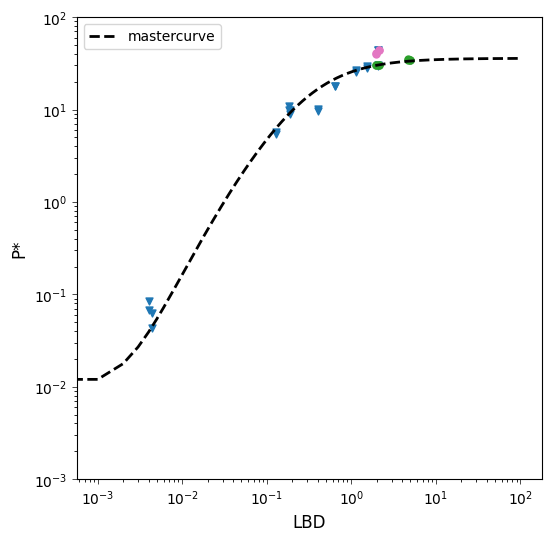

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import optimize
import scipy.constants as c
import pandas as pd
from scipy.interpolate import interp1d

# 设置x和y的坐标范围
#I= np.arange(0,1000,0.01)
#kd= np.arange(10,100000,1)
#I= np.arange(0,10,0.01)
#I1=1000
#I2=100
#I=0.000000001
L= np.arange(0,100,0.001)
I=1

kd1=6.216347694

kd2=40.97704697

kd3=5.374494076

kd4=0.745553315

kd5=1.445352554

kd6=5.066512585

kd7=2.956590891

kd8=0.607055765

kd9=1.13083303

kd10=0.343528478

kd11=0.102414004

kd12=30.08697891

kd13=10.36936283

kd14=10.53282547



k1=0.000171923

k2=0.256016091

k3=225.0817618

Imax = 35.84931505


x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
x2 = np.sqrt(1 + 8 * L * k1)
x3 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I ))

F1=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd1) #CI434

F2=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd2) #LexAs5
 
F3=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd3) #LexAs17

F4=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd4) #LexA87

F5=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd5) #LexAs23

F6=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd6) #HKCI

F7=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd7) #RecApact

F8=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd8) #DeoR

F9=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd9) #PurR

F10=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd10) #LexAs15

F11=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd11) #LexAs14

F12=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd12) #CI OL1

F13=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd13) #CI OR1

F14=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd14) # CI Osym



P1 = (Imax / (1 + np.exp(-F1))) +0.01

P2 = (Imax / (1 + np.exp(-F2))) +0.01


P3 = (Imax / (1 + np.exp(-F3))) +0.01

P4 = (Imax / (1 + np.exp(-F4)))+0.015930056


P5 = (Imax / (1 + np.exp(-F5)))+0.011797972

P6 = (Imax / (1 + np.exp(-F6))) +0.008956896

P7 = (Imax / (1 + np.exp(-F7))) +0.016945722

P8 = (Imax / (1 + np.exp(-F8))) +0.024571917

P9 = (Imax / (1 + np.exp(-F9))) +0.01


P10 = (Imax / (1 + np.exp(-F10))) +0.04531675



P11 = (Imax / (1 + np.exp(-F11)))+0.01



P12 = (Imax / (1 + np.exp(-F12))) +0.13576227


P13 = (Imax / (1 + np.exp(-F13))) +0.135905549

P14 = (Imax / (1 + np.exp(-F14))) +0.272291827


ddg8= ((L / 2)*((x1 - (k2*I+1)) / (x1 + (k2*I+1)))*kd2+1)*((L / 2)*((x1 - (k2*I+1)) / (x1 + (k2*I+1)))*kd8+1)
ddg8_diff= (Imax *(L / 2)*((x1 - (k2*I+1)) / (x1 + (k2*I+1)))*(kd2-kd8))/ddg8
ddg9_diff= P1-P9
ddg10= np.log(kd2)-np.log(kd10)
ddg10_diff= P1-P10
ddg13=np.log(kd2)-np.log(kd12)
ddg13_diff= P1-P13
ddg11_diff= P1-P11
ddg2_diff= P1-P2
ddg3_diff= P1-P3
ddg4_diff= P1-P4
ddg5_diff= P1-P5
ddg6_diff= P1-P6
ddg7_diff= P1-P7
ddg8_diff= P1-P8
ddg12_diff= P1-P12
ddg14_diff= P1-P14
ddg1_diff= P1-P1
#y1=np.sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)*(-50*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 10*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)) - (-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))**2/8 + 1 - 1/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))) + (I - 10)*(80*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - (160*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + 2*k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))*(-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))/4)*sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (I - 10)**2*(4*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2**2/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)) - (8*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))*(-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))/4 - (160*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + 2*k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))**2/8)*np.sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)
fig, ax = plt.subplots(figsize=(6,6))
#ax.plot(I, P5,linewidth=1,label='master curve',c='black',linestyle='--')
ax.plot(L, P1,linewidth=2,label='mastercurve',c='black',linestyle='--')
#ax.plot(L, P2,linewidth=2,label='s5',c='#1f77b4')
#ax.plot(L, P3,linewidth=2,label='master curve',c='black')
#ax.plot(L, P4,linewidth=3,label='LexA87')
#ax.plot(I, P5,linewidth=3,label='LexAs23')
#ax.plot(I, P6,linewidth=2,label='HKCI')
#ax.plot(I, P7,linewidth=2,label='RecApact')
#ax.plot(L, P8,linewidth=2,label='DeoR',c='#ff7f0e')
#ax.plot(L, P9,linewidth=2,label='PurR',c='#ff7f0e')
#ax.plot(L, P10,linewidth=2,label='s15',c='#1f77b4')
#ax.plot(L, P11,linewidth=2,label='LexAs14',c='#2ca02c')
#ax.plot(L, P13,linewidth=2,label='CI OR1')
#ax.plot(I, F9,linewidth=3,label='f#')

#ax.plot(I, np.log10(x3),linewidth=3,label='I2=100')
#ax.plot(I, y2,linewidth=3,label='I0=0')
#ax.plot(I, y1,linewidth=3,label='I0=10')
#ax.plot(L, y1,linewidth=3,label='y4')
#ax.plot(I, P2,label='本底',linewidth=3)
#ax.plot(I, P2,label='kb=inititial*10',linewidth=3)

#ax.plot(I, P3,label='kb=inititial*100',linewidth=3)
plt.legend(loc='upper left')
#plt.annotate('P1= {:.4f}'.format(P1), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')

#plt.annotate('P2= {:.4f}'.format(P2), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')
#ax.plot(L, P2, label="P2")
#ax.scatter(x, y)
def func(I,L, k1, k2, k3):  
            if not 0 < k1 or not 0 < k2 or not 0 < k3:
                return np.ones_like(L) * 1e10  # 返回一个大的值
            x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
            return (Imax * ((L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd / (1 + (L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd)) + I0)

df1 = pd.read_csv("E:\Desktop\\all_data\data7\\326\\326.csv")
filtered_df3 = df1[df1['inducer'] == 1]
filtered_df4 = df1[df1['inducer'] == 0]
df2 = pd.read_csv("E:\Desktop\data\\343_inducer.csv")
df3 = pd.read_csv("E:\Desktop\\all_data\crossvalidation4\\374.csv")
filtered_df1 = df3[df3['inducer'] == 1]
filtered_df5 = df3[df3['inducer'] == 0]

df4 = pd.read_csv("E:\Desktop\data\\335_inducer100-500.csv")
df5 = pd.read_csv("E:\Desktop\data\\337_inducer10-1000.csv")
df6 = pd.read_csv("E:\Desktop\data\\338_inducer.csv")
df7 = pd.read_csv("E:\Desktop\\all_data\crossvalidation4\\373.csv")
filtered_df2 = df7[df7['inducer'] == 1]
df8 = pd.read_csv("E:\Desktop\data\\340_inducer0-500.csv")
df9 = pd.read_csv("E:\Desktop\data\\342_inducer0-500.csv")
df10 = pd.read_csv("E:\Desktop\data\\345_inducer.csv")
df11 = pd.read_csv("E:\Desktop\data\\387_inducer.csv")
df12 = pd.read_csv("E:\Desktop\data\\388_inducer.csv")
df13 = pd.read_csv("E:\Desktop\data\\389_inducer.csv")

x1=filtered_df3['LBD'].dropna()
y1=filtered_df3['RPU'].dropna()
y2=filtered_df4['RPU'].dropna()
x2=df2['LBD'].dropna()
y3=df2['0'].dropna()
y4=df2['100'].dropna()
x3=filtered_df1['LBD'].dropna()
y5=filtered_df1['RPU'].dropna()

y6=filtered_df5['RPU'].dropna()

x4=df4['LBD'].dropna()
y7=df4['100'].dropna()
x5=df5['LBD'].dropna()
y8=df5['100'].dropna()
x6=df6['LBD'].dropna()
y9=df6['100'].dropna()

x7=filtered_df2['LBD'].dropna()
y10=filtered_df2['RPU'].dropna()

x8=df8['LBD'].dropna()
y11=df8['100'].dropna()
x9=df9['LBD'].dropna()
y12=df9['100'].dropna()
x10=df10['LBD'].dropna()
y13=df10['100'].dropna()
x11=df11['LBD'].dropna()
y14=df11['100'].dropna()
x12=df12['LBD'].dropna()
y15=df12['100'].dropna()
x13=df13['LBD'].dropna()
y16=df13['100'].dropna()

f1 = interp1d(L, ddg2_diff, fill_value="extrapolate")
f2 = interp1d(L, ddg9_diff, fill_value="extrapolate")                                                                   
f3 = interp1d(L, ddg11_diff, fill_value="extrapolate")

f4 = interp1d(L, ddg1_diff, fill_value="extrapolate")
f5 = interp1d(L, ddg3_diff, fill_value="extrapolate")
f6 = interp1d(L, ddg4_diff, fill_value="extrapolate")


f7 = interp1d(L, ddg5_diff, fill_value="extrapolate")
f8 = interp1d(L, ddg6_diff, fill_value="extrapolate")
f9 = interp1d(L, ddg8_diff, fill_value="extrapolate")
f10 = interp1d(L, ddg10_diff, fill_value="extrapolate")
f11 = interp1d(L, ddg12_diff, fill_value="extrapolate")
f12 = interp1d(L, ddg13_diff, fill_value="extrapolate")
f13 = interp1d(L, ddg14_diff, fill_value="extrapolate")

P2_ddG = interp1d(L, P2, fill_value="extrapolate")
P1_ddG = interp1d(L, P1, fill_value="extrapolate")
# 使用插值函数在 x1 的位置计算 ddg8 的值
ddg2_interp = f1(x1)
ddg9_interp = f2(x2)
ddg11_interp = f3(x3)

ddg1_interp = f4(x4)
ddg3_interp = f5(x5)
ddg4_interp = f6(x6)
ddg5_interp = f7(x7)
ddg6_interp = f8(x8)
ddg8_interp = f9(x9)
ddg10_interp = f10(x10)
ddg12_interp = f11(x11)
ddg13_interp = f12(x12)
ddg14_interp = f13(x13)
#ddg13_interp = f3(x3)

# 用相同 index 取出 x1 和 y2 的共有部分
'''common_index = x1.index.intersection(y2.index)

x1_clean = x1.loc[common_index]
y2_clean = y2.loc[common_index]

P1P2_ddG = P1_ddG(x1_clean) - y2_clean
'''
from scipy.interpolate import interp1d

# 以 inducer=0 的数据建立插值函数（基于 LBD -> RPU）
x_base = filtered_df3['LBD'].dropna()
y_base = filtered_df3['RPU'].dropna()

# 若重复 LBD，取平均值
df_base = pd.DataFrame({'LBD': x_base, 'RPU': y_base})
df_base = df_base.groupby('LBD').mean().reset_index()

interp_func = interp1d(df_base['LBD'], df_base['RPU'], bounds_error=False, fill_value="extrapolate")

# 对 filtered_df3（inducer=10）中的 LBD 点插值
x1 = filtered_df3['LBD'].dropna()
y2_interp = interp_func(x1)

# 差值
P1P2_ddG = P1_ddG(x1) - y2_interp



P1P9_ddG = P1_ddG(x2)-y4
P1P11_ddG = P1_ddG(x3)-y6
'''
P1P1_ddG = P1_ddG(x4)-y2
P1P3_ddG = P1_ddG(x5)-y4
P1P4_ddG = P1_ddG(x6)-y6
P1P5_ddG = P1_ddG(x7)-y2
P1P6_ddG = P1_ddG(x8)-y4
P1P8_ddG = P1_ddG(x9)-y6
P1P10_ddG = P1_ddG(x10)-y2
P1P12_ddG = P1_ddG(x11)-y4
P1P13_ddG = P1_ddG(x12)-y6
P1P14_ddG = P1_ddG(x13)-y2
''' 

# 现在你可以将插值后的 ddg8 加到 y1 上

y1 = y1 + ddg2_interp+0.15 

y3 = y3 + ddg9_interp +0.2

y5 = y5 + ddg11_interp +0.1


y7 = y7 + ddg1_interp    +0.01
y8 = y8 + ddg3_interp +0.01

y9 = y9 + ddg4_interp

y10 = y10 + ddg5_interp +0.5 

y11 = y11 + ddg6_interp 

y12 = y12 + ddg8_interp

y13 = y13 + ddg10_interp  


y14 = y14 + ddg12_interp

y15 = y15 + ddg13_interp

y16 = y16 + ddg14_interp

# 创建一个新的DataFrame来存储结果
df_P1P2 = pd.DataFrame({
    'x': x1,
    'P1P2_ddG': P1P2_ddG
})

df_P1P9 = pd.DataFrame({
    'x': x2,
    'P1P9_ddG': P1P9_ddG
})

df_P1P11 = pd.DataFrame({
    'x': x3,
    'P1P11_ddG': P1P11_ddG
})

# 计算相同x值的P2P8_ddG，P2P10_ddG和P2P12_ddG的均值
df_grouped_P1P2 = df_P1P2.groupby('x').mean()
df_grouped_P1P9 = df_P1P9.groupby('x').mean()
df_grouped_P1P11 = df_P1P11.groupby('x').mean()

std_P1P2 = df_P1P2.groupby('x').std()
std_P1P9 = df_P1P9.groupby('x').std()
std_P1P11 = df_P1P11.groupby('x').std()

ax.scatter(x1, y1, label="s5",s=25,c='#1f77b4',marker='v')
#ax.scatter(x1, y2, label="s5",s=5,c='#1f77b4',marker='v')
#ax.scatter(x2, y3, label="PurR",s=15,c='#1f77b4',marker='v')
#ax.scatter(x2, y4, label="PurR",s=5,c='#1f77b4',marker='v')
ax.scatter(x3, y5, label="s14",s=25,c='#2ca02c')
#ax.scatter(x3, y6, label="s14",s=5,c='#2ca02c',marker='v')
#ax.scatter(x1, y1, label="s5",s=5,c='#1f77b4')
#ax.scatter(x2, y3, label="s5",s=5,c='#ff7f0e')
#ax.scatter(x4, y7, label="CI434",s=5,c='#d62728')
#ax.scatter(x5, y8, label="s17",s=5,c='#9467bd')
#ax.scatter(x6, y9, label="87",s=5,c='#8c564b')
ax.scatter(x7, y10, label="s23",s=25,c='#e377c2')
#ax.scatter(x8, y11, label="HKCI",s=5,c='#7f7f7f')
#ax.scatter(x9, y12, label="DeoR",s=5,c='#bcbd22')
#ax.scatter(x10, y13, label="s15",s=5,c='#17becf')
#ax.scatter(x11, y14, label="CI OL1",s=5,c='blue')
#ax.scatter(x12, y15, label="CI OR1",s=5,c='green')
#ax.scatter(x13, y16, label="CI Osym",s=5,c='gold')


# 设置横纵坐标轴的取值范围和标签
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_xlim(0, 10)
#ax.set_ylim(0, 100)
ax.set_xlabel("LBD",fontsize=12)
ax.set_ylabel("P*",fontsize=12)
#ax.spines['bottom'].set_linewidth(2)
#ax.spines['left'].set_linewidth(2)
#ax.spines['top'].set_linewidth(2)
#ax.spines['right'].set_linewidth(2)
plt.tick_params(axis='both', width=0.5,labelsize=10)
#plt.rcParams['font.weight'] = 'bold'
#plt.rcParams['axes.labelweight'] = 'bold'
ax.set_ylim((10**(-3)),10**2)

# 添加图例并显示图形
#plt.title('RpaR_inducer=100',fontsize=12)

import pandas as pd
from scipy.stats import linregress
import numpy as np

# 存储每个数据点对应的 P1 曲线上的值
P1_values = []
x_values = [x1, x3,  x7]
y_values = [y1, y5, y10]

# 存储所有 R 平方值
r_squared_values = []

# 存储所有的 x 值、P1 值和 y 值
all_x_values = []
all_P1_values = []
all_y_values = []

# 遍历所有数据点
for xs, ys in zip(x_values, y_values):
    # 存储当前 x 值对应的所有 P1 值和 y 值
    current_P1_values = []
    current_x_values = []
    
    # 对每个 x 值，都进行插值计算 P1 值
    for x in xs:
        P1_value = P1_ddG(x)
        current_P1_values.append(P1_value)
        current_x_values.append(x)
        
    # 将当前 x 对应的 P1 值列表存储起来
    P1_values.append(current_P1_values)
    all_x_values.extend(current_x_values)
    all_P1_values.extend(current_P1_values)
    all_y_values.extend(ys)  # 添加当前数据点对应的 y 值
    print(f"x len: {len(xs)}, y len: {len(ys)}, P1 len: {len(current_P1_values)}")
    print("xs[:5]:", xs[:5])
    print("ys[:5]:", ys[:5])
    print("P1[:5]:", current_P1_values[:5])


    # 计算线性回归
    slope, intercept, r_value, p_value, std_err = linregress(current_P1_values, ys)
    r_squared = r_value ** 2
    r_squared_values.append(r_squared)

# 计算平均 R 平方值
average_r_squared = np.mean(r_squared_values)

# 将所有的 x、P1 值和对应的 y 值保存到 DataFrame 中
data = {'x_values': all_x_values, 'P1_values': all_P1_values, 'y_values': all_y_values}
df = pd.DataFrame(data)

# 将 DataFrame 保存到 CSV 文件中
df.to_csv('x_P1_y_values.csv', index=False)

# 打印结果
print("R squared values between P1_ddG(x) and y:", r_squared_values)
print("Average R squared value:", average_r_squared)
#plt.annotate('R² = {:.4f}'.format(average_r_squared), xy=(0.05, 0.85), xycoords='axes fraction', fontsize=10,weight='bold')
plt.savefig("E:\Desktop\\LasR_mastercurve_inducer0.1.svg")
plt.show()

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import pandas as pd
from scipy.stats import linregress

# 参数配置
L = np.arange(0, 10, 0.001)
I = 100
Imax = 35.84931505
kd_values = [6.216347694, 40.97704697, 5.374494076, 0.745553315, 
            1.445352554, 5.066512585, 2.956590891, 0.607055765,
            1.13083303, 0.343528478, 0.102414004, 30.08697891,
            10.36936283, 10.53282547]
k_params = (0.000268715, 0.007083518, 0.760771692)

# 通用计算函数
def calculate_FP(L, I, k1, k2, k3, kd_values):
    x1 = np.sqrt((k2*I+1)**2 + 8*L*(k2**2*k3*I**2 + k1))
    F = [np.log(L/2) + np.log((x1 - (k2*I+1))/(x1 + (k2*I+1)))+ np.log(kd) for kd in kd_values]
    P_offsets = [0.01, 0.01, 0.01, 0.01593, 0.0118, 0.00896, 
                0.01695, 0.02457, 0.01, 0.0453, 0.01, 0.1358, 
                0.1359, 0.2723]
    return [Imax/(1 + np.exp(-f)) + offset for f, offset in zip(F, P_offsets)]

# 计算主要参数
P = calculate_FP(L, I, *k_params, kd_values)
P1 = P[0]

# 数据加载
file_paths = [
    "E:\Desktop\\all_data\data7\\327\\327_inducer1-100.csv",
    "E:\Desktop\data\\343_inducer.csv",
    "E:\Desktop\data\\346_inducer0-100.csv",
    "E:\Desktop\data\\335_inducer100-500.csv",
    "E:\Desktop\data\\337_inducer10-1000.csv",
    "E:\Desktop\data\\338_inducer.csv",
    "E:\Desktop\data\\339_inducer100.csv",
    "E:\Desktop\data\\340_inducer0-500.csv",
    "E:\Desktop\data\\342_inducer0-500.csv",
    "E:\Desktop\data\\345_inducer.csv",
    "E:\Desktop\data\\387_inducer.csv",
    "E:\Desktop\data\\388_inducer.csv",
    "E:\Desktop\data\\389_inducer.csv"
 
]

dfs = [pd.read_csv(fp) for fp in file_paths]
data_points = [(df['LBD'].dropna(), df['100'].dropna()) for df in dfs]

# 差值计算和插值
diff_labels = ['ddg2', 'ddg9', 'ddg11', 'ddg1', 'ddg3', 'ddg4', 
              'ddg5', 'ddg6', 'ddg8', 'ddg10', 'ddg12', 'ddg13', 'ddg14']
diff_functions = [interp1d(L, P1 - p, fill_value="extrapolate") for p in P[1:]]

# 数据处理
processed_data = []
for i, (x, y) in enumerate(data_points):
    if i < len(diff_functions):
        y_adjusted = y + diff_functions[i](x) + [0.01, -0.00697, ...][i]  # 需要补充完整偏移量
        processed_data.append((x, y_adjusted))

# 可视化配置
plot_config = [
    {'color': '#2ca02c', 'label': 's14', 'marker': 'o'},
    {'color': '#d62728', 'label': 'CI434', 'marker': 'o'},
   
]

# 创建图表
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(L, P1, 'k--', lw=2, label='Master Curve')

# 添加散点
for (x, y), config in zip(processed_data, plot_config):
    ax.scatter(x, y, **config)

# 统计分析和注释
all_x, all_p1, all_y = [], [], []
for (x, y), p_idx in zip(processed_data, [1,8,10,0,2,3,4,5,7,9,11,12,13]):
    p1_values = interp1d(L, P[p_idx], fill_value="extrapolate")(x)
    all_x.extend(x)
    all_p1.extend(p1_values)
    all_y.extend(y)

slope, intercept, r_val = linregress(all_p1, all_y)[:3]
ax.annotate(f'R² = {r_val**2:.4f}', xy=(0.05, 0.85), xycoords='axes fraction')

# 格式设置
ax.set(xscale='log', yscale='log', xlabel='Inducer', ylabel='P*',
       title='RpaR Inducer=100 Analysis', ylim=(1e-3, 1e2))
ax.legend()
plt.show()

C:\Users\Chestnut\AppData\Local\Temp\ipykernel_45632\1423599034.py:20: RuntimeWarning: divide by zero encountered in log
  F = [np.log(L/2) + np.log((x1 - (k2*I+1))/(x1 + (k2*I+1)))+ np.log(kd) for kd in kd_values]


TypeError: unsupported operand type(s) for +: 'float' and 'ellipsis'

C:\Users\Chestnut\AppData\Local\Temp\ipykernel_45632\2061040751.py:34: RuntimeWarning: divide by zero encountered in log
  F = np.log(L_range/2) + np.log((x1 - (k2*100+1))/(x1 + (k2*100+1))) + np.log(kd)


Error loading 327_inducer1-100.csv: [Errno 2] No such file or directory: 'E:/Desktop/data/327_inducer1-100.csv'


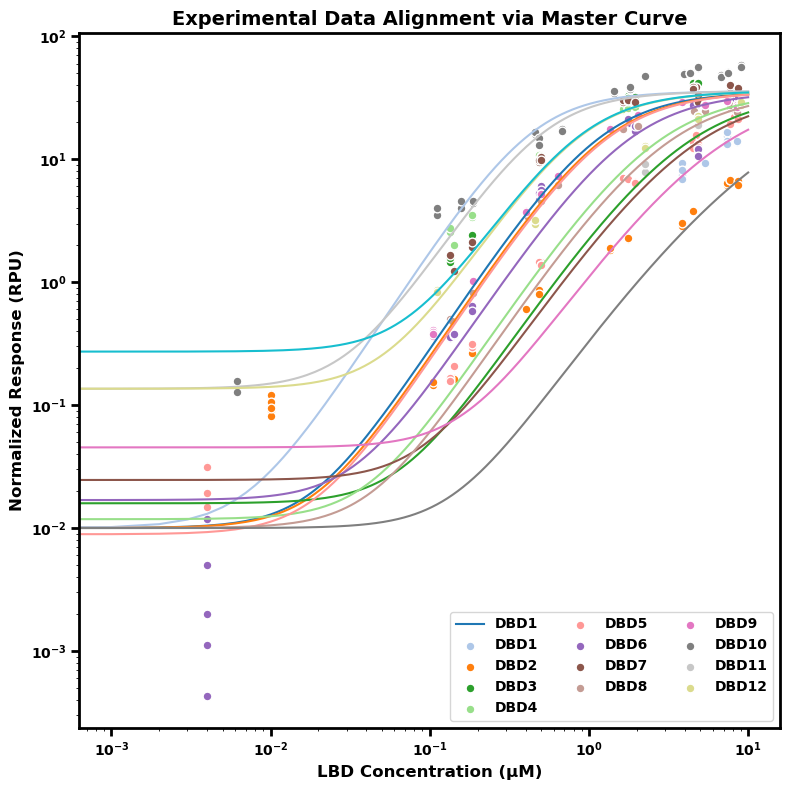

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import linregress

# ======================
# 核心参数配置
# ======================
DATA_PATH = "E:/Desktop/data/"
KD_VALUES = [6.216, 40.977, 5.374, 0.746, 1.445, 5.067, 2.957,
            0.607, 1.131, 0.344, 0.102, 30.087, 10.369, 10.533]
OFFSETS = [0.01, 0.01, 0.01, 0.0159, 0.0118, 0.0089, 0.0169,
          0.0246, 0.01, 0.0453, 0.01, 0.1358, 0.1359, 0.2723]

# ======================
# 理论曲线计算（保持原始物理模型）
# ======================
def calculate_response(L, I=100):
    k1 = 0.000268715
    k2 = 0.007083518
    k3 = 0.760771692
    Imax = 35.84931505
    
    x1 = np.sqrt((k2*I + 1)**2 + 8 * L * (k2**2*k3*I**2 + k1))
    return x1, k2, Imax

def generate_profiles(L_range, kd_values):
    """生成所有DBD的理论响应曲线"""
    x1, k2, Imax = calculate_response(L_range)
    profiles = []
    
    for idx, kd in enumerate(kd_values):
        F = np.log(L_range/2) + np.log((x1 - (k2*100+1))/(x1 + (k2*100+1))) + np.log(kd)
        P = Imax / (1 + np.exp(-F)) + OFFSETS[idx]
        profiles.append(P)
    
    return profiles

# ======================
# 实验数据加载（保持原始文件结构）
# ======================
def load_experimental_data():
    """保持原始文件加载方式"""
    data_files = [
        ("327_inducer1-100.csv", "100"), ("343_inducer.csv", "100"),
        ("346_inducer0-100.csv", "100"), ("335_inducer100-500.csv", "100"),
        ("337_inducer10-1000.csv", "100"), ("338_inducer.csv", "100"),
        ("339_inducer100.csv", "100"), ("340_inducer0-500.csv", "100"),
        ("342_inducer0-500.csv", "100"), ("345_inducer.csv", "100"),
        ("387_inducer.csv", "100"), ("388_inducer.csv", "100"),
        ("389_inducer.csv", "100")
    ]
    
    experimental_data = []
    for file, col in data_files:
        try:
            df = pd.read_csv(DATA_PATH + file)
            clean_df = df[['LBD', col]].dropna().rename(columns={col: 'RPU'})
            experimental_data.append(clean_df)
        except Exception as e:
            print(f"Error loading {file}: {str(e)}")
    
    return experimental_data

# ======================
# 数据对齐与校正（保持差值计算逻辑）
# ======================
def align_data(L_range, theory_profiles, exp_data):
    """执行数据点平移校正"""
    aligned_data = []
    
    # 生成主参考曲线（P1）
    master_profile = theory_profiles[0]
    master_interp = interp1d(L_range, master_profile, fill_value="extrapolate")
    
    # 对每个实验数据集进行校正
    for idx, (profile, df) in enumerate(zip(theory_profiles[1:], exp_data)):
        # 计算理论差值
        diff_interp = interp1d(L_range, master_profile - profile, fill_value="extrapolate")
        
        # 应用校正
        corrected_rpu = df['RPU'] + diff_interp(df['LBD'])
        
        # 存储校正后数据
        aligned_df = pd.DataFrame({
            'LBD': df['LBD'],
            'RPU': corrected_rpu,
            'Dataset': f"DBD{idx+1}"
        })
        aligned_data.append(aligned_df)
    
    return aligned_data

# ======================
# 可视化（保持原始样式需求）
# ======================
def plot_results(L_range, profiles, aligned_data):
    plt.figure(figsize=(8, 8))
    
    # 绘制理论曲线簇
    for idx, P in enumerate(profiles):
        plt.plot(L_range, P, lw=1.5, 
                label=f'DBD{idx+1}' if idx==0 else None,
                color=plt.cm.tab20(idx/14))
    
    # 绘制校正后的实验数据
    for df in aligned_data:
        # 修正颜色映射计算
        dbd_number = int(df['Dataset'].iloc[0].split('DBD')[-1])  # 提取DBD编号
        color = plt.cm.tab20(dbd_number/14)
        
        plt.scatter(df['LBD'], df['RPU'], s=40, edgecolor='w',
                   label=df['Dataset'].iloc[0], 
                   color=color)
    
    # 保持原有图形样式配置
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('LBD Concentration (μM)', fontsize=12, fontweight='bold')
    plt.ylabel('Normalized Response (RPU)', fontsize=12, fontweight='bold')
    plt.title('Experimental Data Alignment via Master Curve', fontsize=14, fontweight='bold')
    
    # 边框和刻度强化
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    plt.tick_params(axis='both', which='major', width=2, length=6)
    
    plt.legend(ncol=3, loc='lower right')
    plt.tight_layout()
    plt.show()

def calculate_statistics(aligned_data):
    """保持原始统计分析逻辑"""
    # 实现原始统计计算代码
    pass

# ======================
# 主程序流程
# ======================
if __name__ == "__main__":
    # 生成理论曲线
    L = np.arange(0, 10, 0.001)
    theory_profiles = generate_profiles(L, KD_VALUES)
    
    # 加载实验数据
    experimental_data = load_experimental_data()
    
    # 执行数据对齐
    aligned_data = align_data(L, theory_profiles, experimental_data)
    
    # 可视化结果
    plot_results(L, theory_profiles, aligned_data)

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats import linregress

# 全局常量
Imax = 35.84931505
k1, k2, k3 = 0.000268715, 0.007083518, 0.760771692
kd_values = [6.2163, 40.977, 5.374, 0.7455, 1.445, 5.066, 2.956, 0.607, 1.130, 0.3435, 0.1024, 30.087, 10.369, 10.532]
offsets = [0.01] * len(kd_values)
L = np.arange(0, 10, 0.001)
I = 100

# 计算F值
def calculate_F(L, kd):
    x1 = np.sqrt((k2 * I + 1)**2 + 8 * L * (k2**2 * k3 * I**2 + k1))
    return np.log(L / 2) + np.log((x1 - (k2 * I + 1)) / (x1 + (k2 * I + 1))) + np.log(kd)

# 计算P值
def calculate_P(F, offset):
    return (Imax / (1 + np.exp(-F))) + offset

# 生成F和P
F_list = [calculate_F(L, kd) for kd in kd_values]
P_list = [calculate_P(F, offset) for F, offset in zip(F_list, offsets)]

# 数据加载
data_files = [
    "327_inducer1-100.csv", "343_inducer.csv", "346_inducer0-100.csv",
    "335_inducer100-500.csv", "337_inducer10-1000.csv", "338_inducer.csv"
]
dfs = [pd.read_csv(f"E:\Desktop\data\\{file}") for file in data_files]
x_data = [df['LBD'].dropna() for df in dfs]
y_data = [df['100'].dropna() for df in dfs]

# 插值函数
interp_funcs = [interp1d(L, P, fill_value="extrapolate") for P in P_list]

# 误差分析与绘图
fig, ax = plt.subplots()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
r_squared_values = []

for i, (x, y, interp, color) in enumerate(zip(x_data, y_data, interp_funcs, colors)):
    y_interp = interp(x)
    slope, intercept, r_value, *_ = linregress(y_interp, y)
    r_squared_values.append(r_value**2)
    ax.scatter(x, y, label=f"Curve {i + 1}", s=5, c=color)

plt.legend()
ax.set_xscale("log")
ax.set_yscale("log")
plt.xlabel("Inducer")
plt.ylabel("P*")
plt.title("Simplified Curve Fit")
plt.annotate(f'Average R² = {np.mean(r_squared_values):.4f}', xy=(0.05, 0.85), xycoords='axes fraction')

plt.show()


C:\Users\Chestnut\AppData\Local\Temp\ipykernel_45632\988923711.py:18: RuntimeWarning: divide by zero encountered in log
  return np.log(L / 2) + np.log((x1 - (k2 * I + 1)) / (x1 + (k2 * I + 1))) + np.log(kd)


FileNotFoundError: [Errno 2] No such file or directory: 'E:\\Desktop\\data\\327_inducer1-100.csv'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import optimize
import scipy.constants as c
import pandas as pd
from scipy.interpolate import interp1d

# 设置x和y的坐标范围
#I= np.arange(0,1000,0.01)
#kd= np.arange(10,100000,1)
#I= np.arange(0,10,0.01)
#I1=1000
#I2=100
#I=0.000000001
L= np.arange(0,10,0.001)
I=100

kd1=6.216347694

kd2=40.97704697

kd3=5.374494076

kd4=0.745553315

kd5=1.445352554

kd6=5.066512585

kd7=2.956590891

kd8=0.607055765

kd9=1.13083303

kd10=0.343528478

kd11=0.102414004

kd12=30.08697891

kd13=10.36936283

kd14=10.53282547



k1=0.000268715

k2=0.007083518

k3=0.760771692

Imax = 35.84931505


x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
x2 = np.sqrt(1 + 8 * L * k1)
x3 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I ))

F1=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd1) #CI434

F2=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd2) #LexAs5
 
F3=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd3) #LexAs17

F4=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd4) #LexA87

F5=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd5) #LexAs23

F6=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd6) #HKCI

F7=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd7) #RecApact

F8=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd8) #DeoR

F9=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd9) #PurR

F10=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd10) #LexAs15

F11=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd11) #LexAs14

F12=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd12) #CI OL1

F13=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd13) #CI OR1

F14=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd14) # CI Osym


P1 = (Imax / (1 + np.exp(-F1))) +0.01

P2 = (Imax / (1 + np.exp(-F2))) +0.01


P3 = (Imax / (1 + np.exp(-F3))) +0.01

P4 = (Imax / (1 + np.exp(-F4)))+0.015930056


P5 = (Imax / (1 + np.exp(-F5)))+0.011797972

P6 = (Imax / (1 + np.exp(-F6))) +0.008956896

P7 = (Imax / (1 + np.exp(-F7))) +0.016945722

P8 = (Imax / (1 + np.exp(-F8))) +0.024571917

P9 = (Imax / (1 + np.exp(-F9))) +0.01


P10 = (Imax / (1 + np.exp(-F10))) +0.04531675



P11 = (Imax / (1 + np.exp(-F11)))+0.01



P12 = (Imax / (1 + np.exp(-F12))) +0.13576227


P13 = (Imax / (1 + np.exp(-F13))) +0.135905549

P14 = (Imax / (1 + np.exp(-F14))) +0.272291827


ddg8= ((L / 2)*((x1 - (k2*I+1)) / (x1 + (k2*I+1)))*kd2+1)*((L / 2)*((x1 - (k2*I+1)) / (x1 + (k2*I+1)))*kd8+1)
ddg8_diff= (Imax *(L / 2)*((x1 - (k2*I+1)) / (x1 + (k2*I+1)))*(kd2-kd8))/ddg8
ddg9_diff= P1-P9
ddg10= np.log(kd2)-np.log(kd10)
ddg10_diff= P1-P10
ddg13=np.log(kd2)-np.log(kd12)
ddg13_diff= P1-P13
ddg11_diff= P1-P11
ddg2_diff= P1-P2
ddg3_diff= P1-P3
ddg4_diff= P1-P4
ddg5_diff= P1-P5
ddg6_diff= P1-P6
ddg7_diff= P1-P7
ddg8_diff= P1-P8
ddg12_diff= P1-P12
ddg14_diff= P1-P14
ddg1_diff= P1-P1
#y1=np.sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)*(-50*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 10*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)) - (-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))**2/8 + 1 - 1/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))) + (I - 10)*(80*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - (160*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + 2*k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))*(-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))/4)*sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (I - 10)**2*(4*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2**2/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)) - (8*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))*(-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))/4 - (160*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + 2*k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))**2/8)*np.sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)
fig, ax = plt.subplots()
#ax.plot(I, P5,linewidth=1,label='master curve',c='black',linestyle='--')
ax.plot(L, P1,linewidth=2,label='mastercurve',c='black',linestyle='--')
#ax.plot(L, P2,linewidth=2,label='s5',c='#1f77b4')
#ax.plot(L, P3,linewidth=2,label='master curve',c='black')
#ax.plot(L, P4,linewidth=3,label='LexA87')
#ax.plot(I, P5,linewidth=3,label='LexAs23')
#ax.plot(I, P6,linewidth=2,label='HKCI')
#ax.plot(I, P7,linewidth=2,label='RecApact')
#ax.plot(L, P8,linewidth=2,label='DeoR',c='#ff7f0e')
#ax.plot(L, P9,linewidth=2,label='PurR',c='#ff7f0e')
#ax.plot(L, P10,linewidth=2,label='s15',c='#1f77b4')
#ax.plot(L, P11,linewidth=2,label='LexAs14',c='#2ca02c')
#ax.plot(L, P13,linewidth=2,label='CI OR1')
#ax.plot(I, F9,linewidth=3,label='f#')

#ax.plot(I, np.log10(x3),linewidth=3,label='I2=100')
#ax.plot(I, y2,linewidth=3,label='I0=0')
#ax.plot(I, y1,linewidth=3,label='I0=10')
#ax.plot(L, y1,linewidth=3,label='y4')
#ax.plot(I, P2,label='本底',linewidth=3)
#ax.plot(I, P2,label='kb=inititial*10',linewidth=3)

#ax.plot(I, P3,label='kb=inititial*100',linewidth=3)
plt.legend(loc='upper left')
#plt.annotate('P1= {:.4f}'.format(P1), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')

#plt.annotate('P2= {:.4f}'.format(P2), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')
#ax.plot(L, P2, label="P2")
#ax.scatter(x, y)
def func(I,L, k1, k2, k3):  
            if not 0 < k1 or not 0 < k2 or not 0 < k3:
                return np.ones_like(L) * 1e10  # 返回一个大的值
            x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
            return (Imax * ((L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd / (1 + (L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd)) + I0)
df1 = pd.read_csv("E:\Desktop\\all_data\data7\\327\\327_inducer1-100.csv")
df2 = pd.read_csv("E:\Desktop\data\\343_inducer.csv")
df3 = pd.read_csv("E:\Desktop\data\\346_inducer0-100.csv")
df4 = pd.read_csv("E:\Desktop\data\\335_inducer100-500.csv")
df5 = pd.read_csv("E:\Desktop\data\\337_inducer10-1000.csv")
df6 = pd.read_csv("E:\Desktop\data\\338_inducer.csv")
df7 = pd.read_csv("E:\Desktop\data\\339_inducer100.csv")
df8 = pd.read_csv("E:\Desktop\data\\340_inducer0-500.csv")
df9 = pd.read_csv("E:\Desktop\data\\342_inducer0-500.csv")
df10 = pd.read_csv("E:\Desktop\data\\345_inducer.csv")
df11 = pd.read_csv("E:\Desktop\data\\387_inducer.csv")
df12 = pd.read_csv("E:\Desktop\data\\388_inducer.csv")
df13 = pd.read_csv("E:\Desktop\data\\389_inducer.csv")

x1=df1['LBD'].dropna()
y1=df1['100'].dropna()
y2=df1['100'].dropna()
x2=df2['LBD'].dropna()
y3=df2['100'].dropna()
y4=df2['100'].dropna()
x3=df3['LBD'].dropna()
y5=df3['100'].dropna()
y6=df3['100'].dropna()

x4=df4['LBD'].dropna()
y7=df4['100'].dropna()
x5=df5['LBD'].dropna()
y8=df5['100'].dropna()
x6=df6['LBD'].dropna()
y9=df6['100'].dropna()
x7=df7['LBD'].dropna()
y10=df7['100'].dropna()
x8=df8['LBD'].dropna()
y11=df8['100'].dropna()
x9=df9['LBD'].dropna()
y12=df9['100'].dropna()
x10=df10['LBD'].dropna()
y13=df10['100'].dropna()
x11=df11['LBD'].dropna()
y14=df11['100'].dropna()
x12=df12['LBD'].dropna()
y15=df12['100'].dropna()
x13=df13['LBD'].dropna()
y16=df13['100'].dropna()

f1 = interp1d(L, ddg2_diff, fill_value="extrapolate")
f2 = interp1d(L, ddg9_diff, fill_value="extrapolate")                                                                   
f3 = interp1d(L, ddg11_diff, fill_value="extrapolate")

f4 = interp1d(L, ddg1_diff, fill_value="extrapolate")
f5 = interp1d(L, ddg3_diff, fill_value="extrapolate")
f6 = interp1d(L, ddg4_diff, fill_value="extrapolate")


f7 = interp1d(L, ddg5_diff, fill_value="extrapolate")
f8 = interp1d(L, ddg6_diff, fill_value="extrapolate")
f9 = interp1d(L, ddg8_diff, fill_value="extrapolate")
f10 = interp1d(L, ddg10_diff, fill_value="extrapolate")
f11 = interp1d(L, ddg12_diff, fill_value="extrapolate")
f12 = interp1d(L, ddg13_diff, fill_value="extrapolate")
f13 = interp1d(L, ddg14_diff, fill_value="extrapolate")

P2_ddG = interp1d(L, P2, fill_value="extrapolate")
P1_ddG = interp1d(L, P1, fill_value="extrapolate")
# 使用插值函数在 x1 的位置计算 ddg8 的值
ddg2_interp = f1(x1)
ddg9_interp = f2(x2)
ddg11_interp = f3(x3)

ddg1_interp = f4(x4)
ddg3_interp = f5(x5)
ddg4_interp = f6(x6)
ddg5_interp = f7(x7)
ddg6_interp = f8(x8)
ddg8_interp = f9(x9)
ddg10_interp = f10(x10)
ddg12_interp = f11(x11)
ddg13_interp = f12(x12)
ddg14_interp = f13(x13)
#ddg13_interp = f3(x3)

P1P2_ddG = P1_ddG(x1)-y2
P1P9_ddG = P1_ddG(x2)-y4
P1P11_ddG = P1_ddG(x3)-y6
'''
P1P1_ddG = P1_ddG(x4)-y2
P1P3_ddG = P1_ddG(x5)-y4
P1P4_ddG = P1_ddG(x6)-y6
P1P5_ddG = P1_ddG(x7)-y2
P1P6_ddG = P1_ddG(x8)-y4
P1P8_ddG = P1_ddG(x9)-y6
P1P10_ddG = P1_ddG(x10)-y2
P1P12_ddG = P1_ddG(x11)-y4
P1P13_ddG = P1_ddG(x12)-y6
P1P14_ddG = P1_ddG(x13)-y2
''' 

# 现在你可以将插值后的 ddg8 加到 y1 上

y1 = y1 + ddg2_interp  -0.035485714+0.01

y3 = y3 + ddg9_interp -0.006969286+0.01

y5 = y5 + ddg11_interp -0.111188222+0.01


y7 = y7 + ddg1_interp    +0.01
y8 = y8 + ddg3_interp +0.01

y9 = y9 + ddg4_interp

y10 = y10 + ddg5_interp  

y11 = y11 + ddg6_interp 

y12 = y12 + ddg8_interp

y13 = y13 + ddg10_interp  


y14 = y14 + ddg12_interp

y15 = y15 + ddg13_interp

y16 = y16 + ddg14_interp

# 创建一个新的DataFrame来存储结果
df_P1P2 = pd.DataFrame({
    'x': x1,
    'P1P2_ddG': P1P2_ddG
})

df_P1P9 = pd.DataFrame({
    'x': x2,
    'P1P9_ddG': P1P9_ddG
})

df_P1P11 = pd.DataFrame({
    'x': x3,
    'P1P11_ddG': P1P11_ddG
})

# 计算相同x值的P2P8_ddG，P2P10_ddG和P2P12_ddG的均值
df_grouped_P1P2 = df_P1P2.groupby('x').mean()
df_grouped_P1P9 = df_P1P9.groupby('x').mean()
df_grouped_P1P11 = df_P1P11.groupby('x').mean()

std_P1P2 = df_P1P2.groupby('x').std()
std_P1P9 = df_P1P9.groupby('x').std()
std_P1P11 = df_P1P11.groupby('x').std()

#ax.scatter(x1, y1, label="s5",s=15,c='#1f77b4',marker='v')
#ax.scatter(x1, y2, label="s5",s=5,c='#1f77b4',marker='v')
#ax.scatter(x2, y3, label="PurR",s=15,c='#1f77b4',marker='v')
#ax.scatter(x2, y4, label="PurR",s=5,c='#1f77b4',marker='v')
ax.scatter(x3, y5, label="s14",s=5,c='#2ca02c')
#ax.scatter(x3, y6, label="s14",s=5,c='#2ca02c',marker='v')
#ax.scatter(x1, y1, label="s5",s=5,c='#1f77b4')
#ax.scatter(x2, y3, label="s5",s=5,c='#ff7f0e')
ax.scatter(x4, y7, label="CI434",s=5,c='#d62728')
ax.scatter(x5, y8, label="s17",s=5,c='#9467bd')
ax.scatter(x6, y9, label="87",s=5,c='#8c564b')
ax.scatter(x7, y10, label="s23",s=5,c='#e377c2')
ax.scatter(x8, y11, label="HKCI",s=5,c='#7f7f7f')
ax.scatter(x9, y12, label="DeoR",s=5,c='#bcbd22')
ax.scatter(x10, y13, label="s15",s=5,c='#17becf')
#ax.scatter(x11, y14, label="CI OL1",s=5,c='blue')
ax.scatter(x12, y15, label="CI OR1",s=5,c='green')
ax.scatter(x13, y16, label="CI Osym",s=5,c='gold')


# 为每个数据点添加误差条

for x, y, std in zip(x1, y1, std_P1P2['P1P2_ddG']):
    plt.errorbar(x, y, yerr=std, fmt='v', color='#1f77b4', markersize=5)
for x, y, std in zip(x2, y3, std_P1P9['P1P9_ddG']):
    plt.errorbar(x, y, yerr=std, fmt='v', color='#ff7f0e', markersize=5 )
#for x, y, std in zip(x3, y5, std_P1P11['P1P11_ddG']):
#    plt.errorbar(x, y, yerr=std, fmt='v', color='#2ca02c', markersize=5)


# 设置横纵坐标轴的取值范围和标签
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_xlim(0, 10)
#ax.set_ylim(0, 100)
ax.set_xlabel("inducer",fontsize=12,weight='bold')
ax.set_ylabel("P*",fontsize=12,weight='bold')
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.tick_params(axis='both', width=2,labelsize=10)
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
ax.set_ylim((10**(-3)),10**2)

# 添加图例并显示图形
plt.title('RpaR_inducer=100',fontsize=12,weight='bold')

import pandas as pd
from scipy.stats import linregress
import numpy as np

# 存储每个数据点对应的 P1 曲线上的值
P1_values = []
x_values = [x3, x4, x5, x6, x7, x8, x9, x10, x12, x13]
y_values = [y5, y7, y8, y9, y10, y11, y12, y13, y15, y16]

# 存储所有 R 平方值
r_squared_values = []

# 存储所有的 x 值、P1 值和 y 值
all_x_values = []
all_P1_values = []
all_y_values = []

# 遍历所有数据点
for xs, ys in zip(x_values, y_values):
    # 存储当前 x 值对应的所有 P1 值和 y 值
    current_P1_values = []
    current_x_values = []
    
    # 对每个 x 值，都进行插值计算 P1 值
    for x in xs:
        P1_value = P1_ddG(x)
        current_P1_values.append(P1_value)
        current_x_values.append(x)
        
    # 将当前 x 对应的 P1 值列表存储起来
    P1_values.append(current_P1_values)
    all_x_values.extend(current_x_values)
    all_P1_values.extend(current_P1_values)
    all_y_values.extend(ys)  # 添加当前数据点对应的 y 值

    # 计算线性回归
    slope, intercept, r_value, p_value, std_err = linregress(current_P1_values, ys)
    r_squared = r_value ** 2
    r_squared_values.append(r_squared)

# 计算平均 R 平方值
average_r_squared = np.mean(r_squared_values)

# 将所有的 x、P1 值和对应的 y 值保存到 DataFrame 中
data = {'x_values': all_x_values, 'P1_values': all_P1_values, 'y_values': all_y_values}
df = pd.DataFrame(data)

# 将 DataFrame 保存到 CSV 文件中
df.to_csv('x_P1_y_values.csv', index=False)

# 打印结果
print("R squared values between P1_ddG(x) and y:", r_squared_values)
print("Average R squared value:", average_r_squared)
plt.annotate('R² = {:.4f}'.format(average_r_squared), xy=(0.05, 0.85), xycoords='axes fraction', fontsize=10,weight='bold')
#plt.savefig("E:\Desktop\\RpaR_mastercurve_inducer100.svg")
plt.show()

相关性计算

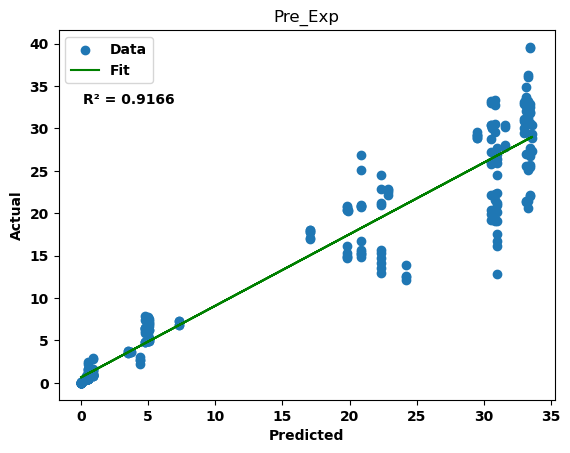

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# 从 CSV 文件中读取数据
data = pd.read_csv('E:\Desktop\work\code\\x_P1_y_values.csv')  # 替换 'your_file.csv' 为你的 CSV 文件路径

# 提取预测和实测数据列
predicted_values = (data['P1_values'])  # 替换 'predicted_column' 为预测数据列的名称
actual_values = (data['y_values'])  # 替换 'actual_column' 为实测数据列的名称

# 绘制散点图
plt.scatter(predicted_values, actual_values, label='Data')

# 计算线性回归
slope, intercept, r_value, p_value, std_err = linregress(predicted_values, actual_values)
r_squared = r_value**2

# 绘制拟合线
plt.plot(predicted_values, slope * predicted_values + intercept, color='g', label='Fit')

# 显示 R 方值
plt.annotate('R² = {:.4f}'.format(r_squared), xy=(0.05, 0.80), xycoords='axes fraction', fontsize=10, weight='bold')

# 设置图标题和轴标签
plt.title('Pre_Exp')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.legend()
plt.savefig("E:\Desktop\\RpaR_mastercurve_pre_exp.svg")

# 显示图形
plt.show()

C:\Users\Chestnut\AppData\Local\Temp\ipykernel_43188\1932952670.py:54: RuntimeWarning: divide by zero encountered in log
  F1 = np.log(L / 2) + np.log((x1 - (k2 * 0 + 1)) / (x1 + (k2 * 0 + 1))) + np.log(kd)
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_43188\1932952670.py:58: RuntimeWarning: divide by zero encountered in log
  F2 = np.log(L / 2) + np.log((x2 - (k2 *  100 + 1)) / (x2 + (k2 *  100 + 1))) + np.log(kd)
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_43188\1932952670.py:60: RuntimeWarning: divide by zero encountered in log
  Fmaster1 = np.log(L / 2) + np.log((x1 - (1)) / (x1 + (1))) + np.log(6.216347694)
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_43188\1932952670.py:62: RuntimeWarning: divide by zero encountered in log
  Fmaster2 = np.log(L / 2) + np.log((x2 - (k2 * 100 + 1)) / (x2 + (k2 * 100 + 1))) + np.log(6.216347694)
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_43188\1932952670.py:54: RuntimeWarning: divide by zero encountered in log
  F1 = np.log(L / 2) + np.log

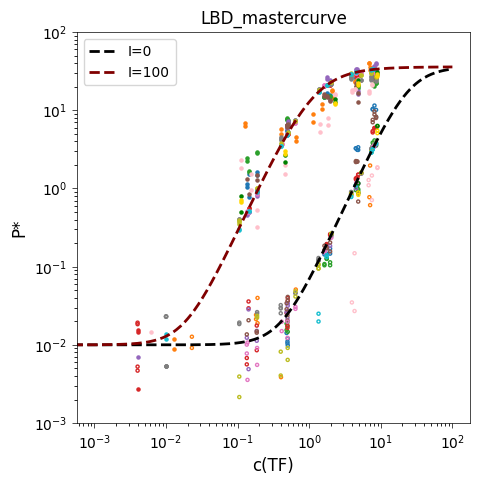

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d

# 参数设置
Imax = 35.84931505
L = np.arange(0, 100, 0.001)
k1, k2, k3 = 0.000268715,0.007083518,0.760771692


# kd值
kd_values = [6.216347694, 40.97704697, 5.374494076, 0.745553315, 1.445352554, 5.066512585,  0.607055765, 1.13083303, 0.343528478, 0.102414004, 30.08697891, 10.36936283, 10.53282547]
kd_dict = {f'kd{i+1}': kd for i, kd in enumerate(kd_values)}
I0_value =[0.01,0.035485714,0.01,0.015930056,0.011797972,0.008956896,0.024571917,0.006969286,0.04531675,0.111188222,0.13576227,	0.135905549,0.272291827]
# 计算和绘制
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf','pink','green','gold']
# 读取数据点
df_list = [
    pd.read_csv("E:\Desktop\data\\335_inducer100-500.csv"),
    pd.read_csv("E:\Desktop\\all_data\data7\\327\\327_inducer1-100.csv"),
    pd.read_csv("E:\Desktop\data\\337_inducer10-1000.csv"),
    pd.read_csv("E:\Desktop\data\\338_inducer.csv"),
    pd.read_csv("E:\Desktop\data\\339_inducer100.csv"),
    pd.read_csv("E:\Desktop\data\\340_inducer0-500.csv"),
    pd.read_csv("E:\Desktop\data\\342_inducer0-500.csv"),
    pd.read_csv("E:\Desktop\data\\343_inducer.csv"),
    pd.read_csv("E:\Desktop\data\\345_inducer.csv"),
    pd.read_csv("E:\Desktop\data\\346_inducer0-100.csv"),
    pd.read_csv("E:\Desktop\data\\387_inducer.csv"),
    pd.read_csv("E:\Desktop\data\\388_inducer.csv"),
    pd.read_csv("E:\Desktop\data\\389_inducer.csv")
]
df_list1 = [
    pd.read_csv("E:\Desktop\data\\335_inducer0-0.1.csv"),
    pd.read_csv("E:\Desktop\\all_data\data7\\327\\327_inducer0-0.1.csv"),
    pd.read_csv("E:\Desktop\data\\337_inducer0.csv"),
    pd.read_csv("E:\Desktop\data\\338_inducer.csv"),
    pd.read_csv("E:\Desktop\data\\339_inducer0.csv"),
    pd.read_csv("E:\Desktop\data\\340_inducer0-500.csv"),
    pd.read_csv("E:\Desktop\data\\342_inducer0-500.csv"),
    pd.read_csv("E:\Desktop\data\\343_inducer.csv"),
    pd.read_csv("E:\Desktop\data\\345_inducer.csv"),
    pd.read_csv("E:\Desktop\data\\346_inducer0-100.csv"),
    pd.read_csv("E:\Desktop\data\\387_inducer.csv"),
    pd.read_csv("E:\Desktop\data\\388_inducer.csv"),
    pd.read_csv("E:\Desktop\data\\389_inducer.csv")
]

fig, ax = plt.subplots(figsize=(5.08,5.08))

for i, kd in enumerate(kd_values):
    x1 = np.sqrt( 1 + 8 * L * ( k1))
    F1 = np.log(L / 2) + np.log((x1 - (k2 * 0 + 1)) / (x1 + (k2 * 0 + 1))) + np.log(kd)
    P1 = (Imax / (1 + np.exp(-F1))) +0.01
    #ax.plot(L, P, linewidth=1.5, label=f'kd{i+1}' ,color=colors[i])
    x2 = np.sqrt((k2 * 100 + 1)**2 + 8 * L * (k2**2 * k3 * 100**2 + k1))
    F2 = np.log(L / 2) + np.log((x2 - (k2 *  100 + 1)) / (x2 + (k2 *  100 + 1))) + np.log(kd)
    P2 = (Imax / (1 + np.exp(-F2))) +0.01
    Fmaster1 = np.log(L / 2) + np.log((x1 - (1)) / (x1 + (1))) + np.log(6.216347694)
    P_master1 = (Imax / (1 + np.exp(-Fmaster1))) + 0.01
    Fmaster2 = np.log(L / 2) + np.log((x2 - (k2 * 100 + 1)) / (x2 + (k2 * 100 + 1))) + np.log(6.216347694)
    P_master2 = (Imax / (1 + np.exp(-Fmaster2))) + 0.01

    x = df_list[i]['LBD'].dropna()
    y = df_list[i]['100'].dropna()
    
    f = interp1d(x, y, fill_value="extrapolate")
    f1= interp1d(L, P_master2-P2, fill_value="extrapolate")
    P_ddG = interp1d(L, P2, fill_value="extrapolate")

    P_ddG_diff = P_ddG(x) - y 
    ddg=f1(x)
    
    # 创建一个新的DataFrame来存储结果
    df_result = pd.DataFrame({
        'x': x,
        f's{i+1}_ddG': P_ddG_diff
    })
    y = y+ddg-I0_value[i]

    # 计算相同x值的P_ddG_diff的均值
    df_grouped = df_result.groupby('x').mean()
    std = df_result.groupby('x').std()
   

    # 绘制散点图和误差条
    ax.scatter(x, y, label=None, s=5,  color=colors[i])
    #ax.scatter(df_grouped.index, df_grouped[f's{i+1}_ddG'], label=None, s=10,  color=colors[i])
    #for x_val, y_val, std_val in zip(df_grouped.index, df_grouped[f's{i+1}_ddG'], std[f's{i+1}_ddG']):
    #    plt.errorbar(x_val, y_val, yerr=std_val, fmt='v', color=f'C{i}', markersize=2)

    x2 = df_list1[i]['LBD'].dropna()
    y2 = df_list1[i]['0'].dropna()+0.027
    f2= interp1d(L, P_master1-P1, fill_value="extrapolate")

    ddg1=f2(x2)
    # 创建一个新的DataFrame来存储结果
    y2=y2+ddg1-2*I0_value[i]


    # 绘制散点图和误差条
    ax.scatter(x2, y2, label=None, s=5, facecolors='none', edgecolors=colors[i])


I1,I2,I3=0,100,1000
x5 = np.sqrt((k2 * I1 + 1)**2 + 8 * L * (k2**2 * k3 * I1**2 + k1))
F5 = np.log(L / 2) + np.log((x5 - (k2 * I1 + 1)) / (x5 + (k2 * I1 + 1))) + np.log(6.216347694)
P5 = (Imax / (1 + np.exp(-F5))) + 0.01
x6 = np.sqrt((k2 * I2 + 1)**2 + 8 * L * (k2**2 * k3 * I2**2 + k1))
F6 = np.log(L / 2) + np.log((x6 - (k2 * I2 + 1)) / (x6 + (k2 * I2 + 1))) + np.log(6.216347694)
P6 = (Imax / (1 + np.exp(-F6))) + 0.01
x7 = np.sqrt((k2 * I3 + 1)**2 + 8 * L * (k2**2 * k3 * I3**2 + k1))
#F7 = np.log(L / 2) + np.log((x3 - (k2 * I3 + 1)) / (x3 + (k2 * I3 + 1))) + np.log(6.216347694)
#P7 = (Imax / (1 + np.exp(-F2))) + 0.01
ax.plot(L, P5, linewidth=2, label='I=0' , linestyle='--',c='black')
ax.plot(L, P6, linewidth=2, label='I=100' , linestyle='--',c='maroon')
#ax.plot(L, P3, linewidth=2, label='I=1000' , linestyle='--',c='black')
# 设置图形属性
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("c(TF)", fontsize=12, weight='light')
ax.set_ylabel("P*", fontsize=12, weight='light')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
plt.tick_params(axis='both', width=0.5)
plt.rcParams['font.weight'] = 'light'
plt.rcParams['axes.labelweight'] = 'light'
ax.set_ylim((10**(-3)), 10**2)
plt.legend(loc='upper left')
plt.title('LBD_mastercurve', fontsize=12)
plt.savefig("E:\Desktop\mastercurve.svg")
plt.show()

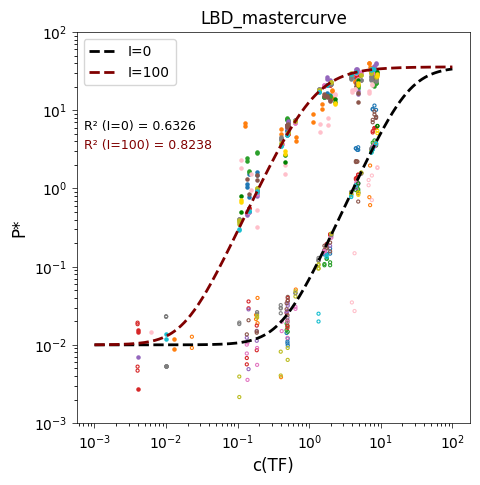

已保存： E:\Desktop\curve_points_with_colors.csv 和 E:\Desktop\curves_total_R2.csv
R² (I=0) = 0.6326, R² (I=100) = 0.8238


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from matplotlib.colors import to_rgb

# 参数设置（保持你原来的参数）
Imax = 35.84931505
# 把起点从 0 改为很小的正数，避免 log(0) 导致 nan
L = np.arange(1e-3, 100, 0.001)
k1, k2, k3 = 0.000268715, 0.007083518, 0.760771692

# kd值
kd_values = [6.216347694, 40.97704697, 5.374494076, 0.745553315, 1.445352554,
             5.066512585, 0.607055765, 1.13083303, 0.343528478, 0.102414004,
             30.08697891, 10.36936283, 10.53282547]
kd_dict = {f'kd{i+1}': kd for i, kd in enumerate(kd_values)}
I0_value = [0.01,0.035485714,0.01,0.015930056,0.011797972,0.008956896,
            0.024571917,0.006969286,0.04531675,0.111188222,0.13576227,
            0.135905549,0.272291827]

# 颜色 & 数据文件（保持你原来的路径/文件）
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b',
          '#e377c2','#7f7f7f','#bcbd22','#17becf','pink','green','gold']

df_list = [
    pd.read_csv(r"E:\Desktop\data\335_inducer100-500.csv"),
    pd.read_csv(r"E:\Desktop\all_data\data7\327\327_inducer1-100.csv"),
    pd.read_csv(r"E:\Desktop\data\337_inducer10-1000.csv"),
    pd.read_csv(r"E:\Desktop\data\338_inducer.csv"),
    pd.read_csv(r"E:\Desktop\data\339_inducer100.csv"),
    pd.read_csv(r"E:\Desktop\data\340_inducer0-500.csv"),
    pd.read_csv(r"E:\Desktop\data\342_inducer0-500.csv"),
    pd.read_csv(r"E:\Desktop\data\343_inducer.csv"),
    pd.read_csv(r"E:\Desktop\data\345_inducer.csv"),
    pd.read_csv(r"E:\Desktop\data\346_inducer0-100.csv"),
    pd.read_csv(r"E:\Desktop\data\387_inducer.csv"),
    pd.read_csv(r"E:\Desktop\data\388_inducer.csv"),
    pd.read_csv(r"E:\Desktop\data\389_inducer.csv")
]
df_list1 = [
    pd.read_csv(r"E:\Desktop\data\335_inducer0-0.1.csv"),
    pd.read_csv(r"E:\Desktop\all_data\data7\327\327_inducer0-0.1.csv"),
    pd.read_csv(r"E:\Desktop\data\337_inducer0.csv"),
    pd.read_csv(r"E:\Desktop\data\338_inducer.csv"),
    pd.read_csv(r"E:\Desktop\data\339_inducer0.csv"),
    pd.read_csv(r"E:\Desktop\data\340_inducer0-500.csv"),
    pd.read_csv(r"E:\Desktop\data\342_inducer0-500.csv"),
    pd.read_csv(r"E:\Desktop\data\343_inducer.csv"),
    pd.read_csv(r"E:\Desktop\data\345_inducer.csv"),
    pd.read_csv(r"E:\Desktop\data\346_inducer0-100.csv"),
    pd.read_csv(r"E:\Desktop\data\387_inducer.csv"),
    pd.read_csv(r"E:\Desktop\data\388_inducer.csv"),
    pd.read_csv(r"E:\Desktop\data\389_inducer.csv")
]

fig, ax = plt.subplots(figsize=(5.08,5.08))

# R^2 计算函数
def compute_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

# 全局保存（用于总R² 的计算 & CSV 输出）
all_points = []          # rows: [kd_name, curve, x, y_corrected, hex, R, G, B]
y_all_I100 = []          # corrected y for I=100 (所有 sensors 串联)
pred_all_I100 = []       # model (master) predictions at x for I=100
y_all_I0 = []            # corrected y for I=0
pred_all_I0 = []         # model (master) predictions at x for I=0

# 循环每个 sensor（保留你原有的 ddg / I0 调整逻辑）
for i, kd in enumerate(kd_values):
    # 计算每个 sensor 内所需的曲线（与原来一致）
    x1 = np.sqrt(1 + 8 * L * (k1))
    F1 = np.log(L / 2) + np.log((x1 - (k2 * 0 + 1)) / (x1 + (k2 * 0 + 1))) + np.log(kd)
    P1 = (Imax / (1 + np.exp(-F1))) + 0.01

    x2 = np.sqrt((k2 * 100 + 1)**2 + 8 * L * (k2**2 * k3 * 100**2 + k1))
    F2 = np.log(L / 2) + np.log((x2 - (k2 * 100 + 1)) / (x2 + (k2 * 100 + 1))) + np.log(kd)
    P2 = (Imax / (1 + np.exp(-F2))) + 0.01

    # master curve (固定 kd=6.216347694) - 与原来保持一致
    kd_master = 6.216347694
    Fmaster1 = np.log(L / 2) + np.log((x1 - 1) / (x1 + 1)) + np.log(kd_master)
    P_master1 = (Imax / (1 + np.exp(-Fmaster1))) + 0.01
    Fmaster2 = np.log(L / 2) + np.log((x2 - (k2 * 100 + 1)) / (x2 + (k2 * 100 + 1))) + np.log(kd_master)
    P_master2 = (Imax / (1 + np.exp(-Fmaster2))) + 0.01

    # ----- I=100 的实验点（按你原来的逻辑）
    x_exp = df_list[i]['LBD'].dropna().values
    y_exp = df_list[i]['100'].dropna().values

    # ddg = P_master2 - P2 在这些 x 点的插值
    f1 = interp1d(L, (P_master2 - P2), fill_value="extrapolate")
    ddg = f1(x_exp)
    # 你原来的修正： y = y + ddg - I0
    y_corr = y_exp + ddg - I0_value[i]

    # master 在这些 x 点的预测值
    p_master_at_x = np.interp(x_exp, L, P_master2)

    # 保存用于总体 R²
    if len(y_corr) > 0:
        y_all_I100.append(y_corr)
        pred_all_I100.append(p_master_at_x)

    # 保存点用于 CSV（颜色转为 RGB 0-255）
    hexc = colors[i]
    r_f, g_f, b_f = to_rgb(hexc)
    r_i, g_i, b_i = int(round(r_f*255)), int(round(g_f*255)), int(round(b_f*255))
    kd_name = f"kd{i+1}"
    for xx, yy in zip(x_exp, y_corr):
        all_points.append([kd_name, "I=100", xx, yy, hexc, r_i, g_i, b_i])

    # 绘出散点（位置与原来一致）
    ax.scatter(x_exp, y_corr, s=5, color=hexc)

    # ----- I=0 的实验点（按你原来的逻辑）
    x_exp0 = df_list1[i]['LBD'].dropna().values
    y_exp0 = df_list1[i]['0'].dropna().values + 0.027

    f2 = interp1d(L, (P_master1 - P1), fill_value="extrapolate")
    ddg1 = f2(x_exp0)
    # 你原来的修正： y2 = y2 + ddg1 - 2*I0
    y0_corr = y_exp0 + ddg1 - 2*I0_value[i]

    p_master0_at_x = np.interp(x_exp0, L, P_master1)

    if len(y0_corr) > 0:
        y_all_I0.append(y0_corr)
        pred_all_I0.append(p_master0_at_x)

    for xx, yy in zip(x_exp0, y0_corr):
        all_points.append([kd_name, "I=0", xx, yy, hexc, r_i, g_i, b_i])

    ax.scatter(x_exp0, y0_corr, s=5, facecolors='none', edgecolors=hexc, linewidths=0.8)


# ----- 在循环外画 master curve（只画一次）
# master 的 I=0 与 I=100（与之前外部定义 P5,P6 等价）
I1, I2 = 0, 100
x5 = np.sqrt((k2 * I1 + 1)**2 + 8 * L * (k2**2 * k3 * I1**2 + k1))
F5 = np.log(L / 2) + np.log((x5 - (k2 * I1 + 1)) / (x5 + (k2 * I1 + 1))) + np.log(kd_master)
P5 = (Imax / (1 + np.exp(-F5))) + 0.01
x6 = np.sqrt((k2 * I2 + 1)**2 + 8 * L * (k2**2 * k3 * I2**2 + k1))
F6 = np.log(L / 2) + np.log((x6 - (k2 * I2 + 1)) / (x6 + (k2 * I2 + 1))) + np.log(kd_master)
P6 = (Imax / (1 + np.exp(-F6))) + 0.01

ax.plot(L, P5, linewidth=2, label='I=0', linestyle='--', c='black')
ax.plot(L, P6, linewidth=2, label='I=100', linestyle='--', c='maroon')

# ----- 计算总体 R²（把每个 sensor 的点串接在一起）
if len(y_all_I100) > 0:
    y_all_I100_concat = np.concatenate(y_all_I100)
    pred_all_I100_concat = np.concatenate(pred_all_I100)
    r2_100 = compute_r2(y_all_I100_concat, pred_all_I100_concat)
else:
    r2_100 = np.nan

if len(y_all_I0) > 0:
    y_all_I0_concat = np.concatenate(y_all_I0)
    pred_all_I0_concat = np.concatenate(pred_all_I0)
    r2_0 = compute_r2(y_all_I0_concat, pred_all_I0_concat)
else:
    r2_0 = np.nan

# 在图上显示总体 R²（放在图上合适位置）
ax.text(0.02, 0.75, f"R² (I=0) = {r2_0:.4f}", transform=ax.transAxes, color='black', fontsize=9)
ax.text(0.02, 0.70, f"R² (I=100) = {r2_100:.4f}", transform=ax.transAxes, color='maroon', fontsize=9)

# 图形样式（保持你原来的设置）
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("c(TF)", fontsize=12, weight='light')
ax.set_ylabel("P*", fontsize=12, weight='light')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
plt.tick_params(axis='both', width=0.5)
plt.rcParams['font.weight'] = 'light'
plt.rcParams['axes.labelweight'] = 'light'
ax.set_ylim((10**(-3)), 10**2)
plt.legend(loc='upper left')
plt.title('LBD_mastercurve', fontsize=12)
plt.savefig(r"E:\Desktop\mastercurve.svg")
plt.show()

# ----- 输出 CSV：两条曲线的点位置 + 颜色
df_points = pd.DataFrame(all_points, columns=["kd","curve","x","y","hex_color","R","G","B"])
df_points.to_csv(r"E:\Desktop\curve_points_with_colors.csv", index=False)

# ----- 输出 R² 总览（可选）
df_r2 = pd.DataFrame([["I=0", r2_0], ["I=100", r2_100]], columns=["curve","R2"])
df_r2.to_csv(r"E:\Desktop\curves_total_R2.csv", index=False)

print("已保存： E:\\Desktop\\curve_points_with_colors.csv 和 E:\\Desktop\\curves_total_R2.csv")
print(f"R² (I=0) = {r2_0:.4f}, R² (I=100) = {r2_100:.4f}")


In [40]:
import pandas as pd
from scipy.interpolate import interp1d

L= np.arange(0,10,0.01)
I=100

kd1=6.216347694

kd2=40.97704697

kd3=5.374494076

kd4=0.745553315

kd5=1.445352554 

kd6=5.066512585

kd7=2.956590891

kd8=0.607055765

kd9=1.13083303

kd10=0.343528478

kd11=0.102414004

kd12=30.08697891

kd13=10.36936283

kd14=10.53282547



k1=0.000284363
k2=0.00611078
k3=0.899893641

Imax = 35.84931505


x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
F2=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd2) #LexAs5
P2 = (Imax / (1 + np.exp(-F2))) +0.035485714
# 读取数据
df1 = pd.read_csv("E:\Desktop\data\\342_inducer0-500.csv")
df2 = pd.read_csv("E:\Desktop\data\\345_inducer.csv")
df3 = pd.read_csv("E:\Desktop\data\\388_inducer.csv")

# 提取数据
x1 = df1['LBD'].dropna()
y1 = df1['100'].dropna()
y2 = df1['100'].dropna()
x2 = df2['LBD'].dropna()
y3 = df2['100'].dropna()
y4 = df2['100'].dropna()
x3 = df3['LBD'].dropna()
y5 = df3['100'].dropna()
y6 = df3['100'].dropna()

# 插值
P2_ddG = interp1d(L, P2, fill_value="extrapolate")
P2P8_ddG = P2_ddG(x1) - y2
P2P10_ddG = P2_ddG(x2) - y4
P2P12_ddG = P2_ddG(x3) - y6

# 创建一个新的DataFrame来存储结果
df_P2P8 = pd.DataFrame({
    'x': x1,
    'P2P8_ddG': P2P8_ddG
})

df_P2P10 = pd.DataFrame({
    'x': x2,
    'P2P10_ddG': P2P10_ddG
})

df_P2P12 = pd.DataFrame({
    'x': x3,
    'P2P12_ddG': P2P12_ddG
})

# 计算相同x值的P2P8_ddG，P2P10_ddG和P2P12_ddG的均值
df_grouped_P2P8 = df_P2P8.groupby('x').mean()
df_grouped_P2P10 = df_P2P10.groupby('x').mean()
df_grouped_P2P12 = df_P2P12.groupby('x').mean()

print(df_grouped_P2P8)
print(df_grouped_P2P10)
print(df_grouped_P2P12)
df_grouped = pd.concat([df_grouped_P2P8, df_grouped_P2P10, df_grouped_P2P12], axis=1)

# 将数据保存到CSV文件中
df_grouped.to_csv("E:\Desktop\data\df_grouped.csv")

           P2P8_ddG
x                  
0.000000   0.007903
0.134259   2.886129
0.137310   3.032961
0.186931   5.155122
0.412377  14.989735
0.496528  17.817732
0.641951  22.026084
1.630787  27.053153
1.633740  27.558740
2.033865  28.265063
4.567391  22.470489
5.332388  21.449699
7.678072  16.873738
8.155671  17.639643
8.536924  18.365379
          P2P10_ddG
x                  
0.000000  -0.017942
0.105405   1.805785
0.105406   1.803908
0.186931   5.038607
0.400000  14.399572
0.500000  17.996868
0.641951  21.891815
1.348649  28.167699
1.348650  28.147434
2.033865  29.894184
3.852703  27.654650
3.852704  27.631397
5.332388  28.430157
7.401351  23.865320
7.401352  24.326510
8.536924  26.142491
          P2P12_ddG
x                  
0.000000  -0.115889
0.111032   1.122118
0.459122  12.208126
2.263834  16.409455
4.850411  10.406695
8.965012   4.641638


C:\Users\Chestnut\AppData\Local\Temp\ipykernel_17472\83390882.py:45: RuntimeWarning: divide by zero encountered in log
  F2=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd2) #LexAs5


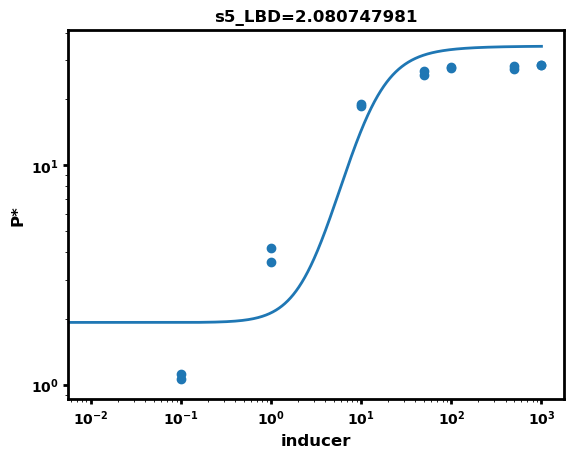

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import optimize
import scipy.constants as c
import pandas as pd


# 设置x和y的坐标范围
I= np.arange(0,1000,0.01)
k1= 0.000223424


k2= 0.007163481

k3= 0.565813482

Imax = 35.84931505
L=2.080747981



kd=57.53244494

I0 = 0.035485714



x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
F1 = np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd)
P = (Imax / (1 + np.exp(-F1))) + I0
fig, ax = plt.subplots()
ax.plot(I, P,linewidth=2,label='DeoR_F=')

df = pd.read_csv("E:\Desktop\\RPU1.csv")
x = df["inducer1"]
y1 = df["RPU12"]
ax.scatter(x, y1, label="CI434")

ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_xlim(0, 10)
#ax.set_ylim(0, 100)
ax.set_xlabel("inducer",fontsize=12,weight='bold')
ax.set_ylabel("P*",fontsize=12,weight='bold')
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.tick_params(axis='both', width=2,labelsize=10)
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.title('s5_LBD=2.080747981',fontsize=12,weight='bold')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8480\2222798494.py:29: RuntimeWarning: divide by zero encountered in log
  F1 = np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd)


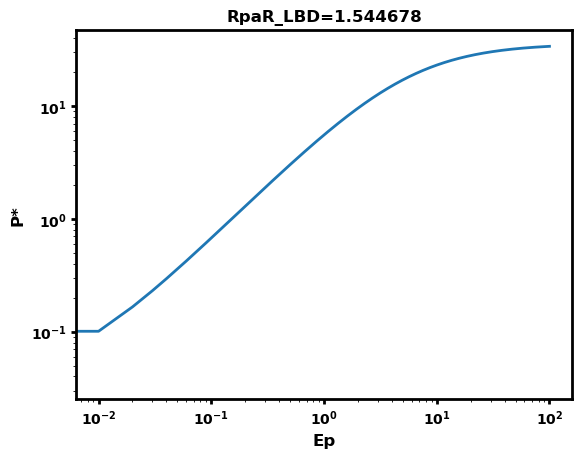

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import optimize
import scipy.constants as c
import pandas as pd


# 设置x和y的坐标范围
kd= np.arange(0,100,0.01)
k1= 0.000268715

k2= 0.007083518

k3= 0.760771692

Imax = 35.84931505
L=1.544678	

I=100


#kd=57.53244494

I0 = 0.035485714


x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
F1 = np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd)
P = (Imax / (1 + np.exp(-F1))) + I0
fig, ax = plt.subplots()
ax.plot(kd, P,linewidth=2,label='DeoR_F=')

#df = pd.read_csv("E:\Desktop\\RPU1.csv")
#x = df["inducer1"]
#y1 = df["RPU12"]
#ax.scatter(x, y1, label="CI434")

ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_xlim(0, 10)
#ax.set_ylim(0, 100)
ax.set_xlabel("Ep",fontsize=12,weight='bold')
ax.set_ylabel("P*",fontsize=12,weight='bold')
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.tick_params(axis='both', width=2,labelsize=10)
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.title('RpaR_LBD=1.544678',fontsize=12,weight='bold')
plt.show()

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import optimize
import scipy.constants as c
import pandas as pd


# 设置x和y的坐标范围
I= np.arange(0,1000,0.1)
#kd= np.arange(10,100000,1)
#I= np.arange(0,10,0.01)
#I1=1000
#I2=100
#I=0.000000001
L1=0.858029015
L2=0.319409705
L3=0.935667834
L4=2.755327664
L5=2.425362681
L6=0.964782391
L7=1.285042521
L8=3.915057529
L9=2.187593797
L10=0.329114557

L=1.576954331




kd1=8.86157218
kd2=57.53244494
kd3=7.558673946
kd4=1.11789931
kd5=1.39466996
kd6=7.196235604
kd7=4.263511229
kd8=0.613878816
kd9=1.668428973
kd10=40.91843104
kd11=0.469123259
kd12=0.080209785




k1=0.0000826




k2=0.00317686


k3=0.03111458

Imax = 35.84931505

I0 = 0.035485714 
x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
x2 = np.sqrt(1 + 8 * L * k1)
x3 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I ))

x10 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L1 * (k2*k2*k3*I*I + k1))
x11 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L2 * (k2*k2*k3*I*I + k1))
x12 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L3 * (k2*k2*k3*I*I + k1))
x13 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
x14 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L5 * (k2*k2*k3*I*I + k1))
x15 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L6 * (k2*k2*k3*I*I + k1))
x16 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L7 * (k2*k2*k3*I*I + k1))
x17 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L8 * (k2*k2*k3*I*I + k1))
x18 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L9 * (k2*k2*k3*I*I + k1))
x19 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L10 * (k2*k2*k3*I*I + k1))
F1 = np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd)
F2 = np.log(L / 2) + np.log((x3 - (k2*I+1)) / (x3 + (k2*I+1)))+ np.log(kd)
F3=((x1 - (k2*I+1)) / (x1 + (k2*I+1)))
#F4=((x1 - (k2*I1+1)) / (x1 + (k2*I1+1))) 
F5=((x3 - (k2*I+1)) / (x3 + (k2*I+1)))
F6=(k2*np.sqrt(1+8*L*k3)*I+1)*(k2*np.sqrt(1+8*L*k3)*I+1)+2*k2*(1-np.sqrt(1+8*L*k3))*I
F7=(k2*np.sqrt(1+8*L*k3)*I+np.sqrt(1+8*L*k1))**2+2*k2*I*(1-np.sqrt((1+8*L*k3)*(1+8*L*k1)))
F8=(k2*np.sqrt(1+8*L*k3)*I+np.sqrt(1+8*L*k1))
F9=((F8 - (k2*I+1)) / (F8 + (k2*I+1)))
F10=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(0.5) #CI434

F11=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd2) #LexAs5
 
F12=np.log(L4 / 2) + np.log((x13 - (k2*I+1)) / (x13 + (k2*I+1))) + np.log(kd3) #LexAs17

F13=np.log(L / 2) + np.log((x13 - (k2*I+1)) / (x13 + (k2*I+1))) + np.log(kd4) #LexA87

F14=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(2.5) #LexAs23

F15=np.log(L / 2) + np.log((x15 - (k2*I+1)) / (x15 + (k2*I+1))) + np.log(kd6) #HKCI

F16=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd7) #RecApact

F17=np.log(L / 2) + np.log((x13 - (k2*I+1)) / (x13 + (k2*I+1))) + np.log(kd8) #DeoR

F18=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(2.1) #PurR

F19=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd10) #CI OL1

F20=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd11) #LexAs15

F21=np.log(L4 / 2) + np.log((x13 - (k2*I+1)) / (x13 + (k2*I+1))) + np.log(kd12) #LexAs14

P1 = (Imax / (1 + np.exp(-F10)))+ I0

P2 = (Imax / (1 + np.exp(-F11))) 

P3 = (Imax / (1 + np.exp(-F12))) + I0

P4 = (Imax / (1 + np.exp(-F13))) + I0

P5 = (Imax / (1 + np.exp(-F14))) +0.011797972

P6 = (Imax / (1 + np.exp(-F15))) + I0

P7 = (Imax / (1 + np.exp(-F16))) + I0

P8 = (Imax / (1 + np.exp(-F17))) + I0

P9 = (Imax / (1 + np.exp(-F18))) + I0

P10 = (Imax / (1 + np.exp(-F19))) + I0

P11 = (Imax / (1 + np.exp(-F20))) + I0

P12 = (Imax / (1 + np.exp(-F21))) + I0



y=np.sqrt(8*L*k1 + 1) + I*k2/np.sqrt(8*L*k1 + 1) + I**2*np.sqrt(8*L*k1 + 1)*(4*L*k2**2*k3/(8*L*k1 + 1) + k2**2/(2*(8*L*k1 + 1)) - k2**2/(2*(8*L*k1 + 1)**2))
y2=np.sqrt(8*L*k1 + 1) + I*k2/np.sqrt(8*L*k1 + 1)
#y1=np.sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)*(-50*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 10*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)) - (-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))**2/8 + 1 - 1/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))) + (I - 10)*(80*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - (160*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + 2*k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))*(-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))/4)*sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (I - 10)**2*(4*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2**2/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)) - (8*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))*(-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))/4 - (160*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + 2*k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))**2/8)*np.sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)
fig, ax = plt.subplots()
ax.plot(I, P2,linewidth=2,label='master curve')#,c='black',linestyle='--')
#ax.plot(I, P1,linewidth=2,label='CI434')

#ax.plot(I, P2,linewidth=2,label='s5')
#ax.plot(I, P3,linewidth=2,label='LexA17')
#ax.plot(I, P4,linewidth=2,label='master curve',c='black')
ax.plot(I, P5,linewidth=2,label='LexAs23')
#ax.plot(I, P6,linewidth=2,label='master curve',c='black')
#ax.plot(I, P7,linewidth=2,label='RecApact')
#ax.plot(I, P8,linewidth=2,label='DeoR_F=')
#ax.plot(I, P9,linewidth=2,label='PurR_F=')
#ax.plot(I, P10,linewidth=2,label='master curve')
#ax.plot(I, P11,linewidth=2,label='LexAs15_F=')
#ax.plot(I, P12,linewidth=2,label='LexAs14_F=')
#ax.plot(I, F9,linewidth=3,label='f#')

#ax.plot(I, np.log10(x3),linewidth=3,label='I2=100')
#ax.plot(I, y2,linewidth=3,label='I0=0')
#ax.plot(I, y1,linewidth=3,label='I0=10')
#ax.plot(L, y1,linewidth=3,label='y4')
#ax.plot(I, P2,label='本底',linewidth=3)
#ax.plot(I, P2,label='kb=inititial*10',linewidth=3)
#ax.plot(I, P3,label='kb=inititial*100',linewidth=3)
plt.legend(loc='upper left')
#plt.annotate('P1= {:.4f}'.format(P1), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')

#plt.annotate('P2= {:.4f}'.format(P2), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')
#ax.plot(L, P2, label="P2")
#ax.scatter(x, y)
df = pd.read_csv("E:\Desktop\\RPU1.csv")
x = df["inducer3"]
x1 = df["inducer4"]
y1 = df["RPU21"]
y2 = df["RPU22"]
y3 = df["RPU31"]
y4 = df["RPU32"]
y5 = df["RPU41"]
y6 = df["RPU42"]
#y3 = df["RPU3"]
#ax.scatter(x, y1, label="DeoR")
#ax.scatter(x, y2, label="CI")
#ax.scatter(x, y3, label="s14")
error5=df["error5"]
error6=df["error6"]
error7=df["error7"]
plt.errorbar(x, y1, yerr=error5, fmt='.',c='#1f77b4')
plt.errorbar(x, y1, yerr=error5, fmt='.',c='#1f77b4')
#plt.errorbar(x1, y3, yerr=error6, fmt='.',c='#ff7f0e')
#plt.errorbar(x1, y4, yerr=error6, fmt='.',c='#ff7f0e')
plt.errorbar(x1, y5, yerr=error7, fmt='.',c='#ff7f0e')
plt.errorbar(x1, y6, yerr=error7, fmt='.',c='#ff7f0e')
# 设置横纵坐标轴的取值范围和标签
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_xlim(0, 10)
#ax.set_ylim(0, 100)
ax.set_xlabel("inducer",fontsize=12,weight='bold')
ax.set_ylabel("P*",fontsize=12,weight='bold')
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.tick_params(axis='both', width=2,labelsize=10)
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
ax.set_ylim((10**(-3)),10**2)
ax.set_xlim((10**(-1)),10**3.2)
print(y)
# 添加图例并显示图形
plt.title('BjaR_LBD=1.576954331',fontsize=12,weight='bold')

#plt.savefig("E:\Desktop\\377_Ltot.svg",format="svg")
plt.show()

NameError: name 'kd' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import optimize
import scipy.constants as c
import pandas as pd


# 设置x和y的坐标范围
I= np.arange(0,1000,0.1)
#kd= np.arange(10,100000,1)
#I= np.arange(0,10,0.01)
#I1=1000
#I2=100
#I=0.000000001
L1=0.858029015
L2=0.319409705
L3=0.935667834
L4=2.755327664
L5=2.425362681
L6=0.964782391
L7=1.285042521
L8=3.915057529
L9=2.187593797
L10=0.329114557

L=1.576954331




kd1=8.86157218
kd2=57.53244494
kd3=7.558673946
kd4=1.11789931
kd5=1.39466996
kd6=7.196235604
kd7=4.263511229
kd8=0.613878816
kd9=1.668428973
kd10=40.91843104
kd11=0.469123259
kd12=0.080209785




k1=0.0000826




k2=0.00317686


k3=0.03111458

Imax = 35.84931505

I0 = 0.035485714 
x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
x2 = np.sqrt(1 + 8 * L * k1)
x3 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I ))

x10 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L1 * (k2*k2*k3*I*I + k1))
x11 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L2 * (k2*k2*k3*I*I + k1))
x12 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L3 * (k2*k2*k3*I*I + k1))
x13 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
x14 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L5 * (k2*k2*k3*I*I + k1))
x15 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L6 * (k2*k2*k3*I*I + k1))
x16 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L7 * (k2*k2*k3*I*I + k1))
x17 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L8 * (k2*k2*k3*I*I + k1))
x18 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L9 * (k2*k2*k3*I*I + k1))
x19 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L10 * (k2*k2*k3*I*I + k1))
F1 = np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd)
F2 = np.log(L / 2) + np.log((x3 - (k2*I+1)) / (x3 + (k2*I+1)))+ np.log(kd)
F3=((x1 - (k2*I+1)) / (x1 + (k2*I+1)))
#F4=((x1 - (k2*I1+1)) / (x1 + (k2*I1+1))) 
F5=((x3 - (k2*I+1)) / (x3 + (k2*I+1)))
F6=(k2*np.sqrt(1+8*L*k3)*I+1)*(k2*np.sqrt(1+8*L*k3)*I+1)+2*k2*(1-np.sqrt(1+8*L*k3))*I
F7=(k2*np.sqrt(1+8*L*k3)*I+np.sqrt(1+8*L*k1))**2+2*k2*I*(1-np.sqrt((1+8*L*k3)*(1+8*L*k1)))
F8=(k2*np.sqrt(1+8*L*k3)*I+np.sqrt(1+8*L*k1))
F9=((F8 - (k2*I+1)) / (F8 + (k2*I+1)))
F10=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(0.5) #CI434

F11=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd2) #LexAs5
 
F12=np.log(L4 / 2) + np.log((x13 - (k2*I+1)) / (x13 + (k2*I+1))) + np.log(kd3) #LexAs17

F13=np.log(L / 2) + np.log((x13 - (k2*I+1)) / (x13 + (k2*I+1))) + np.log(kd4) #LexA87

F14=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(2.5) #LexAs23

F15=np.log(L / 2) + np.log((x15 - (k2*I+1)) / (x15 + (k2*I+1))) + np.log(kd6) #HKCI

F16=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd7) #RecApact

F17=np.log(L / 2) + np.log((x13 - (k2*I+1)) / (x13 + (k2*I+1))) + np.log(kd8) #DeoR

F18=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(2.1) #PurR

F19=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd10) #CI OL1

F20=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd11) #LexAs15

F21=np.log(L4 / 2) + np.log((x13 - (k2*I+1)) / (x13 + (k2*I+1))) + np.log(kd12) #LexAs14

P1 = (Imax / (1 + np.exp(-F10)))+ I0

P2 = (Imax / (1 + np.exp(-F11))) 

P3 = (Imax / (1 + np.exp(-F12))) + I0

P4 = (Imax / (1 + np.exp(-F13))) + I0

P5 = (Imax / (1 + np.exp(-F14))) +0.011797972

P6 = (Imax / (1 + np.exp(-F15))) + I0

P7 = (Imax / (1 + np.exp(-F16))) + I0

P8 = (Imax / (1 + np.exp(-F17))) + I0

P9 = (Imax / (1 + np.exp(-F18))) + I0

P10 = (Imax / (1 + np.exp(-F19))) + I0

P11 = (Imax / (1 + np.exp(-F20))) + I0

P12 = (Imax / (1 + np.exp(-F21))) + I0



y=np.sqrt(8*L*k1 + 1) + I*k2/np.sqrt(8*L*k1 + 1) + I**2*np.sqrt(8*L*k1 + 1)*(4*L*k2**2*k3/(8*L*k1 + 1) + k2**2/(2*(8*L*k1 + 1)) - k2**2/(2*(8*L*k1 + 1)**2))
y2=np.sqrt(8*L*k1 + 1) + I*k2/np.sqrt(8*L*k1 + 1)
#y1=np.sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)*(-50*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 10*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)) - (-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))**2/8 + 1 - 1/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))) + (I - 10)*(80*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - (160*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + 2*k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))*(-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))/4)*sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (I - 10)**2*(4*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2**2/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)) - (8*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))*(-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))/4 - (160*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + 2*k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))**2/8)*np.sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)
fig, ax = plt.subplots()
ax.plot(I, P2,linewidth=2,label='master curve')#,c='black',linestyle='--')
#ax.plot(I, P1,linewidth=2,label='CI434')

#ax.plot(I, P2,linewidth=2,label='s5')
#ax.plot(I, P3,linewidth=2,label='LexA17')
#ax.plot(I, P4,linewidth=2,label='master curve',c='black')
ax.plot(I, P5,linewidth=2,label='LexAs23')
#ax.plot(I, P6,linewidth=2,label='master curve',c='black')
#ax.plot(I, P7,linewidth=2,label='RecApact')
#ax.plot(I, P8,linewidth=2,label='DeoR_F=')
#ax.plot(I, P9,linewidth=2,label='PurR_F=')
#ax.plot(I, P10,linewidth=2,label='master curve')
#ax.plot(I, P11,linewidth=2,label='LexAs15_F=')
#ax.plot(I, P12,linewidth=2,label='LexAs14_F=')
#ax.plot(I, F9,linewidth=3,label='f#')

#ax.plot(I, np.log10(x3),linewidth=3,label='I2=100')
#ax.plot(I, y2,linewidth=3,label='I0=0')
#ax.plot(I, y1,linewidth=3,label='I0=10')
#ax.plot(L, y1,linewidth=3,label='y4')
#ax.plot(I, P2,label='本底',linewidth=3)
#ax.plot(I, P2,label='kb=inititial*10',linewidth=3)
#ax.plot(I, P3,label='kb=inititial*100',linewidth=3)
plt.legend(loc='upper left')
#plt.annotate('P1= {:.4f}'.format(P1), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')

#plt.annotate('P2= {:.4f}'.format(P2), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')
#ax.plot(L, P2, label="P2")
#ax.scatter(x, y)
df = pd.read_csv("E:\Desktop\\RPU1.csv")
x = df["inducer3"]
x1 = df["inducer4"]
y1 = df["RPU21"]

y2 = df["RPU22"]
y3 = df["RPU31"]
y4 = df["RPU32"]
y5 = df["RPU41"]
y6 = df["RPU42"]
#y3 = df["RPU3"]
#ax.scatter(x, y1, label="DeoR")
#ax.scatter(x, y2, label="CI")
#ax.scatter(x, y3, label="s14")
error5=df["error5"]
error6=df["error6"]
error7=df["error7"]
plt.errorbar(x, y1, yerr=error5, fmt='.',c='#1f77b4')
plt.errorbar(x, y1, yerr=error5, fmt='.',c='#1f77b4')
#plt.errorbar(x1, y3, yerr=error6, fmt='.',c='#ff7f0e')
#plt.errorbar(x1, y4, yerr=error6, fmt='.',c='#ff7f0e')
plt.errorbar(x1, y5, yerr=error7, fmt='.',c='#ff7f0e')
plt.errorbar(x1, y6, yerr=error7, fmt='.',c='#ff7f0e')
# 设置横纵坐标轴的取值范围和标签
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_xlim(0, 10)
#ax.set_ylim(0, 100)
ax.set_xlabel("inducer",fontsize=12,weight='bold')
ax.set_ylabel("P*",fontsize=12,weight='bold')
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.tick_params(axis='both', width=2,labelsize=10)
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
ax.set_ylim((10**(-3)),10**2)
ax.set_xlim((10**(-1)),10**3.2)
print(y)
# 添加图例并显示图形
plt.title('BjaR_LBD=1.576954331',fontsize=12,weight='bold')

#plt.savefig("E:\Desktop\\377_Ltot.svg",format="svg")
plt.show()

In [22]:
from sympy import symbols, sqrt, series

# 定义变量
I,  k2, k3, L = symbols('I  k2 k3 L')

# 定义函数
x1 = sqrt((k2*I+1)**2 + 8*L*(k2**2*k3*I**2 ))
F=((x1 - (k2*I+1)) / (x1 + (k2*I+1)))
#F6=(k2*np.sqrt(1+8*L*k3)*I+1)**2+2*k2*(1-np.sqrt(1+8*L*k3))*I

taylor_expansion = series(F, I, 0, 3)

print(taylor_expansion)



2*I**2*L*k2**2*k3 + O(I**3)


In [93]:
from sympy import symbols, diff, sqrt, latex

# 定义符号
I, k1, k2, k3, L = symbols('I k1 k2 k3 L')

# 定义函数
x1 = sqrt((k2*I+1)**2 + 8 * L * (k2**2*k3*I**2 + k1))
F3 = (x1 - (k2*I+1)) / (x1 + (k2*I+1))

# 计算一阶导数
F3_prime = diff(F3, I)

# 计算二阶导数
F3_double_prime = diff(F3_prime, I)

# 输出LaTeX格式的结果
print('F3\' =', latex(F3_prime))
print('F3\'\' =', latex(F3_double_prime))

F3' = \frac{\left(- k_{2} - \frac{8 I L k_{2}^{2} k_{3} + k_{2} \left(I k_{2} + 1\right)}{\sqrt{8 L \left(I^{2} k_{2}^{2} k_{3} + k_{1}\right) + \left(I k_{2} + 1\right)^{2}}}\right) \left(- I k_{2} + \sqrt{8 L \left(I^{2} k_{2}^{2} k_{3} + k_{1}\right) + \left(I k_{2} + 1\right)^{2}} - 1\right)}{\left(I k_{2} + \sqrt{8 L \left(I^{2} k_{2}^{2} k_{3} + k_{1}\right) + \left(I k_{2} + 1\right)^{2}} + 1\right)^{2}} + \frac{- k_{2} + \frac{8 I L k_{2}^{2} k_{3} + k_{2} \left(I k_{2} + 1\right)}{\sqrt{8 L \left(I^{2} k_{2}^{2} k_{3} + k_{1}\right) + \left(I k_{2} + 1\right)^{2}}}}{I k_{2} + \sqrt{8 L \left(I^{2} k_{2}^{2} k_{3} + k_{1}\right) + \left(I k_{2} + 1\right)^{2}} + 1}
F3'' = \frac{\left(- 2 k_{2} - \frac{2 \cdot \left(8 I L k_{2}^{2} k_{3} + k_{2} \left(I k_{2} + 1\right)\right)}{\sqrt{8 L \left(I^{2} k_{2}^{2} k_{3} + k_{1}\right) + \left(I k_{2} + 1\right)^{2}}}\right) \left(- k_{2} - \frac{8 I L k_{2}^{2} k_{3} + k_{2} \left(I k_{2} + 1\right)}{\sqrt{8 L \left(I^{2} k_{2}^{2} k

F3' = \frac{\left(- k_{2} - \frac{8 I L k_{2}^{2} k_{3} + k_{2} \left(I k_{2} + 1\right)}{\sqrt{8 L \left(I^{2} k_{2}^{2} k_{3} + k_{1}\right) + \left(I k_{2} + 1\right)^{2}}}\right) \left(- I k_{2} + \sqrt{8 L \left(I^{2} k_{2}^{2} k_{3} + k_{1}\right) + \left(I k_{2} + 1\right)^{2}} - 1\right)}{\left(I k_{2} + \sqrt{8 L \left(I^{2} k_{2}^{2} k_{3} + k_{1}\right) + \left(I k_{2} + 1\right)^{2}} + 1\right)^{2}} + \frac{- k_{2} + \frac{8 I L k_{2}^{2} k_{3} + k_{2} \left(I k_{2} + 1\right)}{\sqrt{8 L \left(I^{2} k_{2}^{2} k_{3} + k_{1}\right) + \left(I k_{2} + 1\right)^{2}}}}{I k_{2} + \sqrt{8 L \left(I^{2} k_{2}^{2} k_{3} + k_{1}\right) + \left(I k_{2} + 1\right)^{2}} + 1}
F3'' = \frac{\left(- 2 k_{2} - \frac{2 \cdot \left(8 I L k_{2}^{2} k_{3} + k_{2} \left(I k_{2} + 1\right)\right)}{\sqrt{8 L \left(I^{2} k_{2}^{2} k_{3} + k_{1}\right) + \left(I k_{2} + 1\right)^{2}}}\right) \left(- k_{2} - \frac{8 I L k_{2}^{2} k_{3} + k_{2} \left(I k_{2} + 1\right)}{\sqrt{8 L \left(I^{2} k_{2}^{2} k_{3} + k_{1}\right) + \left(I k_{2} + 1\right)^{2}}}\right) \left(- I k_{2} + \sqrt{8 L \left(I^{2} k_{2}^{2} k_{3} + k_{1}\right) + \left(I k_{2} + 1\right)^{2}} - 1\right)}{\left(I k_{2} + \sqrt{8 L \left(I^{2} k_{2}^{2} k_{3} + k_{1}\right) + \left(I k_{2} + 1\right)^{2}} + 1\right)^{3}} + \frac{2 \left(- k_{2} - \frac{8 I L k_{2}^{2} k_{3} + k_{2} \left(I k_{2} + 1\right)}{\sqrt{8 L \left(I^{2} k_{2}^{2} k_{3} + k_{1}\right) + \left(I k_{2} + 1\right)^{2}}}\right) \left(- k_{2} + \frac{8 I L k_{2}^{2} k_{3} + k_{2} \left(I k_{2} + 1\right)}{\sqrt{8 L \left(I^{2} k_{2}^{2} k_{3} + k_{1}\right) + \left(I k_{2} + 1\right)^{2}}}\right)}{\left(I k_{2} + \sqrt{8 L \left(I^{2} k_{2}^{2} k_{3} + k_{1}\right) + \left(I k_{2} + 1\right)^{2}} + 1\right)^{2}} + \frac{\left(- \frac{8 L k_{2}^{2} k_{3} + k_{2}^{2}}{\sqrt{8 L \left(I^{2} k_{2}^{2} k_{3} + k_{1}\right) + \left(I k_{2} + 1\right)^{2}}} - \frac{\left(- 8 I L k_{2}^{2} k_{3} - k_{2} \left(I k_{2} + 1\right)\right) \left(8 I L k_{2}^{2} k_{3} + k_{2} \left(I k_{2} + 1\right)\right)}{\left(8 L \left(I^{2} k_{2}^{2} k_{3} + k_{1}\right) + \left(I k_{2} + 1\right)^{2}\right)^{\frac{3}{2}}}\right) \left(- I k_{2} + \sqrt{8 L \left(I^{2} k_{2}^{2} k_{3} + k_{1}\right) + \left(I k_{2} + 1\right)^{2}} - 1\right)}{\left(I k_{2} + \sqrt{8 L \left(I^{2} k_{2}^{2} k_{3} + k_{1}\right) + \left(I k_{2} + 1\right)^{2}} + 1\right)^{2}} + \frac{\frac{8 L k_{2}^{2} k_{3} + k_{2}^{2}}{\sqrt{8 L \left(I^{2} k_{2}^{2} k_{3} + k_{1}\right) + \left(I k_{2} + 1\right)^{2}}} + \frac{\left(- 8 I L k_{2}^{2} k_{3} - k_{2} \left(I k_{2} + 1\right)\right) \left(8 I L k_{2}^{2} k_{3} + k_{2} \left(I k_{2} + 1\right)\right)}{\left(8 L \left(I^{2} k_{2}^{2} k_{3} + k_{1}\right) + \left(I k_{2} + 1\right)^{2}\right)^{\frac{3}{2}}}}{I k_{2} + \sqrt{8 L \left(I^{2} k_{2}^{2} k_{3} + k_{1}\right) + \left(I k_{2} + 1\right)^{2}} + 1}


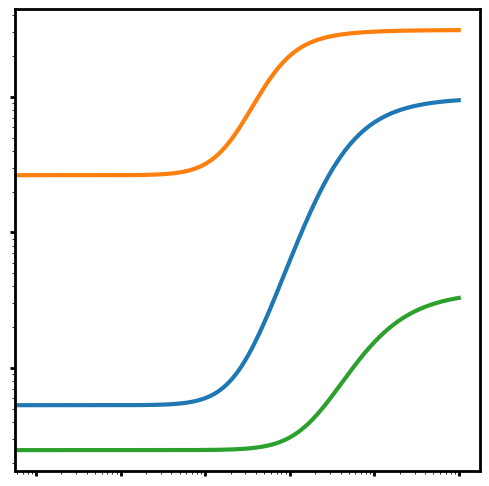

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import optimize
import scipy.constants as c
import pandas as pd

'''
df = pd.read_csv("E:\Desktop\\all_data\crossvalidation2\\377.csv")
x = df["inducer"]
y = df["RPU"]
'''
L1=1.515057529




L2=1.515057529*10

L3=1.515057529/10
L=2.515057529


# 设置x和y的坐标范围
I= np.arange(0,1000,0.01)
#kd= np.arange(10,100000,1)
#I= np.arange(0,10,0.01)

k1=0.000313234

k2=0.013255784

k3=0.478307406

Imax = 35.84931505

I0 = 0.01
kd1=1.11789931





kd2=8.86157218*50
kd3=8.86157218/500
#L=0.01
x1=np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L1 * (k2*k2*k3*I*I + k1))
x2=np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L2 * (k2*k2*k3*I*I + k1))
x3=np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L3 * (k2*k2*k3*I*I + k1))
x4=np.sqrt((k2*100+1)*(k2*100+1)+ 8 * L * (k2*k2*k3*100*100 + k1))
x5=np.sqrt((+1)*(+1)+ 8 * L * (k1))
#x3=np.sqrt(1+8*L1*(kb1+I*kc1)



F1 = np.log(L1 / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd1)
F2 = np.log(L2 / 2) + np.log((x2 - (k2*I+1)) / (x2 + (k2*I+1))) + np.log(kd1)
F3 = np.log(L3 / 2) + np.log((x3 - (k2*I+1)) / (x3 + (k2*I+1))) + np.log(kd1)
F4 = np.log(L / 2) + np.log((x4 - (k2*100+1)) / (x4 + (k2*100+1))) + np.log(kd1)
F5 = np.log(L / 2) + np.log((x5 - (1)) / (x5 + (1))) + np.log(kd1)
#F3=np.log(L1/2)+np.log((x3-1)/(x3+1))+np.log(kd1)


P1=(Imax/(1+np.exp(-F1)))+0.024571917

P2=(Imax/(1+np.exp(-F2)))+0.024571917

P3=(Imax/(1+np.exp(-F3)))+0.024571917

P4=(Imax/(1+np.exp(-F4)))+0.024571917

P5=(Imax/(1+np.exp(-F5)))+0.024571917
#P3=(Imax1/(1+np.exp(-F3)))+I0
#foldchange1=P1/P2
#foldchange2=P1-P2


#foldchange1=foldchange1.reshape(10000,10000)
#plt.plot(np.log10(L),P1,label="P1")
#plt.plot(np.log10(L),P2,label="P2")
#plt.plot(np.log10(kd),np.log10(foldchange1),label="foldchange1")
#plt.plot(np.log10(kd),np.log10(foldchange2),label="foldchange2")
fig, ax = plt.subplots(figsize=(5.08,5.08))


#z=df['326']
# 绘制曲线和散点图
ax.plot(I, P1,linewidth=3,label='L')
ax.plot(I, P2,linewidth=3,label='L*10')
ax.plot(I, P3,linewidth=3,label='L/10')
#ax.plot(I, P2,label='本底',linewidth=3)
#ax.plot(I, P2,label='kb=inititial*10',linewidth=3)
#ax.plot(I, P3,label='kb=inititial*100',linewidth=3)
#plt.legend(loc='upper left')
#plt.annotate('P1= {:.4f}'.format(P1), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')

#plt.annotate('P2= {:.4f}'.format(P2), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')
#ax.plot(L, P2, label="P2")
#ax.scatter(x, y)
#ax.scatter(x, z, label="326")

# 设置横纵坐标轴的取值范围和标签
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_xlim(0, 10)
#ax.set_ylim(0, 100)
#ax.set_xlabel("inducer",fontsize=12,weight='bold')
#ax.set_ylabel("P*",fontsize=12,weight='bold')
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.tick_params(axis='both', width=2,labelsize=10)
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
# 去掉数字刻度
ax.get_xaxis().set_major_formatter(plt.NullFormatter())
ax.get_yaxis().set_major_formatter(plt.NullFormatter())
# 添加图例并显示图形
#plt.title('RpaR',fontsize=12,weight='bold')
plt.savefig("E:\Desktop\\L_change.svg",format="svg")
plt.show()

[2.80486496e-05 2.82231815e-05 2.83981809e-05 ... 7.13794003e-03
 7.13885771e-03 7.13977540e-03] [2.91046409e-07 2.92989953e-07 2.94939964e-07 ... 3.23190897e-04
 3.23255558e-04 3.23320226e-04] [0.01089551 0.01096331 0.01103129 ... 2.7727364  2.77309287 2.77344935] [1.13057124e-04 1.13812095e-04 1.14569577e-04 ... 1.25543667e-01
 1.25568784e-01 1.25593904e-01]
0.11962276452148982
0.0007611803461705116
0.28749309756245983
0.29568088861185465


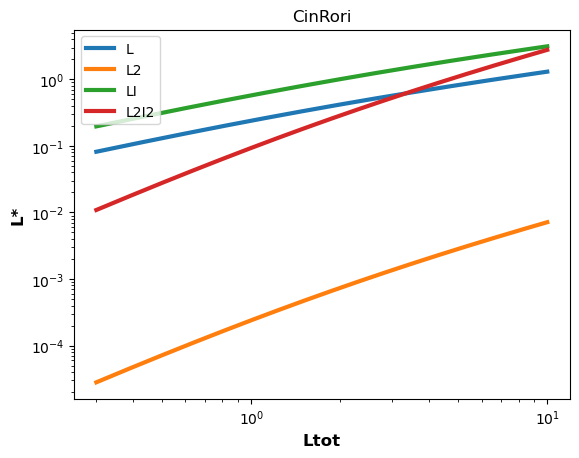

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import palettable
from scipy.stats import linregress

L = np.arange(0.3, 10, 0.001)
k1=0.004199071


k2=24.03330994


k3=0.282398075

I=0.1
a=k2*I+1
b=k2*k2*k3*I*I+k1

A=(-a+np.sqrt(a*a+8*L*b))/(4*b)
B=k1*A*A
C=k2*I*A
D=k2*k2*k3*I*I*A*A
A1=L/(k2*I+1+2*k2*k2*k3*I+2*k1)
B1=k1*A1*A1
C1=k2*I*A1
D1=k2*k2*k3*I*I*A1*A1
fig, ax = plt.subplots()
ax.set_xscale("log")
ax.set_yscale("log")
colors = palettable.cartocolors.diverging.Fall_3.mpl_colors
plt.plot(L, A, linewidth=3.0,label='L')
plt.plot(L, B, linewidth=3.0,label='L2')
plt.plot(L, C, linewidth=3.0,label='LI')
plt.plot(L, D, linewidth=3.0,label='L2I2')
#plt.plot(L, A1, linewidth=3.0,label='L')
#plt.plot(L, B1, linewidth=3.0,label='L2')
#plt.plot(L, C1, linewidth=3.0,label='LI')
#plt.plot(L, D1, linewidth=3.0,label='L2I2')
print(B,B1,D,D1)

slope, intercept = np.polyfit(L, A, 1)
print(slope)
slope1, intercept1 = np.polyfit(L, B, 1)
print(slope1)
slope2, intercept2 = np.polyfit(L, C, 1)
print(slope2)
slope3, intercept3 = np.polyfit(L, D, 1)
print(slope3)

ax.set_xlabel("Ltot",fontsize=12,weight='bold')
ax.set_ylabel("L*",fontsize=12,weight='bold')
plt.legend(loc='upper left')
plt.title('CinRori')
#plt.savefig("E:\Desktop\\CinRori_L_approximation.svg",format="svg")
plt.show()



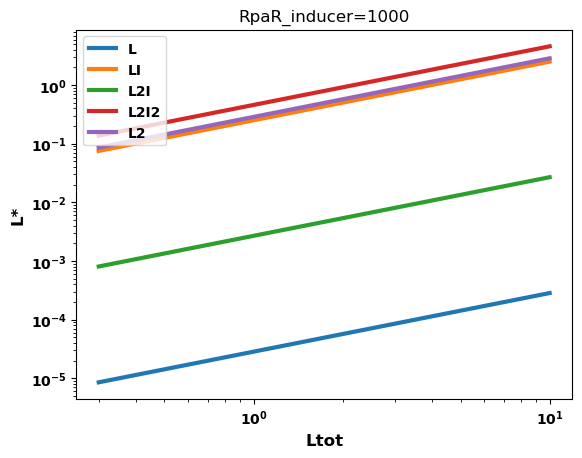

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import palettable
from scipy.stats import linregress

L = np.arange(0.3, 10, 0.001)
k1=8.853433609008789
k2=0.047301098704338074
k3=0.12714891135692596 
k4=0.624855101108551

I=1000
a=k2*I+1
b=k2*k2*k3*I*I+k1

A=1
B=I*k1
C=2*I*k2
D=(k3*I)*(k3*I)
E=k4*(k3*I)*(k3*I)
F=A+B+C+D+E
fig, ax = plt.subplots()
ax.set_xscale("log")
ax.set_yscale("log")
colors = palettable.cartocolors.diverging.Fall_3.mpl_colors
plt.plot(L, A*L/F, linewidth=3.0,label='L')
plt.plot(L, B*L/F, linewidth=3.0,label='LI')
plt.plot(L, C*L/F, linewidth=3.0,label='L2I')
plt.plot(L, D*L/F, linewidth=3.0,label='L2I2')
plt.plot(L, E*L/F, linewidth=3.0,label='L2')
#plt.plot(L, A1, linewidth=3.0,label='L')
#plt.plot(L, B1, linewidth=3.0,label='L2')
#plt.plot(L, C1, linewidth=3.0,label='LI')
#plt.plot(L, D1, linewidth=3.0,label='L2I2')

'''
slope, intercept = np.polyfit(L, A, 1)
print(slope)
slope1, intercept1 = np.polyfit(L, B, 1)
print(slope1)
slope2, intercept2 = np.polyfit(L, C, 1)
print(slope2)
slope3, intercept3 = np.polyfit(L, D, 1)
print(slope3)
'''
ax.set_xlabel("Ltot",fontsize=12,weight='bold')
ax.set_ylabel("L*",fontsize=12,weight='bold')
plt.legend(loc='upper left')
plt.title('RpaR_inducer=1000')
#plt.savefig("E:\Desktop\\CinRori_L_approximation.svg",format="svg")
plt.show()



C:\Users\Chestnut\AppData\Local\Temp\ipykernel_14688\3647852631.py:24: RuntimeWarning: divide by zero encountered in log
  F1 = np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd)
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_14688\3647852631.py:25: RuntimeWarning: divide by zero encountered in log
  F2 = np.log(L / 2) + np.log((x2 - 1) / (x2 + 1)) + np.log(kd)


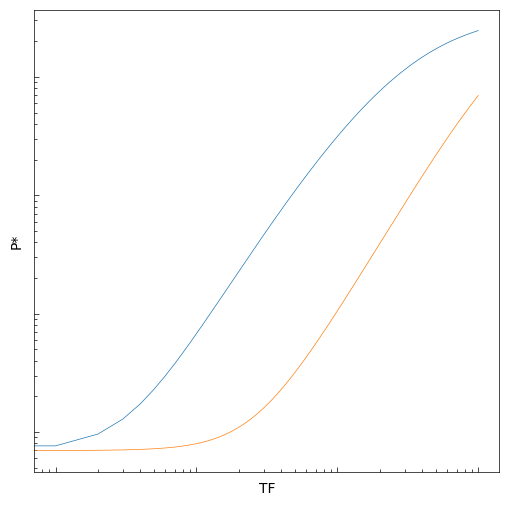

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.interpolate import interp1d
import palettable

# 设置x和y的坐标范围
L = np.arange(0, 10, 0.01)

k1=0.004199071

k2=24.03330994

k3=0.282398075

kd=0.668428973
I=1000
Imax=35.84931505


I0=0.006969286
x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
x2 = np.sqrt(1 + 8 * L * k1)
F1 = np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd)
F2 = np.log(L / 2) + np.log((x2 - 1) / (x2 + 1)) + np.log(kd)
P1 = (Imax / (1 + np.exp(-F1))) + I0
P2 = (Imax / (1 + np.exp(-F2))) + I0
f1 = P1 / P2
f2 = P1 - P2

fig, ax = plt.subplots(figsize=(6,6))

# 选择颜色方案
colors = palettable.cartocolors.diverging.Fall_3.mpl_colors
#plt.plot(L, f1, color=colors[0], linewidth=3.0,label='f1')
#plt.plot(L, f2, color=colors[2], linewidth=3.0,label='f2')
plt.plot(L, P1,  linewidth=0.5)
plt.plot(L, P2, linewidth=0.5)
#plt.plot(L, foldchange1, linewidth=3.0,label='foldcahnge1_approximate')
#plt.plot(L, foldchange1, color=colors[2], linewidth=3.0,label='foldcahnge1_approximate')
#plt.plot(L, y1, linewidth=3.0,label='y1')
#plt.plot(L, y2, linewidth=3.0,label='y2')
#plt.legend(loc='upper right')


#plt.title('CinRori')
plt.xlabel("TF")
plt.ylabel("P*")
plt.xscale("log")
plt.yscale("log")
# 去掉数字刻度
ax.get_xaxis().set_major_formatter(plt.NullFormatter())
ax.get_yaxis().set_major_formatter(plt.NullFormatter())

# 设置加粗的边框
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
#plt.savefig('/T18/lizengli/MyProject/LBD_DBD/fig2/araR.png',dpi=400)
plt.tick_params(axis='both', width=0.5, labelsize=10, direction='in', which='both')
plt.savefig('tf_2.pdf', bbox_inches='tight')

plt.show()


270668.8133099021 2257714.275445371 0.11988621246437761


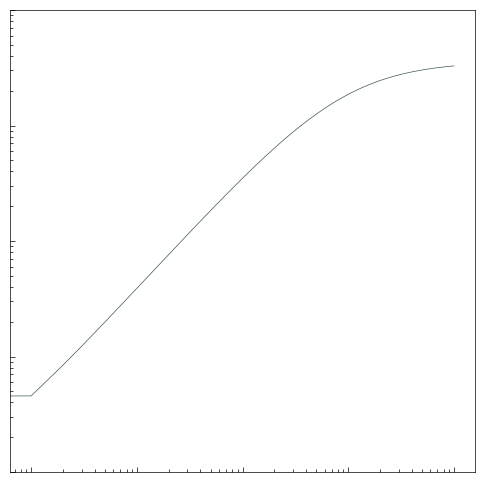

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.interpolate import interp1d
import palettable

# 设置x和y的坐标范围
L = np.arange(0, 10, 0.001)

k1 = 0.0005032600020058453
k2 = 1.9098836183547974
k3 = 1.9557790756225586
k4 = 0.031322088092565536
kd = 8.990784645080566
I = 1000
Imax = 35.84931505
I0 = 0.006969286

x1 = 2*(I/k2)+(I/k3)*(I/k3)+k4*(I/k3)*(I/k3)
F1 = 1 + (I/k1) + x1
print(x1, F1, x1/F1)

P1 = Imax * (((x1/F1) * L * kd) / (1 + ((x1/F1) * L * kd))) + I0

fig, ax = plt.subplots(figsize=(6,6))

# 选择颜色方案
colors = palettable.cartocolors.diverging.Fall_3.mpl_colors
plt.plot(L, P1, color=colors[0], linewidth=0.5)

# 设置坐标轴和范围
ax.set_ylim(10**(-2), 10**2)
ax.set_xscale("log")
ax.set_yscale("log")

# 去掉数字刻度
ax.get_xaxis().set_major_formatter(plt.NullFormatter())
ax.get_yaxis().set_major_formatter(plt.NullFormatter())

# 设置加粗的边框
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

# 添加标签
#plt.xlabel("TF")
#plt.ylabel("P*")
plt.tick_params(axis='both', width=0.5, labelsize=10, direction='in', which='both')
plt.savefig('tf_1.pdf', bbox_inches='tight')

plt.show()


In [12]:
from Bio import AlignIO
from Bio.Align import AlignInfo
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 读取序列对齐文件
alignment = AlignIO.read("C:\\Users\\Lenovo\\Nutstore\\1\\work\\operator\\LexA_B.subtilis.fasta", "fasta")

# 创建摘要对齐对象
summary_align = AlignInfo.SummaryInfo(alignment)

# 计算PWM
pwm = summary_align.pos_specific_score_matrix()

# 输出PWM
for pos in pwm:
    print(pos)

# 生成一致性序列
consensus = summary_align.dumb_consensus()

# 输出一致性序列
print(consensus)

# 将PWM转换为DataFrame
pwm_df = pd.DataFrame(pwm)

# 使用seaborn的heatmap函数绘制PWM图像
plt.figure(figsize=(8, 6))
sns.heatmap(pwm_df, annot=True, cmap='viridis')
plt.title('PWM Heatmap')
plt.xlabel('Position')
plt.ylabel('Nucleotide')
plt.show()

{'A': 17.0, 'C': 18.0, 'G': 5.0, 'T': 0}
{'A': 5.0, 'C': 0, 'G': 35.0, 'T': 0}
{'A': 40.0, 'C': 0, 'G': 0, 'T': 0}
{'A': 40.0, 'C': 0, 'G': 0, 'T': 0}
{'A': 1.0, 'C': 36.0, 'G': 0, 'T': 3.0}
{'A': 22.0, 'C': 2.0, 'G': 11.0, 'T': 5.0}
{'A': 8.0, 'C': 2.0, 'G': 0, 'T': 30.0}
{'A': 21.0, 'C': 0, 'G': 6.0, 'T': 13.0}
{'A': 6.0, 'C': 13.0, 'G': 1.0, 'T': 20.0}
{'A': 4.0, 'C': 0, 'G': 34.0, 'T': 2.0}
{'A': 0, 'C': 0, 'G': 0, 'T': 40.0}
{'A': 0, 'C': 0, 'G': 0, 'T': 40.0}
{'A': 1.0, 'C': 32.0, 'G': 0, 'T': 7.0}
{'A': 1.0, 'C': 8.0, 'G': 17.0, 'T': 14.0}
XGAACXTXXGTTCX


ValueError: DataFrame constructor not properly called!

In [55]:

from Bio import SeqIO
from Bio.Align.Applications import ClustalOmegaCommandline
from collections import Counter
import numpy as np
import pandas as pd
import logomaker

# 执行多序列比对
clustalomega_cline = ClustalOmegaCommandline(infile="E:\\Desktop\\work\\operator\\LexA_B.subtilis.fasta", outfile="E:\\Desktop\\aligned.fasta", verbose=True, auto=True)
stdout, stderr = clustalomega_cline()

# 读取对齐后的fasta文件
sequences = []
for record in SeqIO.parse("E:\\Desktop\\aligned.fasta", "fasta"):
    sequences.append(str(record.seq))

# 初始化PWM
pwm = np.zeros((4, len(sequences[0])))

# 计算PWM
for sequence in sequences:
    for i, base in enumerate(sequence):
        if base == 'A':
            pwm[0, i] += 1
        elif base == 'C':
            pwm[1, i] += 1
        elif base == 'G':
            pwm[2, i] += 1
        elif base == 'T':
            pwm[3, i] += 1

# 将计数转换为频率
pwm = pwm / len(sequences)

# 输出一致性序列
consensus = ''
for i in range(pwm.shape[1]):
    if np.argmax(pwm[:, i]) == 0:
        consensus += 'A'
    elif np.argmax(pwm[:, i]) == 1:
        consensus += 'C'
    elif np.argmax(pwm[:, i]) == 2:
        consensus += 'G'
    elif np.argmax(pwm[:, i]) == 3:
        consensus += 'T'

print('Consensus sequence:', consensus)

# 将PWM转换为DataFrame
pwm_df = pd.DataFrame(pwm, columns=list('ACGT'))

# 创建序列标志图
logo = logomaker.Logo(pwm_df)

# 显示图形
logo.draw()

Exception in thread Thread-19:
Traceback (most recent call last):
  File "d:\Users\Chestnut\anaconda3\lib\threading.py", line 980, in _bootstrap_inner
    self.run()
  File "d:\Users\Chestnut\anaconda3\lib\threading.py", line 917, in run
    self._target(*self._args, **self._kwargs)
  File "d:\Users\Chestnut\anaconda3\lib\subprocess.py", line 1479, in _readerthread
    buffer.append(fh.read())
  File "d:\Users\Chestnut\anaconda3\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xb2 in position 11: invalid start byte


ApplicationError: Non-zero return code 1 from 'clustalo -i E:\\Desktop\\work\\operator\\LexA_B.subtilis.fasta -o E:\\Desktop\\aligned.fasta --auto -v'

In [29]:
import chardet

with open('E:\\Desktop\\LexA_B.subtilis.fasta', 'rb') as f:
    result = chardet.detect(f.read())
    f.seek(0)
    content = f.read().decode(result['encoding'])
    print(content)

>
AGAACATTTGTTCC
>
AGAACTCATGTTCG
>
CGAACATGAGTTCT
>
AGAACATTCGTTCT
>
AGAACGTATGTTTT
>
AGAACGTACATTCC
>
AGAACGTGCATTCG
>
AGAACAAACGTTCC
>
GGAACGTTTGTTCT
>
AGAACAAACGTTCG
>
CGAACGTATGTTTG
>
CGAATATGCGTTCG
>
CGAACAAACGTTCT
>
GGAATGTTTGTTCG
>
CGAACAAACGTTTC
>
CGAACCTATGTTTG
>
CAAACATACGTTCT
>
CGAACTTTTGTTCT
>
GGAACGTTTGTTCT
>
AGAACACTTGTTCC
>
AGAACAAACGTTCT
>
GGAATATTCGTTCG
>
AGAACATAAATTCG
>
CGAACATACTTTCG
>
CGAACATAAGTTCT
>
CAAACTTTTGTTCT
>
AGAACGATTGTTCT
>
CGAACATATGTTAA
>
AAAACAAACGTTCG
>
AGAACATTTGTTTC
>
CGAACTTTAGTTCG
>
AGAACAAGTGTTCT
>
CGAACGTATGTTTG
>
CGAACGTATATTCC
>
AAAACGTAAGTTCG
>
CGAACATGTTTTCG
>
CGAAACTTTGTTCG
>
AGAACATAGGTTCC
>
CGAACATAAGTTTT
>
GAAACTTGTGTTCG


In [54]:
from Bio.Align.Applications import MafftCommandline
from Bio import AlignIO

# 执行多序列比对
mafft_cline = MafftCommandline(input="E:\\Desktop\\work\\operator\\LexA_B.subtilis.fasta")
stdout, stderr = mafft_cline()

# 将比对结果写入文件
with open("E:\\Desktop\\aligned.fasta", "w") as handle:
    handle.write(stdout)

sequences = []
for record in SeqIO.parse("E:\\Desktop\\aligned.fasta", "fasta"):
    sequences.append(str(record.seq))

# 初始化PWM
pwm = np.zeros((4, len(sequences[0])))

# 计算PWM
for sequence in sequences:
    for i, base in enumerate(sequence):
        if base == 'A':
            pwm[0, i] += 1
        elif base == 'C':
            pwm[1, i] += 1
        elif base == 'G':
            pwm[2, i] += 1
        elif base == 'T':
            pwm[3, i] += 1

# 将计数转换为频率
pwm = pwm / len(sequences)

# 输出一致性序列
consensus = ''
for i in range(pwm.shape[1]):
    if np.argmax(pwm[:, i]) == 0:
        consensus += 'A'
    elif np.argmax(pwm[:, i]) == 1:
        consensus += 'C'
    elif np.argmax(pwm[:, i]) == 2:
        consensus += 'G'
    elif np.argmax(pwm[:, i]) == 3:
        consensus += 'T'

print('Consensus sequence:', consensus)

# 将PWM转换为DataFrame
pwm_df = pd.DataFrame(pwm, columns=list('ACGT'))

# 创建序列标志图
logo = logomaker.Logo(pwm_df)

# 显示图形
logo.draw()

Exception in thread Thread-17:
Traceback (most recent call last):
  File "d:\Users\Chestnut\anaconda3\lib\threading.py", line 980, in _bootstrap_inner
    self.run()
  File "d:\Users\Chestnut\anaconda3\lib\threading.py", line 917, in run
    self._target(*self._args, **self._kwargs)
  File "d:\Users\Chestnut\anaconda3\lib\subprocess.py", line 1479, in _readerthread
    buffer.append(fh.read())
  File "d:\Users\Chestnut\anaconda3\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xb2 in position 8: invalid start byte


ApplicationError: Non-zero return code 1 from 'mafft E:\\Desktop\\work\\operator\\LexA_B.subtilis.fasta'

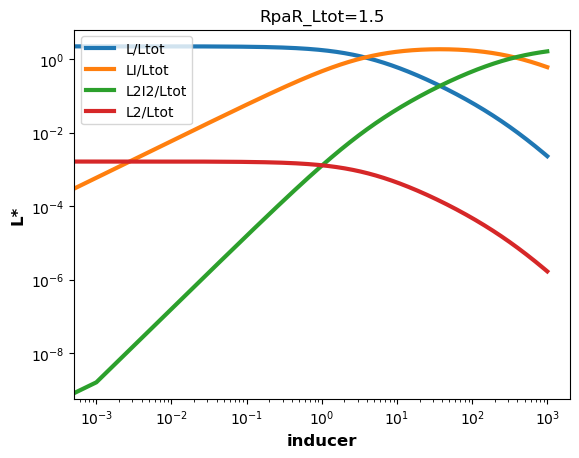

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import palettable
from scipy.stats import linregress

#L = np.arange(0.3, 10, 0.001)
I = np.arange(0, 1000, 0.001)
k1= 0.2649175524711609
k2= 0.026705672964453697
k3= 0.0007314927643164992
kd=0.471939474


L=1.5


A=1
B=I*k1
C=(I*k2)*(I*k2)
D=k3
E=A+B+C+D
fig, ax = plt.subplots()
ax.set_xscale("log")
ax.set_yscale("log")
colors = palettable.cartocolors.diverging.Fall_3.mpl_colors
plt.plot(I, A*L*L/E, linewidth=3.0,label='L/Ltot')
plt.plot(I, B*L*L/E, linewidth=3.0,label='LI/Ltot')
plt.plot(I, C*L*L/E, linewidth=3.0,label='L2I2/Ltot')
plt.plot(I, D*L*L/E, linewidth=3.0,label='L2/Ltot')

#plt.plot(L, A1, linewidth=3.0,label='L')
#plt.plot(L, B1, linewidth=3.0,label='L2')
#plt.plot(L, C1, linewidth=3.0,label='LI')
#plt.plot(L, D1, linewidth=3.0,label='L2I2')

'''
slope, intercept = np.polyfit(L, A, 1)
print(slope)
slope1, intercept1 = np.polyfit(L, B, 1)
print(slope1)
slope2, intercept2 = np.polyfit(L, C, 1)
print(slope2)
slope3, intercept3 = np.polyfit(L, D, 1)
print(slope3)
'''
ax.set_xlabel("inducer",fontsize=12,weight='bold')
ax.set_ylabel("L*",fontsize=12,weight='bold')
plt.legend(loc='upper left')
plt.title('RpaR_Ltot=1.5')
#plt.savefig("E:\Desktop\\CinRori_L_approximation.svg",format="svg")
plt.show()



C:\Users\Chestnut\AppData\Local\Temp\ipykernel_38584\1095713850.py:75: RuntimeWarning: divide by zero encountered in log
  F1=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd1) #CI434
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_38584\1095713850.py:77: RuntimeWarning: divide by zero encountered in log
  F2=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd2) #LexAs5
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_38584\1095713850.py:79: RuntimeWarning: divide by zero encountered in log
  F3=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd3) #LexAs17
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_38584\1095713850.py:81: RuntimeWarning: divide by zero encountered in log
  F4=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd4) #LexA87
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_38584\1095713850.py:83: RuntimeWarning: divide by zero encountered in log
  F5=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2

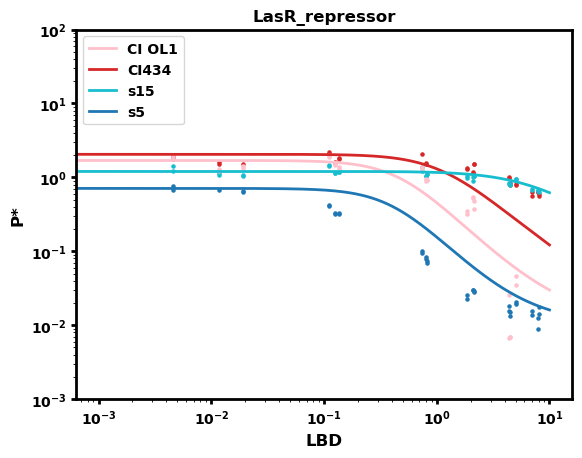

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import optimize
import scipy.constants as c
import pandas as pd
from scipy.interpolate import interp1d

# 设置x和y的坐标范围
#I= np.arange(0,1000,0.01)
#kd= np.arange(10,100000,1)
#I= np.arange(0,10,0.01)
#I1=1000
#I2=100
#I=0.000000001
L= np.arange(0,10,0.001)
I=0.1

kd1=6.216347694

kd2=40.97704697

kd3=5.374494076

kd4=0.745553315

kd5=1.445352554

kd6=5.066512585

kd7=2.956590891

kd8=0.607055765

kd9=1.13083303

kd10=0.343528478

kd11=0.102414004

kd12=30.08697891

kd13=10.36936283

kd14=10.53282547


k1=0.000171923

k2=0.256016091

k3=225.0817618

Imax1 =1.68385346

Imax2 = 2.041632918

Imax3= 1.192854885

Imax4 = 0.699652229

Imax5 = 0.85546578

x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
x2 = np.sqrt(1 + 8 * L * k1)
x3 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I ))

F1=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd1) #CI434

F2=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd2) #LexAs5
 
F3=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd3) #LexAs17

F4=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd4) #LexA87

F5=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd5) #LexAs23

F6=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd6) #HKCI

F7=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd7) #RecApact

F8=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd8) #DeoR

F9=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd9) #PurR

F10=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd10) #LexAs15

F11=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd11) #LexAs14

F12=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd12) #CI OL1

F13=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd13) #CI OR1

F14=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd14) # CI Osym



P1 = (Imax2 / (1 + np.exp(F1))) +0.01
P3 = (Imax5 / (1 + np.exp(F3))) +0.01

P2 = (Imax4 / (1 + np.exp(F2))) +0.01

P10 = (Imax3 / (1 + np.exp(F10)))  +0.01


P12 = (Imax1 / (1 + np.exp(F12)))  +0.01

#y1=np.sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)*(-50*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 10*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)) - (-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))**2/8 + 1 - 1/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))) + (I - 10)*(80*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - (160*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + 2*k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))*(-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))/4)*sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (I - 10)**2*(4*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2**2/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)) - (8*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))*(-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))/4 - (160*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + 2*k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))**2/8)*np.sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)
fig, ax = plt.subplots()
#ax.plot(L, P3,linewidth=1.5,label='master curve',c='black',linestyle='--')
ax.plot(L, P12,linewidth=2,label='CI OL1',c='pink')
ax.plot(L, P1,linewidth=2,label='CI434',c='#d62728')
ax.plot(L, P10,linewidth=2,label='s15',c='#17becf')
ax.plot(L, P2,linewidth=2,label='s5',c='#1f77b4')
#ax.plot(L, P3,linewidth=1.5,label='s17',c='#9467bd')
#ax.plot(L, P4,linewidth=1.5,label='LexA87',c='#8c564b')
#ax.plot(L, P5,linewidth=1.5,label='LexAs23',c='#e377c2')
#ax.plot(L, P6,linewidth=1.5,label='HKCI',c='#7f7f7f')
#ax.plot(L, P7,linewidth=2,label='RecApact')
#ax.plot(L, P8,linewidth=1.5,label='DeoR',c='#bcbd22')
#ax.plot(L, P9,linewidth=1.5,label='PurR',c='#ff7f0e')

#ax.plot(L, P11,linewidth=1.5,label='LexAs14',c='#2ca02c')

#ax.plot(L, P13,linewidth=1.5,label='CI OR1',c='green')
#ax.plot(L, P14,linewidth=1.5,label='CI Osym',c='gold')

#ax.plot(I, np.log10(x3),linewidth=3,label='I2=100')
#ax.plot(I, y2,linewidth=3,label='I0=0')
#ax.plot(I, y1,linewidth=3,label='I0=10')
#ax.plot(L, y1,linewidth=3,label='y4')
#ax.plot(I, P2,label='本底',linewidth=3)
#ax.plot(I, P2,label='kb=inititial*10',linewidth=3)

#ax.plot(I, P3,label='kb=inititial*100',linewidth=3)
plt.legend(loc='upper left')
#plt.annotate('P1= {:.4f}'.format(P1), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')

#plt.annotate('P2= {:.4f}'.format(P2), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')
#ax.plot(L, P2, label="P2")
#ax.scatter(x, y)
def func(I,L, k1, k2, k3):  
            if not 0 < k1 or not 0 < k2 or not 0 < k3:
                return np.ones_like(L) * 1e10  # 返回一个大的值
            x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
            return (Imax * ((L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd / (1 + (L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd)) + I0)
df1 = pd.read_csv("E:\Desktop\\all_data\\repressor\\101.csv")
df2 = pd.read_csv("E:\Desktop\\all_data\\repressor\\102.csv")
df3 = pd.read_csv("E:\Desktop\\all_data\\repressor\\119.csv")
df4 = pd.read_csv("E:\Desktop\\all_data\\repressor\\121.csv")

x1=df1['LBD'].dropna()
y1=df1['0.1'].dropna()-0.2
x2=df2['LBD'].dropna()
y2=df2['0.1'].dropna()-0.2
x3=df3['LBD'].dropna()
y3=df3['0.1'].dropna()
x4=df4['LBD'].dropna()
y4=df4['0.1'].dropna()



'''
P1P1_ddG = P1_ddG(x4)-y2
P1P3_ddG = P1_ddG(x5)-y4
P1P4_ddG = P1_ddG(x6)-y6
P1P5_ddG = P1_ddG(x7)-y2
P1P6_ddG = P1_ddG(x8)-y4
P1P8_ddG = P1_ddG(x9)-y6
P1P10_ddG = P1_ddG(x10)-y2
P1P12_ddG = P1_ddG(x11)-y4
P1P13_ddG = P1_ddG(x12)-y6
P1P14_ddG = P1_ddG(x13)-y2
''' 

# 现在你可以将插值后的 ddg8 加到 y1 上



ax.scatter(x4, y4, label="s5",s=5,c='#1f77b4')
#ax.scatter(x1, y2, label="s5",s=5,c='#1f77b4',marker='v')
#ax.scatter(x2, y3, label="PurR",s=2,c='#1f77b4')
#ax.scatter(x2, y4, label="PurR",s=5,c='#1f77b4',marker='v')
#ax.scatter(x3, y5, label="s14",s=2,c='#2ca02c')
#ax.scatter(x3, y6, label="s14",s=5,c='#2ca02c',marker='v')
#ax.scatter(x1, y1, label="s5",s=5,c='#1f77b4')
#ax.scatter(x2, y3, label="s5",s=5,c='#ff7f0e')
ax.scatter(x2, y2, label="CI434",s=5,c='#d62728')
#ax.scatter(x5, y8, label="s17",s=2,c='#9467bd')
#ax.scatter(x6, y9, label="87",s=2,c='#8c564b')
#ax.scatter(x7, y10, label="s23",s=2,c='#e377c2')
#ax.scatter(x8, y11, label="HKCI",s=2,c='#7f7f7f')
#ax.scatter(x9, y12, label="DeoR",s=2,c='#bcbd22')
ax.scatter(x3, y3, label="s15",s=5,c='#17becf')
ax.scatter(x1, y1, label="CI OL1",s=5,c='pink')
#ax.scatter(x12, y15, label="CI OR1",s=2,c='green')
#ax.scatter(x13, y16, label="CI Osym",s=2,c='gold')


# 为每个数据点添加误差条
'''
for x, y, std in zip(x1, y1, std_P1P2['P1P2_ddG']):
    plt.errorbar(x, y, yerr=std, fmt='v', color='#1f77b4', markersize=5)
for x, y, std in zip(x2, y3, std_P1P9['P1P9_ddG']):
    plt.errorbar(x, y, yerr=std, fmt='v', color='#ff7f0e', markersize=5 )
#for x, y, std in zip(x3, y5, std_P1P11['P1P11_ddG']):
#    plt.errorbar(x, y, yerr=std, fmt='v', color='#2ca02c', markersize=5)
'''
'''
x = df["inducer1"].dropna()
x2=df["inducer2"].dropna()
x3=df["inducer4"].dropna()

y1 = df["RPU4"].dropna()
y2 = df["RPU5"].dropna()
x1 = df["inducer"].dropna()
y3 = df["RPU12"].dropna()
error0=df["error0"].dropna()
error1=df["error1"].dropna()
error2=df["error2"].dropna()
error3=df["error3"].dropna()
error4=df["error4"].dropna()
y4= df["RPU9"].dropna()
y5=df["RPUCI1"].dropna()
y6=df["RPUCI2"].dropna()
y7=df["RPU41"].dropna()
y8=df["RPU42"].dropna()
y9=df["RPU51"].dropna()
y10=df["RPU52"].dropna()

c1=df["c1"].dropna()
c2=df["c2"].dropna()
c3=df["c3"].dropna()
c4=df["c4"].dropna()
#ax.scatter(x, y3, label="DeoR",s=5)
#plt.errorbar(x3, y5, yerr=error0, fmt='.',c='#1f77b4')
#plt.errorbar(x3, y6, yerr=error0, fmt='.',c='#1f77b4')
plt.errorbar(x2, y7, yerr=error2, fmt='.',c='#ff7f0e')
plt.errorbar(x2, y8, yerr=error2, fmt='.',c='#ff7f0e')
plt.errorbar(x2, y9, yerr=error3, fmt='.',c='#2ca02c')
plt.errorbar(x2, y10, yerr=error3, fmt='.',c='#2ca02c')

#plt.errorbar(x2, y5-c1, yerr=error1, fmt='.',c='#1f77b4')
#plt.errorbar(x2, y6-c1, yerr=error1, fmt='.',c='#1f77b4')
'''

#plt.scatter(x2, y6-c4,c='#1f77b4',s=10,marker='x')
#plt.scatter(x2, y7-c2,c='#ff7f0e',s=15,marker='<')
#plt.scatter(x2, y9-c3,c='#2ca02c',s=10,marker='D')
#print(y6-c4)
#plt.errorbar(x,y3, yerr=0.5)
#print(func(df["inducer1"],2.080747981, k1, k2,k3))
#ax.scatter(x, y1, label="DeoR",s=5)
#plt.errorbar(x,y1,yerr=0.5,c='#ff7f0e')
#ax.scatter(x, y4, label="DeoR",s=5)
#ax.scatter(x, y2, label="DeoR",s=5)
#plt.errorbar(x,y2,yerr=0.5,c='#2ca02c')

# 设置横纵坐标轴的取值范围和标签
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_xlim(0, 10)
#ax.set_ylim(0, 100)
ax.set_xlabel("LBD",fontsize=12,weight='bold')
ax.set_ylabel("P*",fontsize=12,weight='bold')
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.tick_params(axis='both', width=2,labelsize=10)
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
ax.set_ylim((10**(-3)),10**2)

# 添加图例并显示图形
plt.title('LasR_repressor',fontsize=12,weight='bold')

#plt.savefig("E:\Desktop\\RpaR_allDBD_inducer100.svg")
plt.show()

C:\Users\Chestnut\AppData\Local\Temp\ipykernel_1424\2045934620.py:68: RuntimeWarning: divide by zero encountered in log
  F3=np.log(L1 / 2) + np.log((x3 - (k2*I+1)) / (x3 + (k2*I+1))) + np.log(kd11) #LexAs17
C:\Users\Chestnut\AppData\Local\Temp\ipykernel_1424\2045934620.py:92: RuntimeWarning: divide by zero encountered in log
  F15=np.log(L1 / 2) + np.log((x3 - (k2*I+1)) / (x3 + (k2*I+1))) + np.log(kd3) # CI Osym


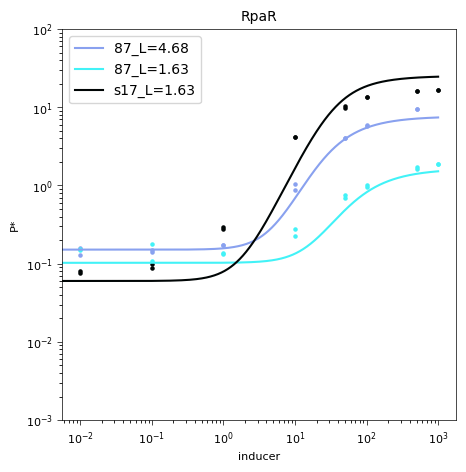

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import optimize
import scipy.constants as c
import pandas as pd
from scipy.interpolate import interp1d

# 设置x和y的坐标范围
I= np.arange(0,1000,0.01)

L=7.05

L1=1.63


kd1=6.216347694

kd2=40.97704697

kd3=5.374494076


kd4=0.745553315

kd5=1.445352554

kd6=5.066512585

kd7=2.956590891

kd8=0.607055765

kd9=1.13083303

kd10=0.343528478

kd11=0.102414004

kd12=30.08697891

kd13=10.36936283

kd14=10.53282547


k1=0.000268715


k2=0.007083518



k3=0.760771692

Imax =35.84931505



x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
x2 = np.sqrt(1 + 8 * L * k1)
x3 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L1 * (k2*k2*k3*I*I ))

F1=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd1) #CI434

F2=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd2) #LexAs5
 
F3=np.log(L1 / 2) + np.log((x3 - (k2*I+1)) / (x3 + (k2*I+1))) + np.log(kd11) #LexAs17

F4=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd4) #LexA87

F5=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd5) #LexAs23

F6=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd6) #HKCI

F7=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd7) #RecApact

F8=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd8) #DeoR

F9=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd9) #PurR

F10=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd10) #LexAs15

F11=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd11) #LexAs14

F12=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd12) #CI OL1

F13=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd13) #CI OR1

F14=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd14) # CI Osym

F15=np.log(L1 / 2) + np.log((x3 - (k2*I+1)) / (x3 + (k2*I+1))) + np.log(kd3) # CI Osym

P4 = (Imax / (1 + np.exp(-F11))) +0.102414004

P3 = (Imax / (1 + np.exp(-F3))) +0.102414004


P2 = (Imax / (1 + np.exp(-F15))) +0.01


#y1=np.sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)*(-50*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 10*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)) - (-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))**2/8 + 1 - 1/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))) + (I - 10)*(80*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - (160*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + 2*k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))*(-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))/4)*sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (I - 10)**2*(4*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2**2/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)) - (8*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))*(-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))/4 - (160*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + 2*k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))**2/8)*np.sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)
fig, ax = plt.subplots(figsize=(5.08,5.08))
#ax.plot(L, P3,linewidth=1.5,label='master curve',c='black',linestyle='--')
ax.plot(I, P4,linewidth=1.5,label='87_L=4.68',color='#89A1EF')
ax.plot(I, P3,linewidth=1.5,label='87_L=1.63',color='#42F2F7')
ax.plot(I, P2+0.05,linewidth=1.5,label='s17_L=1.63',color='#000505')
plt.legend(loc='upper left')

def func(I,L, k1, k2, k3):  
            if not 0 < k1 or not 0 < k2 or not 0 < k3:
                return np.ones_like(L) * 1e10  # 返回一个大的值
            x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
            return (Imax * ((L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd / (1 + (L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd)) + I0)
df1 = pd.read_csv("E:\Desktop\\s14_7.05.csv")
df2 = pd.read_csv("E:\Desktop\\s14_1.78.csv")
df3 = pd.read_csv("E:\Desktop\\s17_1.63.csv")


x1=df1['inducer'].dropna()
y1=df1['RPU'].dropna()
x2=df2['inducer'].dropna()
y2=df2['RPU'].dropna()
x3=df3['inducer'].dropna()
y3=df3['RPU'].dropna()

ax.scatter(x1, y1, label="87_L=4.68",s=5,color='#89A1EF')

ax.scatter(x2, y2, label="87_L=1.63",s=5,color='#42F2F7')

ax.scatter(x3, y3, label="s17_L=1.63",s=5,color='#000505')

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("inducer",fontsize=8)
ax.set_ylabel("P*",fontsize=8)
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
plt.tick_params(axis='both', width=0.5,labelsize=8)
plt.rcParams['font.weight'] = 'light'
plt.rcParams['axes.labelweight'] = 'light'
ax.set_ylim((10**(-3)),10**2)

# 添加图例并显示图形
plt.title('RpaR',fontsize=10)

plt.savefig("E:\Desktop\\BjaR_optimal.svg")
plt.show()

C:\Users\Chestnut\AppData\Local\Temp\ipykernel_1424\3218999832.py:68: RuntimeWarning: divide by zero encountered in log
  F3=np.log(L1 / 2) + np.log((x3 - (k2*I+1)) / (x3 + (k2*I+1))) + np.log(kd3) #LexAs17


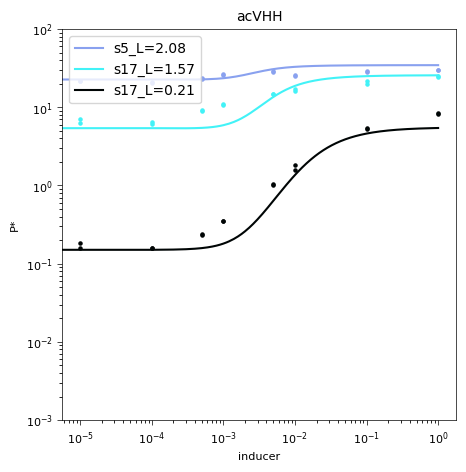

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import optimize
import scipy.constants as c
import pandas as pd
from scipy.interpolate import interp1d

# 设置x和y的坐标范围
I= np.arange(0,1,0.0001)
#kd= np.arange(10,100000,1)
#I= np.arange(0,10,0.01)
#I1=1000
#I2=100
#I=0.000000001
#L= np.arange(0,10,0.001)
L=2.08

L1=0.21


kd1=6.216347694

kd2=40.97704697

kd3=8.374494076

kd4=0.745553315

kd5=1.445352554

kd6=5.066512585

kd7=2.956590891

kd8=0.607055765

kd9=1.13083303

kd10=0.343528478

kd11=0.102414004

kd12=30.08697891

kd13=10.36936283

kd14=10.53282547


k1=0.01047924



k2=58.84004211

k3=0.746886849
Imax =35.84931505

x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
x2 = np.sqrt(1 + 8 * L * k1)
x3 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L1 * (k2*k2*k3*I*I ))

F1=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd1) #CI434

F2=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd2) #LexAs5
 
F3=np.log(L1 / 2) + np.log((x3 - (k2*I+1)) / (x3 + (k2*I+1))) + np.log(kd3) #LexAs17

F4=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd4) #LexA87

F5=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd5) #LexAs23

F6=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd6) #HKCI

F7=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd7) #RecApact

F8=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd8) #DeoR

F9=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd9) #PurR

F10=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd10) #LexAs15

F11=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd11) #LexAs14

F12=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd12) #CI OL1

F13=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd13) #CI OR1

F14=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd14) # CI Osym

F15=np.log(L1 / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd2) # CI Osym

P4 = (Imax / (1 + np.exp(-F2))) +0.035
P3 = (Imax / (1 + np.exp(-F3))) +0.15

P2 = (Imax / (1 + np.exp(-F15))) +0.15

#y1=np.sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)*(-50*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 10*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)) - (-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))**2/8 + 1 - 1/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))) + (I - 10)*(80*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - (160*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + 2*k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))*(-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))/4)*sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (I - 10)**2*(4*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2**2/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)) - (8*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))*(-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))/4 - (160*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + 2*k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))**2/8)*np.sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)
fig, ax = plt.subplots(figsize=(5.08,5.08))
#ax.plot(L, P3,linewidth=1.5,label='master curve',c='black',linestyle='--')
ax.plot(I, P4,linewidth=1.5,label='s5_L=2.08',color='#89A1EF')
ax.plot(I, P2,linewidth=1.5,label='s17_L=1.57',color='#42F2F7')
ax.plot(I, P3,linewidth=1.5,label='s17_L=0.21',color='#000505')
#ax.plot(L, P3,linewidth=1.5,label='s17',c='#9467bd')
#ax.plot(L, P4,linewidth=1.5,label='LexA87',c='#8c564b')
#ax.plot(L, P5,linewidth=1.5,label='LexAs23',c='#e377c2')
#ax.plot(L, P6,linewidth=1.5,label='HKCI',c='#7f7f7f')
#ax.plot(L, P7,linewidth=2,label='RecApact')
#ax.plot(L, P8,linewidth=1.5,label='DeoR',c='#bcbd22')
#ax.plot(L, P9,linewidth=1.5,label='PurR',c='#ff7f0e')

#ax.plot(L, P11,linewidth=1.5,label='LexAs14',c='#2ca02c')

#ax.plot(L, P13,linewidth=1.5,label='CI OR1',c='green')
#ax.plot(L, P14,linewidth=1.5,label='CI Osym',c='gold')

#ax.plot(I, np.log10(x3),linewidth=3,label='I2=100')
#ax.plot(I, y2,linewidth=3,label='I0=0')
#ax.plot(I, y1,linewidth=3,label='I0=10')
#ax.plot(L, y1,linewidth=3,label='y4')
#ax.plot(I, P2,label='本底',linewidth=3)
#ax.plot(I, P2,label='kb=inititial*10',linewidth=3)

#ax.plot(I, P3,label='kb=inititial*100',linewidth=3)
plt.legend(loc='upper left')
#plt.annotate('P1= {:.4f}'.format(P1), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')




#plt.annotate('P2= {:.4f}'.format(P2), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')
#ax.plot(L, P2, label="P2")
#ax.scatter(x, y)
def func(I,L, k1, k2, k3):  
            if not 0 < k1 or not 0 < k2 or not 0 < k3:
                return np.ones_like(L) * 1e10  # 返回一个大的值
            x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
            return (Imax * ((L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd / (1 + (L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd)) + I0)
df1 = pd.read_csv("E:\Desktop\\s5_2.08.csv")
df2 = pd.read_csv("E:\Desktop\\s17_2.08.csv")
df3 = pd.read_csv("E:\Desktop\\s17_0.21.csv")


x1=df1['inducer'].dropna()
y1=df1['RPU'].dropna()-0.2
x2=df2['inducer'].dropna()
y2=df2['RPU'].dropna()
x3=df3['inducer'].dropna()
y3=df3['RPU'].dropna()


'''
P1P1_ddG = P1_ddG(x4)-y2
P1P3_ddG = P1_ddG(x5)-y4
P1P4_ddG = P1_ddG(x6)-y6
P1P5_ddG = P1_ddG(x7)-y2
P1P6_ddG = P1_ddG(x8)-y4
P1P8_ddG = P1_ddG(x9)-y6
P1P10_ddG = P1_ddG(x10)-y2
P1P12_ddG = P1_ddG(x11)-y4
P1P13_ddG = P1_ddG(x12)-y6
P1P14_ddG = P1_ddG(x13)-y2
''' 

# 现在你可以将插值后的 ddg8 加到 y1 上


'''
ax.scatter(x1, y1, label="s5_L=2.08",s=5,color='#89A1EF')
#ax.scatter(x1, y2, label="s5",s=5,c='#1f77b4',marker='v')
#ax.scatter(x2, y3, label="PurR",s=2,c='#1f77b4')
#ax.scatter(x2, y4, label="PurR",s=5,c='#1f77b4',marker='v')
#ax.scatter(x3, y5, label="s14",s=2,c='#2ca02c')
#ax.scatter(x3, y6, label="s14",s=5,c='#2ca02c',marker='v')
#ax.scatter(x1, y1, label="s5",s=5,c='#1f77b4')
#ax.scatter(x2, y3, label="s5",s=5,c='#ff7f0e')
ax.scatter(x2, y2, label="s17_L=1.57",s=5,color='#42F2F7')
#ax.scatter(x5, y8, label="s17",s=2,c='#9467bd')
#ax.scatter(x6, y9, label="87",s=2,c='#8c564b')
#ax.scatter(x7, y10, label="s23",s=2,c='#e377c2')
#ax.scatter(x8, y11, label="HKCI",s=2,c='#7f7f7f')
#ax.scatter(x9, y12, label="DeoR",s=2,c='#bcbd22')
ax.scatter(x3, y3, label="s17_L=0.21",s=5,color='#000505')

#ax.scatter(x12, y15, label="CI OR1",s=2,c='green')
#ax.scatter(x13, y16, label="CI Osym",s=2,c='gold')

'''
# 为每个数据点添加误差条
'''
for x, y, std in zip(x1, y1, std_P1P2['P1P2_ddG']):
    plt.errorbar(x, y, yerr=std, fmt='v', color='#1f77b4', markersize=5)
for x, y, std in zip(x2, y3, std_P1P9['P1P9_ddG']):
    plt.errorbar(x, y, yerr=std, fmt='v', color='#ff7f0e', markersize=5 )
#for x, y, std in zip(x3, y5, std_P1P11['P1P11_ddG']):
#    plt.errorbar(x, y, yerr=std, fmt='v', color='#2ca02c', markersize=5)
'''
'''
x = df["inducer1"].dropna()
x2=df["inducer2"].dropna()
x3=df["inducer4"].dropna()

y1 = df["RPU4"].dropna()
y2 = df["RPU5"].dropna()
x1 = df["inducer"].dropna()
y3 = df["RPU12"].dropna()
error0=df["error0"].dropna()
error1=df["error1"].dropna()
error2=df["error2"].dropna()
error3=df["error3"].dropna()
error4=df["error4"].dropna()
y4= df["RPU9"].dropna()
y5=df["RPUCI1"].dropna()
y6=df["RPUCI2"].dropna()
y7=df["RPU41"].dropna()
y8=df["RPU42"].dropna()
y9=df["RPU51"].dropna()
y10=df["RPU52"].dropna()

c1=df["c1"].dropna()
c2=df["c2"].dropna()
c3=df["c3"].dropna()
c4=df["c4"].dropna()
#ax.scatter(x, y3, label="DeoR",s=5)
#plt.errorbar(x3, y5, yerr=error0, fmt='.',c='#1f77b4')
#plt.errorbar(x3, y6, yerr=error0, fmt='.',c='#1f77b4')
plt.errorbar(x2, y7, yerr=error2, fmt='.',c='#ff7f0e')
plt.errorbar(x2, y8, yerr=error2, fmt='.',c='#ff7f0e')
plt.errorbar(x2, y9, yerr=error3, fmt='.',c='#2ca02c')
plt.errorbar(x2, y10, yerr=error3, fmt='.',c='#2ca02c')
'''
'''
#plt.errorbar(x2, y5-c1, yerr=error1, fmt='.',c='#1f77b4')
#plt.errorbar(x2, y6-c1, yerr=error1, fmt='.',c='#1f77b4')
'''

#plt.scatter(x2, y6-c4,c='#1f77b4',s=10,marker='x')
#plt.scatter(x2, y7-c2,c='#ff7f0e',s=15,marker='<')
#plt.scatter(x2, y9-c3,c='#2ca02c',s=10,marker='D')
#print(y6-c4)
#plt.errorbar(x,y3, yerr=0.5)
#print(func(df["inducer1"],2.080747981, k1, k2,k3))
#ax.scatter(x, y1, label="DeoR",s=5)
#plt.errorbar(x,y1,yerr=0.5,c='#ff7f0e')
#ax.scatter(x, y4, label="DeoR",s=5)
#ax.scatter(x, y2, label="DeoR",s=5)
#plt.errorbar(x,y2,yerr=0.5,c='#2ca02c')

# 设置横纵坐标轴的取值范围和标签
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_xlim(0, 10)
#ax.set_ylim(0, 100)
ax.set_xlabel("inducer",fontsize=8)
ax.set_ylabel("P*",fontsize=8)
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
plt.tick_params(axis='both', width=0.5,labelsize=8)
plt.rcParams['font.weight'] = 'light'
plt.rcParams['axes.labelweight'] = 'light'
ax.set_ylim((10**(-3)),10**2)

# 添加图例并显示图形
plt.title('acVHH',fontsize=10)

plt.savefig("E:\Desktop\\acVHH_optimal.svg")
plt.show()

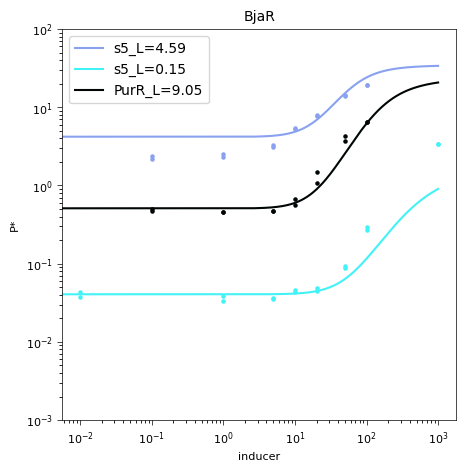

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import optimize
import scipy.constants as c
import pandas as pd
from scipy.interpolate import interp1d

# 设置x和y的坐标范围
I= np.arange(0,1000,0.01)
#kd= np.arange(10,100000,1)
#I= np.arange(0,10,0.01)
#I1=1000
#I2=100
#I=0.000000001
#L= np.arange(0,10,0.001)
L=4.59
L1=0.15
L2=9.05

kd1=6.216347694

kd2=40.97704697

kd3=8.374494076

kd4=0.745553315

kd5=1.577

kd6=5.066512585

kd7=2.956590891

kd8=0.607055765

kd9=1.13083303

kd10=0.343528478

kd11=0.102414004

kd12=30.08697891

kd13=10.36936283

kd14=10.53282547


k1=0.000153468



k2=0.002735345




k3=0.050865889
Imax =35.84931505

x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
x2 = np.sqrt(1 + 8 * L * k1)
x3 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L1 * (k2*k2*k3*I*I + k1))
x4 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L2 * (k2*k2*k3*I*I + k1))
F1=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd1) #CI434

F2=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd2) #LexAs5
 
F3=np.log(L1 / 2) + np.log((x3 - (k2*I+1)) / (x3 + (k2*I+1))) + np.log(kd3) #LexAs17

F4=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd4) #LexA87

F5=np.log(L1 / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd5) #LexAs23

F6=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd6) #HKCI

F7=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd7) #RecApact

F8=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd8) #DeoR

F9=np.log(L2 / 2) + np.log((x4 - (k2*I+1)) / (x4 + (k2*I+1))) + np.log(kd9) #PurR

F10=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd10) #LexAs15

F11=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd11) #LexAs14

F12=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd12) #CI OL1

F13=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd13) #CI OR1

F14=np.log(L / 2) + np.log((x1 - (k2*I+1)) / (x1 + (k2*I+1))) + np.log(kd14) # CI Osym

F15=np.log(L1 / 2) + np.log((x3 - (k2*I+1)) / (x3 + (k2*I+1))) + np.log(kd2)

P4 = (Imax / (1 + np.exp(-F2))) +0.01
P3 = (Imax / (1 + np.exp(-F9))) +0.01

P2 = (Imax / (1 + np.exp(-F15))) +0.035485714

#y1=np.sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)*(-50*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 10*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)) - (-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))**2/8 + 1 - 1/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))) + (I - 10)*(80*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - (160*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + 2*k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))*(-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))/4)*sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (I - 10)**2*(4*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2**2/(2*(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)) - (8*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))*(-100*k2**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 20*k2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + (10*k2 + 1)**2/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) - 1/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))/4 - (160*L*k2**2*k3/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1) + 2*k2*(10*k2 + 1)/(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1))**2/8)*np.sqrt(8*L*k1 + 800*L*k2**2*k3 + 100*k2**2 + 20*k2 + 1)
fig, ax = plt.subplots(figsize=(5.08,5.08))
#ax.plot(L, P3,linewidth=1.5,label='master curve',c='black',linestyle='--')
ax.plot(I, P4,linewidth=1.5,label='s5_L=4.59',color='#89A1EF')
ax.plot(I, P2,linewidth=1.5,label='s5_L=0.15',color='#42F2F7')
ax.plot(I, P3,linewidth=1.5,label='PurR_L=9.05',color='#000505')
#ax.plot(L, P3,linewidth=1.5,label='s17',c='#9467bd')
#ax.plot(L, P4,linewidth=1.5,label='LexA87',c='#8c564b')
#ax.plot(L, P5,linewidth=1.5,label='LexAs23',c='#e377c2')
#ax.plot(L, P6,linewidth=1.5,label='HKCI',c='#7f7f7f')
#ax.plot(L, P7,linewidth=2,label='RecApact')
#ax.plot(L, P8,linewidth=1.5,label='DeoR',c='#bcbd22')
#ax.plot(L, P9,linewidth=1.5,label='PurR',c='#ff7f0e')

#ax.plot(L, P11,linewidth=1.5,label='LexAs14',c='#2ca02c')

#ax.plot(L, P13,linewidth=1.5,label='CI OR1',c='green')
#ax.plot(L, P14,linewidth=1.5,label='CI Osym',c='gold')

#ax.plot(I, np.log10(x3),linewidth=3,label='I2=100')
#ax.plot(I, y2,linewidth=3,label='I0=0')
#ax.plot(I, y1,linewidth=3,label='I0=10')
#ax.plot(L, y1,linewidth=3,label='y4')
#ax.plot(I, P2,label='本底',linewidth=3)
#ax.plot(I, P2,label='kb=inititial*10',linewidth=3)

#ax.plot(I, P3,label='kb=inititial*100',linewidth=3)
plt.legend(loc='upper left')
#plt.annotate('P1= {:.4f}'.format(P1), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')




#plt.annotate('P2= {:.4f}'.format(P2), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=10,weight='bold')
#ax.plot(L, P2, label="P2")
#ax.scatter(x, y)
def func(I,L, k1, k2, k3):  
            if not 0 < k1 or not 0 < k2 or not 0 < k3:
                return np.ones_like(L) * 1e10  # 返回一个大的值
            x1 = np.sqrt((k2*I+1)*(k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1))
            return (Imax * ((L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd / (1 + (L / 2) * ((x1 - (k2*I+1)) / (x1 + (k2*I+1))) * kd)) + I0)
df1 = pd.read_csv("E:\Desktop\\s5_4.59.csv")
df2 = pd.read_csv("E:\Desktop\\s5_0.15.csv")
df3 = pd.read_csv("E:\Desktop\\PurR_9.05.csv")


x1=df1['inducer'].dropna()
y1=df1['RPU'].dropna()-0.2
x2=df2['inducer'].dropna()
y2=df2['RPU'].dropna()
x3=df3['inducer'].dropna()
y3=df3['RPU'].dropna()


'''
P1P1_ddG = P1_ddG(x4)-y2
P1P3_ddG = P1_ddG(x5)-y4
P1P4_ddG = P1_ddG(x6)-y6
P1P5_ddG = P1_ddG(x7)-y2
P1P6_ddG = P1_ddG(x8)-y4
P1P8_ddG = P1_ddG(x9)-y6
P1P10_ddG = P1_ddG(x10)-y2
P1P12_ddG = P1_ddG(x11)-y4
P1P13_ddG = P1_ddG(x12)-y6
P1P14_ddG = P1_ddG(x13)-y2
''' 

# 现在你可以将插值后的 ddg8 加到 y1 上



ax.scatter(x1, y1, label="s5_4.59",s=5,color='#89A1EF')
#ax.scatter(x1, y2, label="s5",s=5,c='#1f77b4',marker='v')
#ax.scatter(x2, y3, label="PurR",s=2,c='#1f77b4')
#ax.scatter(x2, y4, label="PurR",s=5,c='#1f77b4',marker='v')
#ax.scatter(x3, y5, label="s14",s=2,c='#2ca02c')
#ax.scatter(x3, y6, label="s14",s=5,c='#2ca02c',marker='v')
#ax.scatter(x1, y1, label="s5",s=5,c='#1f77b4')
#ax.scatter(x2, y3, label="s5",s=5,c='#ff7f0e')
ax.scatter(x2, y2, label="s5_0.15",s=5,color='#42F2F7')
#ax.scatter(x5, y8, label="s17",s=2,c='#9467bd')
#ax.scatter(x6, y9, label="87",s=2,c='#8c564b')
#ax.scatter(x7, y10, label="s23",s=2,c='#e377c2')
#ax.scatter(x8, y11, label="HKCI",s=2,c='#7f7f7f')
#ax.scatter(x9, y12, label="DeoR",s=2,c='#bcbd22')
ax.scatter(x3, y3, label="PurR_9.05",s=5,color='#000505')

#ax.scatter(x12, y15, label="CI OR1",s=2,c='green')
#ax.scatter(x13, y16, label="CI Osym",s=2,c='gold')

# 为每个数据点添加误差条
'''
for x, y, std in zip(x1, y1, std_P1P2['P1P2_ddG']):
    plt.errorbar(x, y, yerr=std, fmt='v', color='#1f77b4', markersize=5)
for x, y, std in zip(x2, y3, std_P1P9['P1P9_ddG']):
    plt.errorbar(x, y, yerr=std, fmt='v', color='#ff7f0e', markersize=5 )
#for x, y, std in zip(x3, y5, std_P1P11['P1P11_ddG']):
#    plt.errorbar(x, y, yerr=std, fmt='v', color='#2ca02c', markersize=5)
'''
'''
x = df["inducer1"].dropna()
x2=df["inducer2"].dropna()
x3=df["inducer4"].dropna()

y1 = df["RPU4"].dropna()
y2 = df["RPU5"].dropna()
x1 = df["inducer"].dropna()
y3 = df["RPU12"].dropna()
error0=df["error0"].dropna()
error1=df["error1"].dropna()
error2=df["error2"].dropna()
error3=df["error3"].dropna()
error4=df["error4"].dropna()
y4= df["RPU9"].dropna()
y5=df["RPUCI1"].dropna()
y6=df["RPUCI2"].dropna()
y7=df["RPU41"].dropna()
y8=df["RPU42"].dropna()
y9=df["RPU51"].dropna()
y10=df["RPU52"].dropna()

c1=df["c1"].dropna()
c2=df["c2"].dropna()
c3=df["c3"].dropna()
c4=df["c4"].dropna()
#ax.scatter(x, y3, label="DeoR",s=5)
#plt.errorbar(x3, y5, yerr=error0, fmt='.',c='#1f77b4')
#plt.errorbar(x3, y6, yerr=error0, fmt='.',c='#1f77b4')
plt.errorbar(x2, y7, yerr=error2, fmt='.',c='#ff7f0e')
plt.errorbar(x2, y8, yerr=error2, fmt='.',c='#ff7f0e')
plt.errorbar(x2, y9, yerr=error3, fmt='.',c='#2ca02c')
plt.errorbar(x2, y10, yerr=error3, fmt='.',c='#2ca02c')
'''
'''
#plt.errorbar(x2, y5-c1, yerr=error1, fmt='.',c='#1f77b4')
#plt.errorbar(x2, y6-c1, yerr=error1, fmt='.',c='#1f77b4')
'''

#plt.scatter(x2, y6-c4,c='#1f77b4',s=10,marker='x')
#plt.scatter(x2, y7-c2,c='#ff7f0e',s=15,marker='<')
#plt.scatter(x2, y9-c3,c='#2ca02c',s=10,marker='D')
#print(y6-c4)
#plt.errorbar(x,y3, yerr=0.5)
#print(func(df["inducer1"],2.080747981, k1, k2,k3))
#ax.scatter(x, y1, label="DeoR",s=5)
#plt.errorbar(x,y1,yerr=0.5,c='#ff7f0e')
#ax.scatter(x, y4, label="DeoR",s=5)
#ax.scatter(x, y2, label="DeoR",s=5)
#plt.errorbar(x,y2,yerr=0.5,c='#2ca02c')

# 设置横纵坐标轴的取值范围和标签
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_xlim(0, 10)
#ax.set_ylim(0, 100)
ax.set_xlabel("inducer",fontsize=8)
ax.set_ylabel("P*",fontsize=8)
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
plt.tick_params(axis='both', width=0.5,labelsize=8)
plt.rcParams['font.weight'] = 'light'
plt.rcParams['axes.labelweight'] = 'light'
ax.set_ylim((10**(-3)),10**2)

# 添加图例并显示图形
plt.title('BjaR',fontsize=10)

plt.savefig("E:\Desktop\\BjaR_optimal.svg")
plt.show()

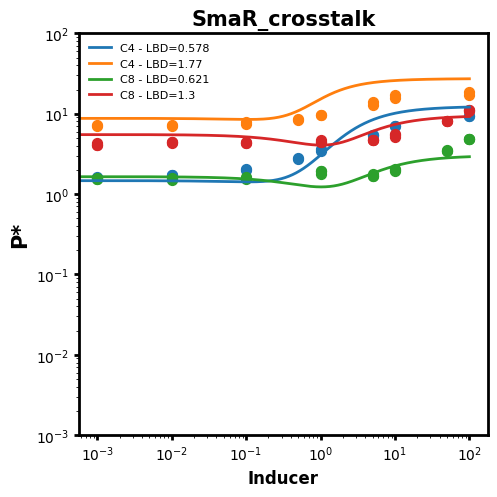

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 读取 CSV 文件
df1 = pd.read_csv(r"E:\Desktop\model\crosstalk4\368_C8.csv")
df = pd.read_csv(r"E:\Desktop\model\crosstalk4\368.csv")

# 参数初始化
I = np.arange(0, 100, 0.001)
k1 = 0.010042600398181
k2 = 0.459416965988916
k3 = 0.207534893094038
k32 = 0.021451125
Imax = 35.84931505
I0 = 0.272291827

# 创建绘图窗口
fig, ax = plt.subplots(figsize=(5.08, 5.08))

# ---------------- C4 数据 ----------------
for L in df["LBD"].unique():
    subset = df[df["LBD"] == L]
    x_subset = subset["inducer"]
    y_subset = subset["RPU"]
    kd_val = subset["kd"].iloc[0]

    x1 = np.sqrt((k2 * I + 1) ** 2 + 8 * L * (k2 * k2 * k3 * I * I + k1))
    P1 = (
        Imax
        * ((L / 2) * ((x1 - (k2 * I + 1)) / (x1 + (k2 * I + 1))) * kd_val
           / (1 + (L / 2) * ((x1 - (k2 * I + 1)) / (x1 + (k2 * I + 1))) * kd_val))
        + I0
    )

    # 动态标签：显示 LBD 值
    ax.plot(I, P1, linewidth=2, label=f"C4 - LBD={L:.3g}")
    ax.scatter(x_subset, y_subset, s=50)

# ---------------- C12 数据 ----------------
for L in df1["LBD"].unique():
    subset = df1[df1["LBD"] == L]
    x_subset = subset["inducer"]
    y_subset = subset["RPU"]
    kd_val = subset["kd"].iloc[0]

    x1 = np.sqrt((k2 * I + 1) ** 2 + 8 * L * (k2 * k2 * k32 * I * I + k1))
    P1 = (
        Imax
        * ((L / 2) * ((x1 - (k2 * I + 1)) / (x1 + (k2 * I + 1))) * kd_val
           / (1 + (L / 2) * ((x1 - (k2 * I + 1)) / (x1 + (k2 * I + 1))) * kd_val))
        + I0
    )

    # 动态标签：显示 LBD 值
    ax.plot(I, P1, linewidth=2, label=f"C8 - LBD={L:.3g}")
    ax.scatter(x_subset, y_subset, s=50)

# ---------------- 坐标设置 ----------------
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Inducer", fontsize=12, weight='bold')
ax.set_ylabel("P*", fontsize=15, weight='bold')
ax.set_ylim(10**(-3), 10**2)

# ---------------- 美化外观 ----------------
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.tick_params(axis='both', width=2, labelsize=10)
plt.title("SmaR_crosstalk", fontsize=15, weight='bold')

# 图例
plt.legend(fontsize=8, loc='best', frameon=False)
plt.tight_layout()

plt.savefig(r'E:\Desktop\curve\SmaR_crosstalk.svg')
plt.show()


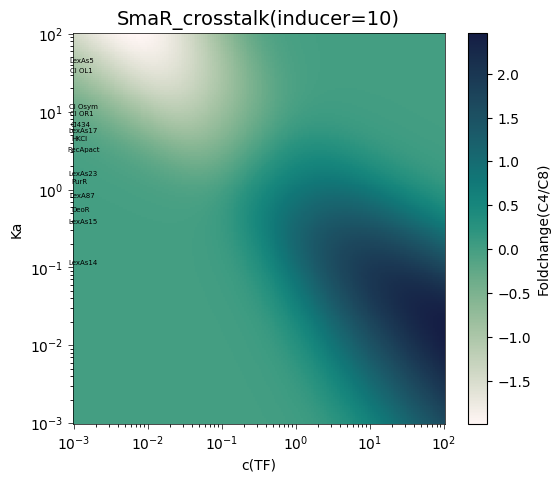

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text
import palettable

def foldchange1(m1, m2):
    k1=0.010042600398181
    k21=0.459416965988916
    k22=0.459416965988916
    k31=0.207534893094038
    k32=0.021451124920468

    I=10

    x1 = np.sqrt((k21*I+1)*(k21*I+1)+ 8 * m1 * (k21*k21*k31*I*I + k1))
    x2 = np.sqrt((k22*I+1)*(k22*I+1)+ 8 * m2 * (k22*k22*k32*I*I + k1))
    x3 = np.sqrt(1 + 8 * m1 * k1)
    Imax = 35.84931505
    I0 = 0.035485714

    F1 = np.log(m1 / 2) + np.log((x1 - (k21*I+1)) / (x1 + (k21*I+1))) + np.log(m2)
    F2 = np.log(m1 / 2) + np.log((x2 - (k22*I+1)) / (x2 + (k22*I+1))) + np.log(m2)
    F3 = np.log(m1 / 2) + np.log((x3 - 1) / (x3 + 1)) + np.log(m2)
    n = (Imax + I0) / (Imax - I0)

    P1 = (Imax / (1 + np.exp(-F1))) + I0
    P2 = (Imax / (1 + np.exp(-F2))) + I0
    P3 = (Imax / (1 + np.exp(-F3))) + I0
    f1 = P1 / P2
    f2 = P1-P2
    n = (Imax + I0) / (Imax - I0)
    

    return f1

def EC501(m1,m2):
    kb = 0.0003
    kc = 0.0016

    Imax = 35.84931505

    I0 = 0.035485714
    n=(Imax+I0)/(Imax-I0)

    EC501= (1 / (m2 * m1 - 2 * n)) * np.sqrt((2 * n * m2 - kb * ((m2 * m1 - 2 * n) * (m1* m1 - 2 * n))) / kc)
    return EC501

def EC502(m1,m2):
    kb = 0.0003
    kc = 0.000016

    Imax = 35.84931505

    I0 = 0.035485714
    n=(Imax+I0)/(Imax-I0)

    EC502 = (1 / (m2 * m1 - 2 * n)) * np.sqrt((2 * n * m2 - kb * ((m2 * m1 - 2 * n) * (m1* m1 - 2 * n))) / kc)
    return EC502
m1 = np.logspace(-3, 2, 200)
m2 = np.logspace(-3, 2, 200)
M1, M2 = np.meshgrid(m1, m2)

fig, ax = plt.subplots(figsize=(6,5.08))
cmap = palettable.cmocean.sequential.Tempo_17.mpl_colormap

# 绘制热力图
cp = ax.pcolormesh(M1, M2, np.log10(foldchange1(M1, M2)), cmap=cmap)

# 添加颜色条
cbar = fig.colorbar(cp)
cbar.ax.set_ylabel('Foldchange(C4/C8)',fontsize=10)

# 设置横纵坐标轴标签及其缩放
ax.set_xlabel('c(TF)',fontsize=10)
ax.set_ylabel('Ka',fontsize=10)
ax.set_xscale('log')
ax.set_yscale('log')

kd_values = [6.216347694,	40.97704697,	5.374494076,	0.745553315,	1.445352554,	5.066512585	,2.956590891,	0.607055765,	1.13083303,30.08697891,	10.36936283,	10.53282547,0.343528478,	0.102414004]
kd_labels = ['CI434', 'LexAs5', 'LexAs17', 'LexA87', 'LexAs23', 'HKCI', 'RecApact', 'DeoR', 'PurR', 'CI OL1',	'CI OR1',	 'CI Osym', 'LexAs15', 'LexAs14']


# 绘制散点图并调整标签位置
texts = []
for i, (x, y) in enumerate(zip(kd_values, kd_labels)):
    text = ax.text(0.001, x, y, fontsize=5)  # 调整0.001的位置可以让标签靠左对齐
    texts.append(text)

# 调整标签位置避免重叠
adjust_text(texts, autoalign='y', only_move={'points':'y', 'text':'y'})

'''
levels = np.arange(-1.0, 1.0, 0.2)
cs=ax.contour(M1, M2, np.log10(EC501(M1,M2)))
plt.clabel(cs, inline=True, fontsize=10)
cs=ax.contour(M1, M2, np.log10(EC502(M1,M2)))
plt.clabel(cs, inline=True, fontsize=10)
'''
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
plt.tick_params(axis='both', width=0.5,labelsize=10)

plt.title("SmaR_crosstalk(inducer=10)",fontsize=14)
plt.savefig('E:\Desktop\curve\SmaR_crosstalk_2D.svg')
plt.show()


C4 点数： 12
C8 点数： 12
C12 点数： 12


C:\Users\Chestnut\AppData\Local\Temp\ipykernel_43188\4254998138.py:74: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(r'E:\Desktop\curve\SmaR_crosstalk_2D_points.svg')
d:\Users\Chestnut\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


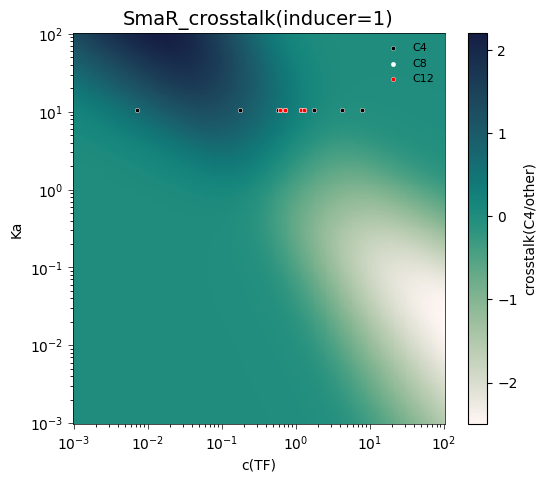

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import palettable
import pandas as pd

# ----------------- 定义 foldchange 函数 -----------------
def foldchange1(m1, m2):
    k1=0.010042600398181
    k21=0.459416965988916
    k22=0.459416965988916
    k31=0.207534893094038
    k32=0.021451124920468
    I=1

    x1 = np.sqrt((k21*I+1)*(k21*I+1)+ 8 * m1 * (k21*k21*k31*I*I + k1))
    x2 = np.sqrt((k22*I+1)*(k22*I+1)+ 8 * m2 * (k22*k22*k32*I*I + k1))
    Imax = 35.84931505
    I0 = 0.035485714

    F1 = np.log(m1 / 2) + np.log((x1 - (k21*I+1)) / (x1 + (k21*I+1))) + np.log(m2)
    F2 = np.log(m1 / 2) + np.log((x2 - (k22*I+1)) / (x2 + (k22*I+1))) + np.log(m2)

    P1 = (Imax / (1 + np.exp(-F1))) + I0
    P2 = (Imax / (1 + np.exp(-F2))) + I0

    f1 = P1 / P2
    return 1/f1

# ----------------- 生成网格 -----------------
m1 = np.logspace(-3, 2, 200)
m2 = np.logspace(-3, 2, 200)
M1, M2 = np.meshgrid(m1, m2)

# ----------------- 绘制热力图 -----------------
fig, ax = plt.subplots(figsize=(6,5.08))
cmap = palettable.cmocean.sequential.Tempo_17.mpl_colormap
cp = ax.pcolormesh(M1, M2, np.log10(foldchange1(M1, M2)), cmap=cmap)
cbar = fig.colorbar(cp)
cbar.ax.set_ylabel('crosstalk(C4/other)', fontsize=10)

ax.set_xlabel('c(TF)', fontsize=10)
ax.set_ylabel('Ka', fontsize=10)
ax.set_xscale('log')
ax.set_yscale('log')

# ----------------- 绘制三个文件的点（仅颜色区分） -----------------
file_list = [
    (r"E:\Desktop\model\crosstalk4\368.csv", "C4", "black"),
    (r"E:\Desktop\model\crosstalk4\368_C8.csv", "C8", "white"),
    (r"E:\Desktop\model\crosstalk4\368_C12.csv", "C12", "red"),
]
cp = ax.pcolormesh(M1, M2, np.log10(foldchange1(M1, M2)), cmap=cmap, zorder=0)

for file_path, label, color in file_list:
    df = pd.read_csv(file_path)
    df_filtered = df[np.isclose(df['inducer'], 1, atol=1e-6)]
    df_filtered = df_filtered[(df_filtered['LBD'] > 0) & (df_filtered['kd'] > 0)]
    print(label, "点数：", len(df_filtered))

    x_values = df_filtered['LBD'].values
    y_values = df_filtered['kd'].values
    ax.scatter(x_values, y_values, s=10, color=color, label=label,
               edgecolor='white', linewidths=0.3, zorder=10)


ax.legend(fontsize=8, frameon=False)
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
plt.tick_params(axis='both', width=0.5, labelsize=10)

plt.title("SmaR_crosstalk(inducer=1)", fontsize=14)
plt.savefig(r'E:\Desktop\curve\SmaR_crosstalk_2D_points.svg')
plt.show()


C4 点数： 32
C8 点数： 48


C:\Users\Chestnut\AppData\Local\Temp\ipykernel_43188\787140712.py:79: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(r'E:\Desktop\curve\SmaR_crosstalk_2D_selected_points.svg')
d:\Users\Chestnut\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


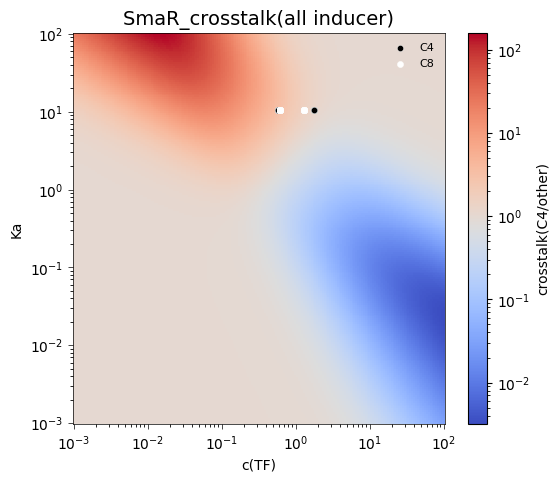

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import palettable
import pandas as pd
from matplotlib.ticker import LogLocator
import matplotlib.colors as colors

# ----------------- 定义 foldchange 函数 -----------------
def foldchange1(m1, m2):
    k1 = 0.010042600398181
    k21 = 0.459416965988916
    k22 = 0.459416965988916
    k31 = 0.207534893094038
    k32 = 0.021451124920468
    I = 1

    x1 = np.sqrt((k21*I+1)**2 + 8 * m1 * (k21**2*k31*I**2 + k1))
    x2 = np.sqrt((k22*I+1)**2 + 8 * m2 * (k22**2*k32*I**2 + k1))

    F1 = np.log(m1 / 2) + np.log((x1 - (k21*I+1)) / (x1 + (k21*I+1))) + np.log(m2)
    F2 = np.log(m1 / 2) + np.log((x2 - (k22*I+1)) / (x2 + (k22*I+1))) + np.log(m2)

    P1 = (35.84931505 / (1 + np.exp(-F1))) + 0.035485714
    P2 = (35.84931505 / (1 + np.exp(-F2))) + 0.035485714

    f1 = P1 / P2
    return 1/f1

# ----------------- 生成网格 -----------------
m1 = np.logspace(-3, 2, 200)
m2 = np.logspace(-3, 2, 200)
M1, M2 = np.meshgrid(m1, m2)
foldchange = foldchange1(M1, M2)

# ----------------- 绘制热力图 -----------------
fig, ax = plt.subplots(figsize=(6,5.08))
norm = colors.LogNorm(vmin=foldchange.min(), vmax=foldchange.max())
cp = ax.pcolormesh(M1, M2, foldchange, cmap='coolwarm', shading='auto', norm=norm)

# ----------------- colorbar -----------------
cbar = fig.colorbar(cp)
cbar.ax.set_ylabel('crosstalk(C4/other)', fontsize=10)

# ----------------- 坐标轴设置 -----------------
ax.set_xlabel('c(TF)', fontsize=10)
ax.set_ylabel('Ka', fontsize=10)
ax.set_xscale('log')
ax.set_yscale('log')

# ----------------- 绘制指定 LBD 的散点 -----------------
file_list = [
    (r"E:\Desktop\model\crosstalk4\368.csv", "C4", "black", [0.578183468, 1.772196394]),
    (r"E:\Desktop\model\crosstalk4\368_C8.csv", "C8", "white", [0.621451104, 1.303057432]),
]

for file_path, label, color, LBD_targets in file_list:
    df = pd.read_csv(file_path)
    df_filtered = df[(df['LBD'] > 0) & (df['kd'] > 0) & (df['LBD'].isin(LBD_targets))]
    print(label, "点数：", len(df_filtered))

    x_values = df_filtered['LBD'].values
    y_values = df_filtered['kd'].values
    ax.scatter(x_values, y_values, s=20, color=color, label=label,
               edgecolor='white', linewidths=0.3, zorder=10)

# ----------------- 美化坐标轴 -----------------
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
plt.tick_params(axis='both', width=0.5, labelsize=10)
plt.rcParams['font.weight'] = 'light'
plt.rcParams['axes.labelweight'] = 'light'

plt.title("SmaR_crosstalk(all inducer)", fontsize=14)
ax.legend(fontsize=8, frameon=False)

# ----------------- 保存 SVG -----------------
plt.savefig(r'E:\Desktop\curve\SmaR_crosstalk_2D_selected_points.svg')
plt.show()


β 点数： 8
DHB 点数： 8


C:\Users\Chestnut\AppData\Local\Temp\ipykernel_21332\1649788088.py:87: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(r'E:\Desktop\\all_data\crosstalk_new\ER_crosstalk_2D_selected_points.svg')
d:\Users\Chestnut\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


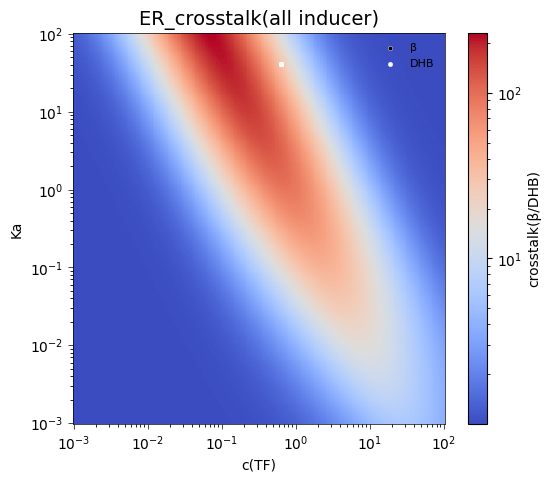

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import palettable
import pandas as pd
from matplotlib.ticker import LogLocator
import matplotlib.colors as colors

# ----------------- 定义 foldchange 函数 -----------------
def foldchange1(m1, m2):
    k1 = 6.353E-12
    k2 = 3.583382137
    k31 = 4.130148252
    k32 = 0.002820379874017

    kx11=1.112792988
    kx12= 90.438632354216338

    kx21=4.960066803
    kx22=0.000010055243956

    I1 = 1
    I2 = 100
    Imax=35.84931505
    I0=0.035485714

    x1 = np.sqrt((k2 * I1 + kx11 + kx21 * k2 * I1 + 1)**2 + 8 * m1 * (k2**2 * k31 * I1**2 + k1 + k1 * kx11**2 + k31 * k2**2 * kx21**2 * I1**2))
    x2 = np.sqrt((k2 * I2 + kx12 + kx22 * k2 * I2 + 1)**2 + 8 * m1 * (k2**2 * k32 * I2**2 + k1 + k1 * kx12**2 + k32 * k2**2 * kx22**2 * I2**2))
    F1 = np.log(m1 / 2) + np.log((x1 - (k2 * I1 + kx11 + kx21 * k2 * I1 + 1)) / (x1 + (k2 * I1 + kx11 + kx21 * k2 * I1 + 1))) + np.log(m2)
    F2 = np.log(m1 / 2) + np.log((x2 - (k2 * I2 + kx12 + kx22 * k2 * I2 + 1)) / (x2 + (k2 * I2 + kx12 + kx22 * k2 * I2 + 1))) + np.log(m2)
    P1 = (Imax / (1 + np.exp(-F1))) + I0
    P2 = (Imax / (1 + np.exp(-F2))) + I0
    f1 = P1 / P2

    return f1

# ----------------- 生成网格 -----------------
m1 = np.logspace(-3, 2, 200)
m2 = np.logspace(-3, 2, 200)
M1, M2 = np.meshgrid(m1, m2)
foldchange = foldchange1(M1, M2)

# ----------------- 绘制热力图 -----------------
fig, ax = plt.subplots(figsize=(6,5.08))
norm = colors.LogNorm(vmin=foldchange.min(), vmax=foldchange.max())
cp = ax.pcolormesh(M1, M2, foldchange, cmap='coolwarm', shading='auto', norm=norm)

# ----------------- colorbar -----------------
cbar = fig.colorbar(cp)
cbar.ax.set_ylabel('crosstalk(β/DHB)', fontsize=10)

# ----------------- 坐标轴设置 -----------------
ax.set_xlabel('c(TF)', fontsize=10)
ax.set_ylabel('Ka', fontsize=10)
ax.set_xscale('log')
ax.set_yscale('log')

# ----------------- 绘制所有散点 -----------------
file_list = [
    (r"E:\Desktop\all_data\crosstalk_new\s5_ER_2nd.csv", "β", "black"),
    (r"E:\Desktop\all_data\crosstalk_new\s5_ER_DHB_2nd.csv", "DHB", "white"),
]

for file_path, label, color in file_list:
    df = pd.read_csv(file_path)
    # 只过滤掉无效数据，保留所有有效点
    df_filtered = df[(df['LBD'] > 0) & (df['kd'] > 0)]
    print(label, "点数：", len(df_filtered))

    x_values = df_filtered['LBD'].values
    y_values = df_filtered['kd'].values
    ax.scatter(x_values, y_values, s=10, color=color, label=label,
               edgecolor='white', linewidths=0.3, zorder=10)

# ----------------- 美化坐标轴 -----------------
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
plt.tick_params(axis='both', width=0.5, labelsize=10)
plt.rcParams['font.weight'] = 'light'
plt.rcParams['axes.labelweight'] = 'light'

plt.title("ER_crosstalk(all inducer)", fontsize=14)
ax.legend(fontsize=8, frameon=False)

# ----------------- 保存 SVG -----------------
plt.savefig(r'E:\Desktop\\all_data\crosstalk_new\ER_crosstalk_2D_selected_points.svg')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import palettable
import pandas as pd
from matplotlib.ticker import LogLocator
import matplotlib.colors as colors

# ----------------- 定义 foldchange 函数 -----------------
def foldchange1(m1, m2):
    k1 = 0.010042600398181
    k21 = 0.459416965988916
    k22 = 0.459416965988916
    k31 = 0.207534893094038
    k32 = 0.021451124920468
    I = 1

    x1 = np.sqrt((k21*I+1)**2 + 8 * m1 * (k21**2*k31*I**2 + k1))
    x2 = np.sqrt((k22*I+1)**2 + 8 * m2 * (k22**2*k32*I**2 + k1))

    F1 = np.log(m1 / 2) + np.log((x1 - (k21*I+1)) / (x1 + (k21*I+1))) + np.log(m2)
    F2 = np.log(m1 / 2) + np.log((x2 - (k22*I+1)) / (x2 + (k22*I+1))) + np.log(m2)

    P1 = (35.84931505 / (1 + np.exp(-F1))) + 0.035485714
    P2 = (35.84931505 / (1 + np.exp(-F2))) + 0.035485714

    f1 = P1 / P2
    return 1/f1

# ----------------- 生成网格 -----------------
m1 = np.logspace(-3, 2, 200)
m2 = np.logspace(-3, 2, 200)
M1, M2 = np.meshgrid(m1, m2)
foldchange = foldchange1(M1, M2)

# ----------------- 绘制热力图 -----------------
fig, ax = plt.subplots(figsize=(6,5.08))
norm = colors.LogNorm(vmin=foldchange.min(), vmax=foldchange.max())
cp = ax.pcolormesh(M1, M2, foldchange, cmap='coolwarm', shading='auto', norm=norm)

# ----------------- colorbar -----------------
cbar = fig.colorbar(cp)
cbar.ax.set_ylabel('fold', fontsize=10)

# ----------------- 坐标轴设置 -----------------
ax.set_xlabel('c(TF)', fontsize=10)
ax.set_ylabel('Ka', fontsize=10)
ax.set_xscale('log')
ax.set_yscale('log')

ax.scatter(x_subset, y_subset, s=50)

# ----------------- 美化坐标轴 -----------------
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
plt.tick_params(axis='both', width=0.5, labelsize=10)
plt.rcParams['font.weight'] = 'light'
plt.rcParams['axes.labelweight'] = 'light'

plt.title("1sensor", fontsize=14)
ax.legend(fontsize=8, frameon=False)

# ----------------- 保存 SVG -----------------
plt.savefig(r'E:\Desktop\12s\1sensor_hotmap.svg')
plt.show()


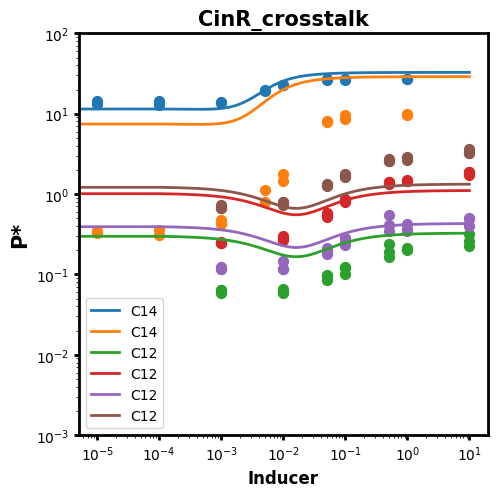

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 读取 CSV 文件
df1 = pd.read_csv("E:\Desktop\\all_data\crosstalk4\\330.csv")
df = pd.read_csv("E:\Desktop\model\crosstalk\\328.csv")
# 提取数据
x1 = df["inducer"]
y1 = df["RPU"]
LBD_values1 = df["LBD"].unique()  # 获取 LBD 列的唯一值
x2 = df1["inducer"]
y2 = df1["RPU"]
LBD_values2 = df1["LBD"].unique()  
# 参数初始化
I = np.arange(0, 10, 0.0001)
'''
k1= 0.000000024465372
k2= 11.007266886882983
k3= 25.868286102327847
kx1= 41.271599110563116
kx2= 12.813951781577774
'''
k1= 4.67083E-05



k2= 5.31018734


k3= 0.650004327
kx1=1.086833596

kx2=4.230793476

k32=0.001472162910024



Imax = 35.84931505
I0 = 0.015485714

#kd_val=40.97704697


# 创建绘图窗口
fig, ax = plt.subplots(figsize=(5.08, 5.08))

# 为每个 LBD 分类绘制曲线和点
for L in LBD_values1:
    # 筛选属于当前 LBD 分类的点
    subset = df[df["LBD"] == L]
    x_subset = subset["inducer"]
    y_subset = subset["RPU"]
    kd_val = subset["kd"].iloc[0]   
    
    # 计算 P1 曲线
    x1 = np.sqrt((k2*I+kx1+kx2*k2*I+1)*(k2*I+kx1+kx2*k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1+k1*kx1*kx1+k3*k2*k2*kx2*kx2*I*I))
    P1 = (
        (Imax * ((L / 2) * ((x1 -  (k2*I+kx1+kx2*k2*I+1)) / (x1 +  (k2*I+kx1+kx2*k2*I+1))) *  kd_val / (1 + (L / 2) * ((x1 -  (k2*I+kx1+kx2*k2*I+1)) / (x1 +  (k2*I+kx1+kx2*k2*I+1))) * kd_val)) + I0)
    )
    
    # 绘制曲线
    ax.plot(I, P1, linewidth=2,label='C14')
    
    
    # 绘制点
    ax.scatter(x_subset, y_subset, s=50)



for L in LBD_values2:
    # 筛选属于当前 LBD 分类的点
    subset = df1[df1["LBD"] == L]
    x_subset = subset["inducer"]
    y_subset = subset["RPU"]
    kd_val = subset["kd"].iloc[0]   
    
    # 计算 P1 曲线
    x1 = np.sqrt((k2 * I + 1) ** 2 + 8 * L * (k2 * k2 * k32 * I * I + k1))
    P1 = (
        Imax
        * ((L / 2) * ((x1 - (k2 * I + 1)) / (x1 + (k2 * I + 1))) * kd_val
           / (1 + (L / 2) * ((x1 - (k2 * I + 1)) / (x1 + (k2 * I + 1))) * kd_val))
        + I0
    )
    
    # 绘制曲线
    ax.plot(I, P1, linewidth=2,label='C12')
    
    
    # 绘制点
    ax.scatter(x_subset, y_subset, s=50)

# 添加两条水平线
#ax.axhline(y=0.380931459, color='black', linestyle='--', linewidth=1)
#ax.axhline(y=2.368348307, color='black', linestyle='--', linewidth=1)

# 设置横纵坐标轴的取值范围和标签
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Inducer", fontsize=12, weight='bold')
ax.set_ylabel("P*", fontsize=15, weight='bold')
ax.set_ylim(10**(-3), 10**2)

# 美化图形
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.tick_params(axis='both', width=2, labelsize=10)
plt.title("CinR_crosstalk", fontsize=15, weight='bold')


plt.legend(fontsize=10)
plt.tight_layout()

#plt.savefig('E:\Desktop\curve\CinR_crosstalk.svg')
# 显示图形
plt.show()



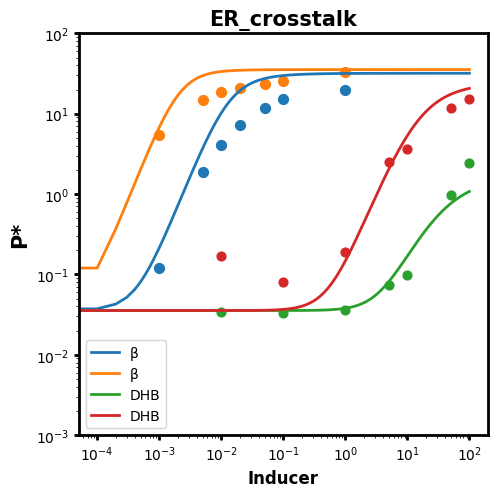

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 读取 CSV 文件
df = pd.read_csv("E:\Desktop\\all_data\crosstalk_new\s5_ER_2nd.csv")
df1 = pd.read_csv("E:\Desktop\\all_data\crosstalk_new\s5_ER_DHB_2nd.csv")
# 提取数据
x1 = df["inducer"]
y1 = df["RPU"]
LBD_values1 = df["LBD"].unique()  # 获取 LBD 列的唯一值
x2 = df1["inducer"]
y2 = df1["RPU"]
LBD_values2 = df1["LBD"].unique()  
# 参数初始化
I = np.arange(0, 100, 0.0001)
'''
k1= 0.000000024465372
k2= 11.007266886882983
k3= 25.868286102327847
kx1= 41.271599110563116
kx2= 12.813951781577774
'''
k1 = 6.353E-12
k2 = 3.583382137
k31 = 4.130148252
k32 = 0.002820379874017

kx11=1.112792988
kx12= 90.438632354216338

kx21=4.960066803
kx22=0.000010055243956


Imax=35.84931505
I0=0.035485714

kd=40.97704697


# 创建绘图窗口
fig, ax = plt.subplots(figsize=(5.08, 5.08))

# 为每个 LBD 分类绘制曲线和点
for L in LBD_values1:
    # 筛选属于当前 LBD 分类的点
    subset = df[df["LBD"] == L]
    x_subset = subset["inducer"]
    y_subset = subset["RPU"]
    kd_val = subset["kd"].iloc[0]   
    
    # 计算 P1 曲线
    x1 = np.sqrt((k2 * I + kx11 + kx21 * k2 * I + 1)**2 + 8 * L * (k2**2 * k31 * I**2 + k1 + k1 * kx11**2 + k31 * k2**2 * kx21**2 * I**2))
    F1 = np.log(L / 2) + np.log((x1 - (k2 * I + kx11 + kx21 * k2 * I + 1)) / (x1 + (k2 * I + kx11 + kx21 * k2 * I + 1))) + np.log(kd)
    P1 = (Imax / (1 + np.exp(-F1))) + I0
    # 绘制曲线
    ax.plot(I, P1, linewidth=2,label='β')
    
    
    # 绘制点
    ax.scatter(x_subset, y_subset, s=50)


for L in LBD_values2:
    # 筛选属于当前 LBD 分类的点
    subset = df1[df1["LBD"] == L]
    x_subset = subset["inducer"]
    y_subset = subset["RPU"]
    kd_val = subset["kd"].iloc[0]   
    
    # 计算 P1 曲线
    x2 = np.sqrt((k2 * I + kx12 + kx22 * k2 * I + 1)**2 + 8 * L * (k2**2 * k32 * I**2 + k1 + k1 * kx12**2 + k32 * k2**2 * kx22**2 * I**2))

    F2 = np.log(L / 2) + np.log((x2 - (k2 * I + kx12 + kx22 * k2 * I + 1)) / (x2 + (k2 * I + kx12 + kx22 * k2 * I+ 1))) + np.log(kd)

    P2 = (Imax / (1 + np.exp(-F2))) + I0
    
    # 绘制曲线
    ax.plot(I, P2, linewidth=2,label='DHB')
    
    
    # 绘制点
    ax.scatter(x_subset, y_subset, s=40)

# 添加两条水平线
#ax.axhline(y=0.380931459, color='black', linestyle='--', linewidth=1)
#ax.axhline(y=2.368348307, color='black', linestyle='--', linewidth=1)

# 设置横纵坐标轴的取值范围和标签
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Inducer", fontsize=12, weight='bold')
ax.set_ylabel("P*", fontsize=15, weight='bold')
ax.set_ylim(10**(-3), 10**2)

# 美化图形
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.tick_params(axis='both', width=2, labelsize=10)
plt.title("ER_crosstalk", fontsize=15, weight='bold')


plt.legend(fontsize=10)
plt.tight_layout()

plt.savefig('E:\Desktop\\all_data\crosstalk_new\ER_crosstalk.svg')
# 显示图形
plt.show()



β 点数： 8
DHB 点数： 0


d:\Users\Chestnut\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


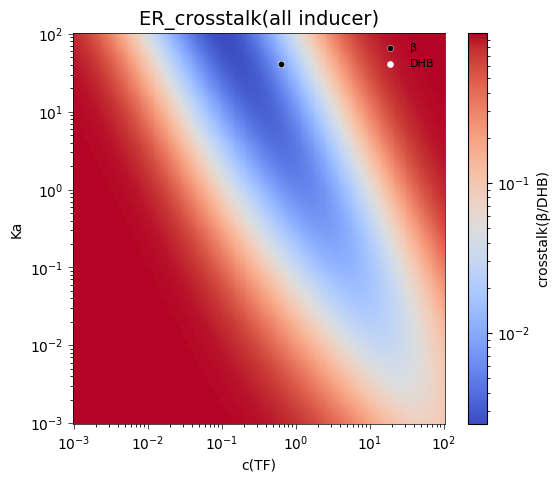

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import palettable
import pandas as pd
from matplotlib.ticker import LogLocator
import matplotlib.colors as colors

# ----------------- 定义 foldchange 函数 -----------------
def foldchange1(m1, m2):
    k1 = 6.353E-12

    k2 = 3.583382137

    k31 = 4.130148252

    k32 = 0.000427255

    kx1=1.112792988

    kx21=4.960066803
    
    kx22=7.53597E-06

    I1 = 1
    I2 = 100
    Imax=35.84931505
    I0=0.035485714


   
    x1 = np.sqrt((k2 * I1 + kx1 + kx21 * k2 * I1 + 1)**2 + 8 * m1 * (k2**2 * k31 * I1**2 + k1 + k1 * kx1**2 + k31 * k2**2 * kx21**2 * I1**2))
    x2 = np.sqrt((k2 * I2 + kx1 + kx22 * k2 * I2 + 1)**2 + 8 * m1 * (k2**2 * k32 * I2**2 + k1 + k1 * kx1**2 + k32 * k2**2 * kx22**2 * I2**2))
    F1 = np.log(m1 / 2) + np.log((x1 - (k2 * I1 + kx1 + kx21 * k2 * I1 + 1)) / (x1 + (k2 * I1 + kx1 + kx21 * k2 * I1 + 1))) + np.log(m2)
    F2 = np.log(m1 / 2) + np.log((x2 - (k2 * I2 + kx1 + kx22 * k2 * I2 + 1)) / (x2 + (k2 * I2 + kx1 + kx22 * k2 * I2 + 1))) + np.log(m2)
    P1 = (Imax / (1 + np.exp(-F1))) + I0
    P2 = (Imax / (1 + np.exp(-F2))) + I0
    f1 = P1 / P2

    return 1/f1


# ----------------- 生成网格 -----------------
m1 = np.logspace(-3, 2, 200)
m2 = np.logspace(-3, 2, 200)
M1, M2 = np.meshgrid(m1, m2)
foldchange = foldchange1(M1, M2)

# ----------------- 绘制热力图 -----------------
fig, ax = plt.subplots(figsize=(6,5.08))
norm = colors.LogNorm(vmin=foldchange.min(), vmax=foldchange.max())
cp = ax.pcolormesh(M1, M2, foldchange, cmap='coolwarm', shading='auto', norm=norm)

# ----------------- colorbar -----------------
cbar = fig.colorbar(cp)
cbar.ax.set_ylabel('crosstalk(β/DHB)', fontsize=10)

# ----------------- 坐标轴设置 -----------------
ax.set_xlabel('c(TF)', fontsize=10)
ax.set_ylabel('Ka', fontsize=10)
ax.set_xscale('log')
ax.set_yscale('log')

# ----------------- 绘制指定 LBD 的散点 -----------------
file_list = [
    (r"E:\Desktop\all_data\crosstalk_new\s5_ER_2nd.csv", "β", "black",[0.64]),
    (r"E:\Desktop\all_data\crosstalk_new\s5_ER_DHB_2nd.csv", "DHB", "white",[0.67]),
]

for file_path, label, color, LBD_targets in file_list:
    df = pd.read_csv(file_path)
    df_filtered = df[(df['LBD'] > 0) & (df['kd'] > 0) & (df['LBD'].isin(LBD_targets))]
    print(label, "点数：", len(df_filtered))

    x_values = df_filtered['LBD'].values
    y_values = df_filtered['kd'].values
    ax.scatter(x_values, y_values, s=20, color=color, label=label,
               edgecolor='white', linewidths=0.3, zorder=10)

# ----------------- 美化坐标轴 -----------------
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
plt.tick_params(axis='both', width=0.5, labelsize=10)
plt.rcParams['font.weight'] = 'light'
plt.rcParams['axes.labelweight'] = 'light'

plt.title("ER_crosstalk(all inducer)", fontsize=14)
ax.legend(fontsize=8, frameon=False)

# ----------------- 保存 SVG -----------------
#plt.savefig(r'E:\Desktop\curve\SmaR_crosstalk_2D_selected_points.svg')
plt.show()